In [1]:
"""
==========================================================================
BLOCK 1: CORE INFRASTRUCTURE AND SYSTEM GLOBALS
==========================================================================
Imports libraries, defines global constants, discovers input files.
==========================================================================
"""

# import system modules
#
import os
import glob
import warnings

# import numerical and dataframe modules
#
import numpy as np
import pandas as pd

# import machine learning modules
#
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression, RFE
import lightgbm as lgb
from lightgbm import LGBMRegressor

# import plotting and clustering diagnostics modules
#
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# suppress pandas downcasting warnings
#
pd.set_option('future.no_silent_downcasting', True)

# suppress lightgbm and sklearn warnings
#
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")

# ---------------------------------------------------------------------------
#
# user-configurable paths: set these to match your local directory layout
#
# ---------------------------------------------------------------------------

# define the directory containing the raw indoor and outdoor csv files
#
BASE_PATH = "/home/irish/capstone/raw"

# define the output directory for processed daily files
#
OUT_DAILY = os.path.join(BASE_PATH, "processed_daily")

# ---------------------------------------------------------------------------
#
# pipeline constants
#
# ---------------------------------------------------------------------------

# define the time threshold in minutes for gap detection and interpolation
#
TIME_THRESHOLD_MINUTES = 30

# define the numeric token used to terminate setpoint forward-fill
#
NUMERIC_RESET_TOKEN = -9999.9

# define step-like columns that get forward-filled between virtual rows
#
STEP_LIKE_COLS = [
    "Setpoint", "FanState"
]

# define columns excluded from feature selection entirely.
# daily_fan_on_hours and fan_runtime_ratio are perfect proxies for the
# target (fan=on agrees with running_mode=heat/cool 100% of the time).
# total_included_known_mode_hours and total_unknown_hours are data
# quality metrics that encode reporting gaps, not thermal behavior.
#
LEAKAGE_COLS = [
    "daily_runtime_hours",
    "daily_fan_on_hours",
    "fan_runtime_ratio"
]

# define the number of lag days for historical memory features
#
LAG_DAYS = 7

# define the window size for outdoor temperature trend gradient
#
OUTDOOR_TREND_WINDOW = 7

# create the output directory if it does not exist
#
os.makedirs(OUT_DAILY, exist_ok=True)

# discover all csv files in the base directory
#
all_raw = sorted(glob.glob(os.path.join(BASE_PATH, "*.csv")))
print(BASE_PATH)
print(all_raw)
# identify the outdoor weather file by name
#
outdoor_file = [f for f in all_raw if "outdoor" in os.path.basename(f).lower()]

# verify exactly one outdoor file was found
#
if len(outdoor_file) != 1:
    raise FileNotFoundError(
        f"expected 1 outdoor file, found {len(outdoor_file)}: {outdoor_file}"
    )

# extract the outdoor file path
#
outdoor_file = outdoor_file[0]

# collect all remaining csv files as indoor thermostat sources,
# excluding any previously processed daily output files
#
indoor_files = [
    f for f in all_raw
    if f != outdoor_file and not os.path.basename(f).endswith("_daily.csv")
]

# print file discovery results
#
print(f"outdoor file: {os.path.basename(outdoor_file)}")
print(f"indoor files: {len(indoor_files)}")


/home/irish/capstone/raw
['/home/irish/capstone/raw/outdoorweather.csv', '/home/irish/capstone/raw/timeseries_table_timeseries_table (1).csv', '/home/irish/capstone/raw/timeseries_table_timeseries_table (10).csv', '/home/irish/capstone/raw/timeseries_table_timeseries_table (100).csv', '/home/irish/capstone/raw/timeseries_table_timeseries_table (11).csv', '/home/irish/capstone/raw/timeseries_table_timeseries_table (12).csv', '/home/irish/capstone/raw/timeseries_table_timeseries_table (13).csv', '/home/irish/capstone/raw/timeseries_table_timeseries_table (14).csv', '/home/irish/capstone/raw/timeseries_table_timeseries_table (15).csv', '/home/irish/capstone/raw/timeseries_table_timeseries_table (16).csv', '/home/irish/capstone/raw/timeseries_table_timeseries_table (17).csv', '/home/irish/capstone/raw/timeseries_table_timeseries_table (18).csv', '/home/irish/capstone/raw/timeseries_table_timeseries_table (19).csv', '/home/irish/capstone/raw/timeseries_table_timeseries_table (2).csv', '/hom

/tmp/ipykernel_96324/1834906098.py:36: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [2]:
"""
==========================================================================
BLOCK 2: OUTDOOR WEATHER PREPARATION
==========================================================================
Ingests and standardizes the outdoor weather file. Ensures temperature
and humidity columns are numeric and chronologically sorted.
==========================================================================
"""

def process_outdoor_weather(path):
    """
    function: process_outdoor_weather

    arguments:
      path: file path to the outdoor weather csv

    return:
      dataframe with Timestamp and four outdoor variables

    description:
      reads, cleans, and standardizes the outdoor weather file.
    """

    # read the outdoor file with semicolon delimiter
    #
    dfw = pd.read_csv(path, sep=";", low_memory=False)

    # parse the timestamp column
    #
    dfw["Timestamp"] = pd.to_datetime(dfw["Timestamp"], errors="coerce")

    # drop rows with invalid timestamps and sort chronologically
    #
    dfw = dfw.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

    # rename Temperature to Outdoor_Temperature to avoid indoor collision
    #
    dfw = dfw.rename(columns={"Temperature": "Outdoor_Temperature"})

    # define the required outdoor columns
    #
    target_cols = [
        "Outdoor_Temperature", "outsideMinTemp",
        "outsideMaxTemp", "outsideHumidity"
    ]

    # coerce each target column to numeric
    #
    for c in target_cols:
        dfw[c] = pd.to_numeric(dfw[c], errors="coerce")

    # return only the timestamp and target columns
    #
    return dfw[["Timestamp"] + target_cols]

# process the outdoor weather file
#
w_df = process_outdoor_weather(outdoor_file)

# confirm outdoor weather processing
#
print("\noutdoor weather processed:")
print(w_df.head())



outdoor weather processed:
            Timestamp  Outdoor_Temperature  outsideMinTemp  outsideMaxTemp  \
0 2025-01-27 20:52:46                 2.94             NaN            3.10   
1 2025-01-27 21:07:47                 0.39             NaN            1.92   
2 2025-01-27 21:22:46                 0.39             NaN            1.92   
3 2025-01-27 21:37:48                 0.39             NaN            1.92   
4 2025-01-27 21:52:46                 0.29             NaN            1.88   

   outsideHumidity  
0               41  
1               52  
2               52  
3               52  
4               52  


In [3]:
"""
==========================================================================
BLOCK 3: INDOOR FILE INGESTION AND COLUMN STANDARDIZATION
==========================================================================
Maps raw manufacturer column names to canonical names. Parses timestamps,
adds Equipment_ID, and creates a raw row counter.
==========================================================================
"""

def standardize_indoor_columns(df):
    """
    function: standardize_indoor_columns

    arguments:
      df: raw indoor dataframe

    return:
      dataframe with canonical column names

    description:
      renames known raw column names to standard pipeline names.
    """

    # define the column rename mapping
    #
    rename_map = {
        "output_state": "OutputState",
        "fan_state": "FanState",
        "running_mode": "RunningMode",
        "hvac_state": "RunningMode",
        "temp": "Temperature",
        "set_point": "Setpoint"
    }

    # apply the rename map
    #
    df = df.rename(columns=rename_map)

    # return the renamed dataframe
    #
    return df

# process the first indoor file as a sample walkthrough
#
sample_path = indoor_files[0]

# read the raw sample file
#
sample_df = pd.read_csv(sample_path, sep=";", low_memory=False)

# standardize column names
#
sample_df = standardize_indoor_columns(sample_df)

# parse the timestamp column
#
sample_df["Timestamp"] = pd.to_datetime(sample_df["Timestamp"], errors="coerce")

# drop invalid timestamps and sort
#
sample_df = sample_df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

# extract the equipment id from the filename
#
sample_df["Equipment_ID"] = os.path.splitext(os.path.basename(sample_path))[0]

# add a row counter to preserve ordering on timestamp ties
#
sample_df["raw_row_id"] = np.arange(len(sample_df))

# confirm ingestion
#
print(f"\nraw ingestion for {sample_df['Equipment_ID'].iloc[0]}:")
print(sample_df[["Timestamp", "Equipment_ID", "RunningMode", "Temperature", "Setpoint"]].head())



raw ingestion for timeseries_table_timeseries_table (1):
            Timestamp                           Equipment_ID RunningMode  \
0 2025-02-05 15:53:08  timeseries_table_timeseries_table (1)         NaN   
1 2025-02-05 15:53:10  timeseries_table_timeseries_table (1)         off   
2 2025-02-05 16:05:10  timeseries_table_timeseries_table (1)         NaN   
3 2025-02-05 16:39:33  timeseries_table_timeseries_table (1)         NaN   
4 2025-02-05 16:39:34  timeseries_table_timeseries_table (1)         off   

   Temperature  Setpoint  
0          NaN       NaN  
1          NaN       NaN  
2          NaN      23.0  
3          NaN      23.0  
4          NaN       NaN  


In [4]:
"""
==========================================================================
BLOCK 4: BURST RESOLUTION (SAME-TIMESTAMP SNAPSHOTS)
==========================================================================
Resolves cases where the device sent multiple rows at the exact same
timestamp. Forward-fills within each burst and keeps the last row.
==========================================================================
"""

def resolve_same_timestamp_bursts(df):
    """
    function: resolve_same_timestamp_bursts

    arguments:
      df: indoor event dataframe

    return:
      dataframe with one row per unique timestamp

    description:
      forward-fills within each timestamp group, keeps the last row.
    """

    # isolate all non-timestamp columns
    #
    data_cols = [c for c in df.columns if c != "Timestamp"]

    # forward-fill within each timestamp group
    #
    df[data_cols] = df.groupby("Timestamp", sort=False)[data_cols].ffill()

    # keep only the last row of each timestamp group
    #
    last_rows = df.groupby("Timestamp", sort=False, as_index=False).tail(1)

    # reset the index
    #
    return last_rows.reset_index(drop=True)

# resolve bursts in the sample
#
sample_df = resolve_same_timestamp_bursts(sample_df)

# confirm burst resolution
#
print("\nburst resolution complete:")
print(sample_df[["Timestamp", "raw_row_id", "RunningMode", "Temperature"]].head())



burst resolution complete:
            Timestamp  raw_row_id RunningMode  Temperature
0 2025-02-05 15:53:08           0         NaN          NaN
1 2025-02-05 15:53:10           1         off          NaN
2 2025-02-05 16:05:10           2         NaN          NaN
3 2025-02-05 16:39:33           3         NaN          NaN
4 2025-02-05 16:39:34           4         off          NaN


In [5]:
"""
==========================================================================
BLOCK 5: STATE NORMALIZATION AND VIRTUAL EXPIRATION ROW INJECTION
==========================================================================
Normalizes running mode text to canonical states (heat/cool/off/unknown).
Detects gaps exceeding 30 minutes and injects synthetic expiration rows
to terminate forward-fill persistence.
==========================================================================
"""

def normalize_running_mode(x):
    """
    function: normalize_running_mode

    arguments:
      x: raw running mode value

    return:
      canonical mode string or np.nan

    description:
      maps raw mode text to heat, cool, off, or unknown.
    """

    # preserve nulls
    #
    if pd.isna(x):
        return np.nan

    # lowercase and strip whitespace
    #
    s = str(x).strip().lower()

    # map to heating
    #
    if s in {"heat", "heating"}:
        return "heat"

    # map to cooling
    #
    if s in {"cool", "cooling"}:
        return "cool"

    # map to off/idle
    #
    if s in {"off", "idle", "none", "false", "0"}:
        return "off"

    # default to unknown
    #
    return "unknown"


def inject_virtual_expiration_rows(df):
    """
    function: inject_virtual_expiration_rows

    arguments:
      df: indoor event dataframe

    return:
      dataframe with synthetic expiration rows inserted

    description:
      for each gap > 30 min, inserts a synthetic row at gap_start + 30 min
      to reset step-like states.
    """

    # compute the time gap in seconds between every consecutive pair of
    # rows. a large gap indicates the thermostat stopped sending all
    # pings (a true data blackout, not just a missing column).
    #
    gap_sec = df["Timestamp"].diff().dt.total_seconds()

    # identify rows where the preceding gap exceeds the 30-minute
    # threshold. these are the points where we need to inject a
    # synthetic expiration row to terminate forward-fill persistence.
    #
    blackout_mask = gap_sec > (TIME_THRESHOLD_MINUTES * 60)

    # if no blackouts were found, return the dataframe unchanged
    #
    if not blackout_mask.any():
        return df

    # compute the timestamp where each blackout began by subtracting
    # the gap duration from the row that follows the gap. the virtual
    # row is placed 30 minutes after that gap-start timestamp.
    #
    bl_ts = df.loc[blackout_mask, "Timestamp"]
    bl_gap = gap_sec[blackout_mask]
    gap_starts = bl_ts - pd.to_timedelta(bl_gap, unit="s")
    virtual_timestamps = gap_starts.values + pd.Timedelta(minutes=TIME_THRESHOLD_MINUTES)

    # build all virtual rows at once as a single dataframe instead of
    # appending one dict at a time. each virtual row resets the
    # step-like columns (running mode, setpoint, fan state) to
    # terminate persistence so forward-fill does not bleed state
    # across the data blackout.
    #
    v_rows = pd.DataFrame({
        "Timestamp": virtual_timestamps,
        "Equipment_ID": df.loc[blackout_mask, "Equipment_ID"].values,
        "RunningMode_clean": "unknown",
        "Setpoint": NUMERIC_RESET_TOKEN,
        "FanState": "unknown",
        "is_virtual_expiration": True,
    })

    # concatenate the virtual rows with the original dataframe and
    # re-sort so the synthetic rows sit in their correct temporal
    # positions within the timeline
    #
    df = pd.concat([df, v_rows], ignore_index=True)
    df = df.sort_values("Timestamp").reset_index(drop=True)

    # return the augmented dataframe
    #
    return df

# copy the raw running mode for auditing
#
sample_df["RunningMode_raw"] = sample_df.get("RunningMode", np.nan)

# normalize running modes
#
sample_df["RunningMode_clean"] = sample_df["RunningMode_raw"].map(normalize_running_mode)

# inject virtual expiration rows
#
sample_df = inject_virtual_expiration_rows(sample_df)

# confirm virtual row injection
#
virt = sample_df[sample_df.get('is_virtual_expiration') == True]
print(f"\nvirtual expiration rows injected: {len(virt)}")
print(virt[["Timestamp", "RunningMode_clean", "Setpoint", "FanState"]].head())



virtual expiration rows injected: 3190
             Timestamp RunningMode_clean  Setpoint FanState
3  2025-02-05 16:35:10           unknown   -9999.9  unknown
6  2025-02-05 17:09:34           unknown   -9999.9  unknown
8  2025-02-05 18:09:25           unknown   -9999.9  unknown
10 2025-02-05 19:09:17           unknown   -9999.9  unknown
12 2025-02-05 20:09:09           unknown   -9999.9  unknown


In [6]:
"""
==========================================================================
BLOCK 6: UNBOUNDED STATE PERSISTENCE AND BOUNDED INTERPOLATION
==========================================================================
Forward-fills step-like columns (fill stops at virtual rows). Applies
bounded time interpolation to indoor temperature: only keeps interpolated
values where the total gap between valid readings is <= 30 minutes.
==========================================================================
"""

def bounded_time_interpolate(series, times):
    """
    function: bounded_time_interpolate

    arguments:
      series: pandas Series of values to interpolate
      times: pandas Series of corresponding timestamps

    return:
      pandas Series with bounded interpolated values

    description:
      interpolates using time index, but nullifies any interpolated
      value where the surrounding valid-to-valid gap exceeds 30 min.
    """

    # coerce to numeric
    #
    s = pd.to_numeric(series, errors="coerce")

    # find timestamps of previous and next valid values
    #
    prev_valid_ts = times.where(s.notna()).ffill()
    next_valid_ts = times.where(s.notna()).bfill()

    # compute total gap width in minutes
    #
    total_gap_min = (next_valid_ts - prev_valid_ts).dt.total_seconds() / 60.0

    # perform time-based interpolation
    #
    temp = pd.DataFrame({"t": times, "v": s}).set_index("t")
    interp_vals = temp["v"].interpolate(method="time").values

    # keep values only where original was valid or gap <= threshold
    #
    ok_mask = s.notna() | (total_gap_min <= TIME_THRESHOLD_MINUTES)

    # return interpolated values with invalid regions nullified
    #
    return pd.Series(np.where(ok_mask, interp_vals, np.nan), index=series.index)

# forward-fill the normalized running mode
#
sample_df["RunningMode"] = sample_df["RunningMode_clean"].ffill()

# apply bounded interpolation to indoor temperature
#
sample_df["Temperature"] = bounded_time_interpolate(
    sample_df["Temperature"], sample_df["Timestamp"]
)

# forward-fill and back-fill static metadata if present
#
if "RentalStatus" in sample_df.columns:
    sample_df["RentalStatus"] = sample_df["RentalStatus"].ffill().bfill()

# forward-fill each step-like column
#
for c in STEP_LIKE_COLS:
    if c in sample_df.columns:

        # coerce setpoint to numeric before filling
        #
        if c == "Setpoint":
            sample_df[c] = pd.to_numeric(sample_df[c], errors="coerce")

        # forward-fill the column
        #
        sample_df[c] = sample_df[c].ffill()

        # replace the reset token with NaN for setpoint
        #
        if c == "Setpoint":
            sample_df[c] = sample_df[c].replace(NUMERIC_RESET_TOKEN, np.nan)

# re-sort by timestamp and raw row id
#
sample_df = sample_df.sort_values(
    ["Timestamp", "raw_row_id"], kind="mergesort"
).reset_index(drop=True)

# confirm fill and interpolation
#
print("\nstate persistence and interpolation complete:")
print(sample_df[["Timestamp", "RunningMode", "Temperature", "Setpoint"]].head(10))



state persistence and interpolation complete:
            Timestamp RunningMode  Temperature  Setpoint
0 2025-02-05 15:53:08         NaN          NaN       NaN
1 2025-02-05 15:53:10         off          NaN       NaN
2 2025-02-05 16:05:10         off          NaN      23.0
3 2025-02-05 16:35:10     unknown          NaN       NaN
4 2025-02-05 16:39:33     unknown          NaN      23.0
5 2025-02-05 16:39:34         off          NaN      23.0
6 2025-02-05 17:09:34     unknown          NaN       NaN
7 2025-02-05 17:39:25         off          NaN      23.0
8 2025-02-05 18:09:25     unknown          NaN       NaN
9 2025-02-05 18:39:17         off          NaN      23.0


In [7]:
"""
==========================================================================
BLOCK 7: INTERVAL RUNTIME ACCOUNTING
==========================================================================
Computes the duration in seconds between consecutive events and assigns
each interval to the prior operating mode.
==========================================================================
"""

# compute the previous row timestamp
#
sample_df["prev_timestamp"] = sample_df["Timestamp"].shift(1)

# compute interval duration in seconds
#
sample_df["Duration_Seconds"] = (
    sample_df["Timestamp"] - sample_df["prev_timestamp"]
).dt.total_seconds().fillna(0)

# get the mode active during each interval (from the previous row)
#
sample_df["Interval_RunningMode"] = sample_df["RunningMode"].shift(1).fillna("unknown")

# assign duration to mode-specific columns
#
event_dt = sample_df["Duration_Seconds"]
sample_df["heat_sec"] = np.where(sample_df["Interval_RunningMode"] == "heat", event_dt, 0.0)
sample_df["cool_sec"] = np.where(sample_df["Interval_RunningMode"] == "cool", event_dt, 0.0)
sample_df["off_sec"] = np.where(sample_df["Interval_RunningMode"] == "off", event_dt, 0.0)
sample_df["unk_sec"] = np.where(sample_df["Interval_RunningMode"] == "unknown", event_dt, 0.0)

# confirm interval accounting
#
print("\ninterval accounting:")
print(sample_df[["Timestamp", "Duration_Seconds", "Interval_RunningMode",
                  "heat_sec", "cool_sec", "unk_sec"]].head(10))



interval accounting:
            Timestamp  Duration_Seconds Interval_RunningMode  heat_sec  \
0 2025-02-05 15:53:08               0.0              unknown       0.0   
1 2025-02-05 15:53:10               2.0              unknown       0.0   
2 2025-02-05 16:05:10             720.0                  off       0.0   
3 2025-02-05 16:35:10            1800.0                  off       0.0   
4 2025-02-05 16:39:33             263.0              unknown       0.0   
5 2025-02-05 16:39:34               1.0              unknown       0.0   
6 2025-02-05 17:09:34            1800.0                  off       0.0   
7 2025-02-05 17:39:25            1791.0              unknown       0.0   
8 2025-02-05 18:09:25            1800.0                  off       0.0   
9 2025-02-05 18:39:17            1792.0              unknown       0.0   

   cool_sec  unk_sec  
0       0.0      0.0  
1       0.0      2.0  
2       0.0      0.0  
3       0.0      0.0  
4       0.0    263.0  
5       0.0      1.0  
6 

In [8]:
"""
==========================================================================
BLOCK 8: OUTDOOR WEATHER ALIGNMENT
==========================================================================
Aligns outdoor readings to each indoor timestamp using merge_asof.
Interpolates outdoor temperature and humidity when the outdoor gap is
<= 30 minutes, otherwise sets to NaN.
==========================================================================
"""

def attach_weather_to_indoor(indoor_df, outdoor_df):
    """
    function: attach_weather_to_indoor

    arguments:
      indoor_df: indoor event dataframe
      outdoor_df: processed outdoor weather dataframe

    return:
      indoor_df with outdoor columns attached

    description:
      uses merge_asof to find previous and next outdoor readings for
      each indoor timestamp, then linearly interpolates within 30 min.
    """

    # extract sorted indoor timestamps
    #
    indoor_ts = indoor_df[["Timestamp"]].copy().sort_values("Timestamp")

    # find the most recent outdoor reading at or before each indoor timestamp
    #
    prev_w = pd.merge_asof(
        indoor_ts,
        outdoor_df[["Timestamp", "Outdoor_Temperature", "outsideHumidity"]].rename(
            columns={
                "Timestamp": "prev_outdoor_ts",
                "Outdoor_Temperature": "prev_outdoor_temp",
                "outsideHumidity": "prev_outdoor_humidity"
            }
        ),
        left_on="Timestamp", right_on="prev_outdoor_ts", direction="backward"
    )

    # find the next outdoor reading at or after each indoor timestamp
    #
    next_w = pd.merge_asof(
        indoor_ts,
        outdoor_df.rename(
            columns={
                "Timestamp": "next_outdoor_ts",
                "Outdoor_Temperature": "next_outdoor_temp",
                "outsideHumidity": "next_outdoor_humidity"
            }
        ),
        left_on="Timestamp", right_on="next_outdoor_ts", direction="forward"
    )

    # compute total outdoor gap in minutes
    #
    total_gap_min = (
        next_w["next_outdoor_ts"] - prev_w["prev_outdoor_ts"]
    ).dt.total_seconds() / 60.0

    # determine which rows have acceptable outdoor gaps
    #
    ok_mask = total_gap_min <= TIME_THRESHOLD_MINUTES

    # compute fractional interpolation weight
    #
    weight = (
        indoor_ts["Timestamp"] - prev_w["prev_outdoor_ts"]
    ).dt.total_seconds() / (total_gap_min * 60.0)

    # handle exact matches and missing values
    #
    weight = weight.replace([np.inf, -np.inf], np.nan).fillna(0)

    # interpolate outdoor temperature
    #
    ext_temp = np.where(
        ok_mask,
        prev_w["prev_outdoor_temp"] * (1 - weight) + next_w["next_outdoor_temp"] * weight,
        np.nan
    )

    # interpolate outdoor humidity
    #
    ext_hum = np.where(
        ok_mask,
        prev_w["prev_outdoor_humidity"] * (1 - weight) + next_w["next_outdoor_humidity"] * weight,
        np.nan
    )

    # attach interpolated outdoor columns to the indoor dataframe
    #
    indoor_df["Outdoor_Temperature"] = ext_temp
    indoor_df["outsideHumidity"] = ext_hum

    # attach min/max from the forward weather row
    #
    indoor_df["outsideMinTemp"] = next_w["outsideMinTemp"]
    indoor_df["outsideMaxTemp"] = next_w["outsideMaxTemp"]

    # return the enriched indoor dataframe
    #
    return indoor_df

# attach weather to the sample
#
sample_df = attach_weather_to_indoor(sample_df, w_df)

# confirm weather alignment
#
print("\nweather alignment complete:")
print(sample_df[["Timestamp", "Outdoor_Temperature", "outsideHumidity", "outsideMinTemp"]].head(10))



weather alignment complete:
            Timestamp  Outdoor_Temperature  outsideHumidity  outsideMinTemp
0 2025-02-05 15:53:08            10.692442        88.073252           10.53
1 2025-02-05 15:53:10            10.692664        88.079911           10.53
2 2025-02-05 16:05:10            10.772575        90.477248           10.53
3 2025-02-05 16:35:10            10.659467        91.000000            9.97
4 2025-02-05 16:39:33            10.627622        91.118889            9.97
5 2025-02-05 16:39:34            10.627600        91.120000            9.97
6 2025-02-05 17:09:34            10.632614        92.000000           10.53
7 2025-02-05 17:39:25            10.818700        92.220000           10.69
8 2025-02-05 18:09:25            11.575200        95.220000           10.70
9 2025-02-05 18:39:17            11.862022        97.000000           10.70


In [9]:
"""
==========================================================================
BLOCK 9: DAILY AGGREGATION, TIME-WEIGHTED STATISTICS, AND OUTDOOR
         TEMPERATURE GRADIENT
==========================================================================
Slices event intervals at midnight boundaries. Aggregates to daily rows
using time-weighted statistics for all continuous variables (temperature,
setpoint, outdoor temperature, outdoor humidity). The same duration
weighting used for weighted means is also applied to variance, std,
skewness, kurtosis, and quantiles. Also computes the true daily outdoor
weather aggregates and the outdoor temperature trend gradient (linear
slope over prior N days).
==========================================================================
"""

def weighted_stats_for_slices(values, weights, prefix):
    """
    function: weighted_stats_for_slices

    arguments:
      values: array-like of numeric values
      weights: array-like of duration weights (seconds)
      prefix: string prefix for output dictionary keys

    return:
      dictionary of time-weighted distributional statistics

    description:
      computes time-weighted mean, variance, std, skewness, kurtosis,
      and approximate weighted quantiles using the same duration
      weighting as the weighted average.
    """

    # define all statistic keys
    #
    keys = [
        "min", "q25", "median", "q75", "max", "range",
        "mean", "std", "variance", "iqr",
        "skewness", "kurtosis_excess",
        "raw_moment_2", "raw_moment_3"
    ]

    # initialize output with nan defaults
    #
    out = {f"{prefix}_{k}": np.nan for k in keys}

    # coerce to numpy arrays and filter out nans
    #
    v = pd.to_numeric(pd.Series(values), errors="coerce").values
    w = np.asarray(weights, dtype=float)
    mask = np.isfinite(v) & np.isfinite(w) & (w > 0)
    v = v[mask]
    w = w[mask]

    # record valid count
    #
    n = len(v)
    out[f"{prefix}_count_nonnull"] = n

    # return early if no valid data
    #
    if n == 0:
        return out

    # compute total weight
    #
    w_sum = w.sum()

    # compute weighted mean
    #
    w_mean = np.dot(v, w) / w_sum

    # compute weighted min and max
    #
    out[f"{prefix}_min"] = v.min()
    out[f"{prefix}_max"] = v.max()
    out[f"{prefix}_range"] = v.max() - v.min()
    out[f"{prefix}_mean"] = w_mean

    # compute weighted raw moments
    #
    out[f"{prefix}_raw_moment_2"] = np.dot(v ** 2, w) / w_sum
    out[f"{prefix}_raw_moment_3"] = np.dot(v ** 3, w) / w_sum

    # compute weighted quantiles using sorted cumulative weights
    #
    sort_idx = np.argsort(v)
    v_sorted = v[sort_idx]
    w_sorted = w[sort_idx]
    cum_w = np.cumsum(w_sorted)
    cum_w_norm = (cum_w - 0.5 * w_sorted) / w_sum

    # interpolate quantile values
    #
    for q_val, q_name in [(0.25, "q25"), (0.50, "median"), (0.75, "q75")]:
        out[f"{prefix}_{q_name}"] = np.interp(q_val, cum_w_norm, v_sorted)

    # compute weighted iqr
    #
    out[f"{prefix}_iqr"] = out[f"{prefix}_q75"] - out[f"{prefix}_q25"]

    # compute weighted variance and std (require at least 2 points)
    #
    if n >= 2:

        # compute deviations from the weighted mean
        #
        deviations = v - w_mean

        # compute weighted variance using bessel-like correction
        #
        w_var = np.dot(deviations ** 2, w) / (w_sum - w_sum / n)
        out[f"{prefix}_variance"] = w_var
        out[f"{prefix}_std"] = np.sqrt(w_var)

    # compute the BIASED weighted std once for skewness and
    # kurtosis normalization.  the publicly reported std on the
    # output dict keeps its Bessel-like correction above, but
    # using that corrected std inside the third/fourth moment
    # ratios would mix biased moments (m3, m4) with an unbiased
    # denominator and produce internally inconsistent shape stats.
    #
    biased_var = np.dot((v - w_mean) ** 2, w) / w_sum
    biased_std = float(np.sqrt(biased_var)) if biased_var > 0 else 0.0

    # compute weighted skewness (require at least 3 points)
    #
    if n >= 3 and biased_std > 0:
        deviations = v - w_mean
        m3 = np.dot(deviations ** 3, w) / w_sum
        out[f"{prefix}_skewness"] = m3 / (biased_std ** 3)

    # compute weighted kurtosis excess (require at least 4 points)
    #
    if n >= 4 and biased_std > 0:
        deviations = v - w_mean
        m4 = np.dot(deviations ** 4, w) / w_sum
        out[f"{prefix}_kurtosis_excess"] = m4 / (biased_std ** 4) - 3.0

    # return the statistics dictionary
    #
    return out


def aggregate_to_daily(df_event):
    """
    function: aggregate_to_daily

    arguments:
      df_event: cleaned event-level timeline dataframe

    return:
      daily feature dataframe

    description:
      creates intervals between consecutive events slices any intervals
      that cross midnight, and aggregates to daily feature rows with time
      weighted stats.
    """

    # need at least two rows to form an interval between them
    #
    if len(df_event) < 2:
        return pd.DataFrame()

    # the interval start timestamps come from every row except the
    # last. the end timestamps come from every row except the first.
    # this pairs row[i] with row[i+1] across the full dataframe.
    #
    starts = df_event["Timestamp"].iloc[:-1].values
    ends = df_event["Timestamp"].iloc[1:].values

    # the running mode for each interval is the mode that was active
    # DURING the interval, which is Interval_RunningMode on the end
    # row (already computed as shifted running mode in earlier blocks)
    #
    modes = df_event["Interval_RunningMode"].iloc[1:].values

    # continuous state values (temperature, setpoint, outdoor weather)
    # come from the start row since they represent the measured state
    # at the beginning of the interval and persist until the next ping
    #
    temps = pd.to_numeric(
        df_event["Temperature"].iloc[:-1], errors="coerce"
    ).values
    sps = pd.to_numeric(
        df_event["Setpoint"].iloc[:-1], errors="coerce"
    ).values
    ot = pd.to_numeric(
        df_event["Outdoor_Temperature"].iloc[:-1], errors="coerce"
    ).values
    oh = pd.to_numeric(
        df_event["outsideHumidity"].iloc[:-1], errors="coerce"
    ).values

    # compute binary fan-active flag for each interval start row.
    # the fan is considered active when the normalized FanState
    # string is true/1.  FanState_Known distinguishes blackout-
    # injected "unknown" tokens (via the virtual expiration rows
    # from block 5) from real true/false readings, so downstream
    # fan-hour accounting can exclude ambiguous intervals rather
    # than silently credit them as fan-off.
    #
    fan_raw = (
        df_event["FanState"].iloc[:-1]
        .astype(str).str.strip().str.lower()
    )
    fan_active = fan_raw.isin({"true", "1"}).astype(int).values
    fan_known = fan_raw.isin({"true", "false", "1", "0"}).astype(int).values

    # assemble the full interval dataframe in one operation
    #
    intervals = pd.DataFrame({
        "start": pd.DatetimeIndex(starts),
        "end": pd.DatetimeIndex(ends),
        "RunningMode": modes,
        "Temperature": temps,
        "Setpoint": sps,
        "Outdoor_Temperature": ot,
        "outsideHumidity": oh,
        "FanState_Active": fan_active,
        "FanState_Known": fan_known,
    })

    # drop any intervals where either timestamp is null (rare but
    # possible at the boundaries of the event stream)
    #
    intervals = intervals.dropna(subset=["start", "end"])

    # compute the calendar date (midnight) of each interval boundary.
    # if start_date == end_date the interval stays within one day.
    #
    start_dates = intervals["start"].dt.normalize()
    end_dates = intervals["end"].dt.normalize()
    same_day_mask = start_dates == end_dates

    # same-day intervals. assign date and compute
    # duration 
    #
    same = intervals[same_day_mask].copy()
    same["Date"] = same["start"].dt.date
    same["Duration_Seconds"] = (
        same["end"] - same["start"]
    ).dt.total_seconds()

    # cross-midnight intervals. loop only
    # over this small subset and split each interval at every midnight
    # boundary it crosses. after virtual expiration rows, the longest
    # possible interval is from a virtual row to the next real ping,
    # which usually crosses at most one midnight.
    #
    cross = intervals[~same_day_mask]
    cross_pieces = []
    state_cols = [
        "RunningMode", "Temperature", "Setpoint",
        "Outdoor_Temperature", "outsideHumidity",
        "FanState_Active", "FanState_Known",
    ]

    for _, row in cross.iterrows():
        curr = row["start"]
        end_t = row["end"]
        while curr < end_t:

            # find the next midnight after the current position
            #
            nxt_mid = curr.normalize() + pd.Timedelta(days=1)

            # the piece ends at midnight or the interval end,
            # whichever comes first
            #
            piece_end = min(end_t, nxt_mid)

            # build the slice record for this calendar-day piece
            #
            piece = {
                "Date": curr.date(),
                "Duration_Seconds": (piece_end - curr).total_seconds(),
            }
            for c in state_cols:
                piece[c] = row[c]
            cross_pieces.append(piece)

            # advance past this piece to the next day
            #
            curr = piece_end

    # combine same-day slices and cross-midnight pieces into a single
    # dataframe. this is the final midnight-sliced interval table
    # that daily aggregation will group over.
    #
    keep = ["Date", "Duration_Seconds"] + state_cols
    if cross_pieces:
        res = pd.concat(
            [same[keep], pd.DataFrame(cross_pieces)],
            ignore_index=True
        )
    else:
        res = same[keep].reset_index(drop=True)

    # add date column to the event dataframe for ping-based grouping
    #
    df_event["Date_ext"] = df_event["Timestamp"].dt.date

    # collect daily feature rows
    #
    daily_rows = []

    # iterate over each calendar date
    #
    for date, grp_slice in res.groupby("Date"):

        # get raw event pings for this date
        #
        grp_ping = df_event[df_event["Date_ext"] == date]

        # compute runtime hours by mode
        #
        m_sec = grp_slice.groupby("RunningMode")["Duration_Seconds"].sum().to_dict()
        h_hrs = m_sec.get("heat", 0) / 3600.0
        c_hrs = m_sec.get("cool", 0) / 3600.0
        o_hrs = m_sec.get("off", 0) / 3600.0
        u_hrs = m_sec.get("unknown", 0) / 3600.0

        # compute daily runtime hours (heating + cooling, no poisoning)
        #
        rt_hrs = h_hrs + c_hrs

        # compute total known-mode hours
        #
        known_hrs = h_hrs + c_hrs + o_hrs

        # compute fan runtime over KNOWN-fan intervals only.  a
        # blackout-era interval with FanState_Known == 0 is
        # excluded from both numerator and denominator so the
        # resulting fan-on hours and fan runtime ratio describe
        # only the time the thermostat actually told us whether
        # the fan was on.
        #
        known_fan_mask = grp_slice["FanState_Known"] == 1
        fan_sec = (
            grp_slice.loc[known_fan_mask, "FanState_Active"]
            * grp_slice.loc[known_fan_mask, "Duration_Seconds"]
        ).sum()
        fan_hrs = fan_sec / 3600.0
        fan_known_hrs = (
            grp_slice.loc[known_fan_mask, "Duration_Seconds"].sum() / 3600.0
        )

        # compute fan runtime ratio against known-fan hours
        #
        fan_ratio = (fan_hrs / fan_known_hrs) if fan_known_hrs > 0 else np.nan

        # compute time-weighted means using slice durations
        #
        def calc_weighted_mean(val_col):

            # filter to slices with valid values
            #
            valid = grp_slice[grp_slice[val_col].notna()]

            # return nan if no valid duration
            #
            if valid["Duration_Seconds"].sum() == 0:
                return np.nan

            # compute weighted average
            #
            return (
                (valid[val_col] * valid["Duration_Seconds"]).sum()
                / valid["Duration_Seconds"].sum()
            )

        # compute weighted means for continuous variables
        #
        wt_temp = calc_weighted_mean("Temperature")
        wt_sp = calc_weighted_mean("Setpoint")
        wt_out_temp = calc_weighted_mean("Outdoor_Temperature")
        wt_out_hum = calc_weighted_mean("outsideHumidity")

        # count setpoint changes from the raw pings
        #
        if "Setpoint" in grp_ping:
            sp_changes = grp_ping["Setpoint"].dropna().diff().dropna().ne(0).sum()
        else:
            sp_changes = 0

        # count occupancy pings
        #
        if "Occupied" in grp_ping:
            occ_clean = grp_ping["Occupied"].astype(str).str.strip().str.lower()
            occ_true_count = (occ_clean == "true").sum()
            occ_false_count = (occ_clean == "false").sum()
        else:
            occ_true_count = 0
            occ_false_count = 0

        # build the daily feature dictionary
        #
        day_dict = {
            "Equipment_ID": df_event.iloc[0]["Equipment_ID"],
            "Date": pd.to_datetime(date),
            "daily_heating_hours": h_hrs,
            "daily_cooling_hours": c_hrs,
            "daily_off_hours": o_hrs,
            "daily_unknown_hours": u_hrs,
            "daily_runtime_hours": rt_hrs,
            "daily_fan_on_hours": fan_hrs,
            "fan_runtime_ratio": fan_ratio,
            "setpoint_change_count": sp_changes,
            "occupied_ping_count": occ_true_count,
            "unoccupied_ping_count": occ_false_count,
            "indoor_temp_time_weighted_mean": wt_temp,
            "setpoint_time_weighted_mean": wt_sp,
            "outdoor_temp_time_weighted_mean": wt_out_temp,
            "outdoor_humidity_time_weighted_mean": wt_out_hum,
        }

        # compute the setpoint-to-indoor comfort gap
        #
        if pd.notna(wt_sp) and pd.notna(wt_temp):
            day_dict["setpoint_gap_mean"] = wt_sp - wt_temp
        else:
            day_dict["setpoint_gap_mean"] = np.nan

        # add calendar features
        #
        dow = day_dict["Date"].dayofweek
        day_dict["day_of_week"] = dow
        day_dict["is_weekend"] = 1 if dow >= 5 else 0

        # add month and circular encoding
        #
        mth = day_dict["Date"].month
        day_dict["month"] = mth
        day_dict["month_sin"] = np.sin(2 * np.pi * mth / 12)
        day_dict["month_cos"] = np.cos(2 * np.pi * mth / 12)

        # compute time-weighted distributional statistics using slice data
        #
        day_dict.update(weighted_stats_for_slices(
            grp_slice["Temperature"].values,
            grp_slice["Duration_Seconds"].values,
            "indoor_temp"
        ))
        day_dict.update(weighted_stats_for_slices(
            grp_slice["Setpoint"].values,
            grp_slice["Duration_Seconds"].values,
            "setpoint"
        ))
        day_dict.update(weighted_stats_for_slices(
            grp_slice["Outdoor_Temperature"].values,
            grp_slice["Duration_Seconds"].values,
            "outdoor_temp"
        ))
        day_dict.update(weighted_stats_for_slices(
            grp_slice["outsideHumidity"].values,
            grp_slice["Duration_Seconds"].values,
            "outdoor_hum"
        ))

        # append to daily rows
        #
        daily_rows.append(day_dict)

    # convert to dataframe and sort by date
    #
    return pd.DataFrame(daily_rows).sort_values("Date").reset_index(drop=True)


def compute_outdoor_gradient(temps, window):
    """
    function: compute_outdoor_gradient

    arguments:
      temps: array-like of daily mean outdoor temperatures
      window: number of prior days to include in the linear fit

    return:
      numpy array of slope values (degrees per day)

    description:
      for each day, fits a line to the mean outdoor temp over the
      prior N days and returns the slope. positive = warming trend,
      negative = cooling trend.
    """

    # convert to numpy array
    #
    temps = np.asarray(temps, dtype=float)
    n = len(temps)

    # initialize gradient array with nans
    #
    grads = np.full(n, np.nan)

    # compute gradient for each position with enough history
    #
    for i in range(window, n):

        # extract the window of values
        #
        w = temps[i - window:i]

        # skip if too few valid values
        #
        valid = ~np.isnan(w)
        if valid.sum() < 3:
            continue

        # set up x values for the linear fit
        #
        x = np.arange(window, dtype=float)
        x_valid = x[valid]
        y_valid = w[valid]

        # compute means
        #
        x_mean = x_valid.mean()
        y_mean = y_valid.mean()

        # compute denominator for slope
        #
        denom = ((x_valid - x_mean) ** 2).sum()

        # avoid division by zero
        #
        if denom == 0:
            continue

        # compute slope (degrees per day)
        #
        grads[i] = ((x_valid - x_mean) * (y_valid - y_mean)).sum() / denom

    # return the gradient array
    #
    return grads


# compute true daily outdoor weather aggregates from the weather file
#
w_df["Date"] = pd.to_datetime(w_df["Timestamp"].dt.date)
true_weather = w_df.groupby("Date").agg(
    true_outside_min=("outsideMinTemp", "min"),
    true_outside_max=("outsideMaxTemp", "max"),
    true_outside_mean=("Outdoor_Temperature", "mean"),
    true_humidity_mean=("outsideHumidity", "mean")
).reset_index()

# sort the weather timeline chronologically
#
true_weather = true_weather.sort_values("Date").reset_index(drop=True)

# compute the outdoor temperature trend gradient on the weather timeline
#
true_weather["outdoor_temp_trend_gradient"] = compute_outdoor_gradient(
    true_weather["true_outside_mean"].values, OUTDOOR_TREND_WINDOW
)


In [10]:
"""
==========================================================================
BLOCK 10: MASTER PIPELINE EXECUTION LOOP
==========================================================================
Compiles all preprocessing steps into a single function. Iterates
through every indoor file, processes it, merges weather aggregates
(including the outdoor gradient from Block 9), and writes daily output.
==========================================================================
"""

def sanitize_equipment_id(raw_id):
    """
    function: sanitize_equipment_id

    arguments:
      raw_id: raw equipment id string derived from filename

    return:
      cleaned string safe for filenames

    description:
      removes redundant prefixes and special characters from equipment ids.
    """

    # strip the common prefix if duplicated
    #
    clean = raw_id.replace("timeseries_table_", "", 1)

    # replace spaces and parentheses with underscores
    #
    clean = clean.replace(" ", "_").replace("(", "").replace(")", "")

    # collapse multiple underscores
    #
    while "__" in clean:
        clean = clean.replace("__", "_")

    # strip leading/trailing underscores
    #
    return clean.strip("_")


def process_one_indoor_file(path, outdoor_df, true_weather_df):
    """
    function: process_one_indoor_file

    arguments:
      path: file path to one indoor csv
      outdoor_df: processed outdoor weather dataframe
      true_weather_df: aggregated daily weather dataframe (includes gradient)

    return:
      daily feature dataframe for this equipment

    description:
      runs the full preprocessing pipeline on one indoor file.
    """

    # read and standardize the raw file
    #
    raw = pd.read_csv(path, sep=";", low_memory=False)
    raw = standardize_indoor_columns(raw)

    # parse timestamps and drop invalid rows
    #
    raw["Timestamp"] = pd.to_datetime(raw["Timestamp"], errors="coerce")
    raw = raw.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

    # add equipment id and row counter
    #
    raw["Equipment_ID"] = os.path.splitext(os.path.basename(path))[0]
    raw["raw_row_id"] = np.arange(len(raw))

    # resolve same-timestamp bursts
    #
    event = resolve_same_timestamp_bursts(raw)

    # extract and normalize running mode
    #
    event["RunningMode_raw"] = event.get("RunningMode", np.nan)
    event["RunningMode_clean"] = event["RunningMode_raw"].map(normalize_running_mode)

    # inject virtual expiration rows
    #
    event = inject_virtual_expiration_rows(event)

    # forward-fill running mode
    #
    event["RunningMode"] = event["RunningMode_clean"].ffill()

    # apply bounded interpolation to temperature
    #
    event["Temperature"] = bounded_time_interpolate(
        event["Temperature"], event["Timestamp"]
    )

    # forward-fill static metadata if present
    #
    if "RentalStatus" in event.columns:
        event["RentalStatus"] = event["RentalStatus"].ffill().bfill()

    # forward-fill each step-like column
    #
    for c in STEP_LIKE_COLS:
        if c in event.columns:

            # coerce setpoint to numeric
            #
            if c == "Setpoint":
                event[c] = pd.to_numeric(event[c], errors="coerce")

            # forward-fill
            #
            event[c] = event[c].ffill()

            # replace reset tokens with nan
            #
            if c == "Setpoint":
                event[c] = event[c].replace(NUMERIC_RESET_TOKEN, np.nan)

    # sort by timestamp and row id, then set interval mode
    #
    event = event.sort_values(
        ["Timestamp", "raw_row_id"], kind="mergesort"
    ).reset_index(drop=True)
    event["Interval_RunningMode"] = event["RunningMode"].shift(1).fillna("unknown")

    # attach outdoor weather
    #
    event = attach_weather_to_indoor(event, outdoor_df)

    # aggregate to daily features
    #
    daily = aggregate_to_daily(event)

    # merge true weather aggregates (includes outdoor_temp_trend_gradient)
    #
    daily["Date"] = pd.to_datetime(daily["Date"])
    daily = pd.merge(daily, true_weather_df, on="Date", how="left")

    # compute indoor-outdoor temperature gradient
    #
    daily["temp_gradient_mean"] = (
        daily["indoor_temp_time_weighted_mean"] - daily["true_outside_mean"]
    )

    # return the daily dataframe
    #
    return daily


# process all indoor files
#
print("\nprocessing all indoor files:")
for f in indoor_files:

    # extract the raw equipment id
    #
    uid = os.path.splitext(os.path.basename(f))[0]

    # process the file
    #
    daily = process_one_indoor_file(f, w_df, true_weather)

    # drop count_nonnull columns (diagnostic only, not modeling features)
    #
    nonnull_cols = [c for c in daily.columns if "count_nonnull" in c]
    daily = daily.drop(columns=nonnull_cols, errors="ignore")

    # generate a clean output filename
    #
    clean_name = sanitize_equipment_id(uid)
    out_path = os.path.join(OUT_DAILY, f"{clean_name}_daily.csv")

    # write to disk
    #
    daily.to_csv(out_path, index=False)

    # log progress
    #
    print(f"  processed: {clean_name}_daily.csv")



processing all indoor files:
  processed: timeseries_table_1_daily.csv
  processed: timeseries_table_10_daily.csv
  processed: timeseries_table_100_daily.csv
  processed: timeseries_table_11_daily.csv
  processed: timeseries_table_12_daily.csv
  processed: timeseries_table_13_daily.csv
  processed: timeseries_table_14_daily.csv
  processed: timeseries_table_15_daily.csv
  processed: timeseries_table_16_daily.csv
  processed: timeseries_table_17_daily.csv
  processed: timeseries_table_18_daily.csv
  processed: timeseries_table_19_daily.csv
  processed: timeseries_table_2_daily.csv
  processed: timeseries_table_20_daily.csv
  processed: timeseries_table_21_daily.csv
  processed: timeseries_table_22_daily.csv
  processed: timeseries_table_23_daily.csv
  processed: timeseries_table_24_daily.csv
  processed: timeseries_table_25_daily.csv
  processed: timeseries_table_26_daily.csv
  processed: timeseries_table_27_daily.csv
  processed: timeseries_table_28_daily.csv
  processed: timeseries_t

In [11]:
"""
==========================================================================
BLOCK 11: DATA RECONSTRUCTION AND CALENDAR GRIDDING
==========================================================================
Reloads processed daily files and concatenates them into a single master
frame. Enforces a continuous daily calendar per equipment so downstream
lag generation never leaks across reporting gaps. Feature selection is
deferred to Block 21 so the exploratory blocks that follow can operate
on the reconstructed (but still non-lagged) frame.
==========================================================================
"""

# discover all processed daily csv files
#
daily_paths = sorted(glob.glob(os.path.join(OUT_DAILY, "*.csv")))

# concatenate all daily files into a single master frame
#
raw_master = pd.concat([pd.read_csv(f) for f in daily_paths], ignore_index=True)

# parse the date column
#
raw_master["Date"] = pd.to_datetime(raw_master["Date"])

# drop columns that would leak ping frequency information
#
leak_cols = [c for c in raw_master.columns if "count_nonnull" in c or "ping_count" in c]
raw_master = raw_master.drop(columns=leak_cols, errors="ignore")


def local_grid(grp):
    """
    function: local_grid

    arguments:
      grp: dataframe group for one equipment id

    return:
      dataframe reindexed to a continuous daily calendar

    description:
      fills in missing days with empty rows to prevent time leakage
      during lag generation.
    """

    # capture the group key before reindexing; grp.name is only set on
    # the original group dataframe, not on the reindexed copy
    #
    equipment_id = grp.name

    # create a continuous daily date range for this equipment
    #
    dr = pd.date_range(start=grp["Date"].min(), end=grp["Date"].max(), freq="D")

    # reindex to the continuous grid
    #
    grp = grp.set_index("Date").reindex(dr)

    # assign the equipment id from the captured group key; pandas 2.2+
    # excludes the grouping column from the group passed to apply
    #
    grp["Equipment_ID"] = equipment_id

    # return with date as a column
    #
    return grp.rename_axis("Date").reset_index()


# apply calendar gridding per equipment id
#
master_processed = raw_master.groupby(
    "Equipment_ID", group_keys=False
).apply(local_grid, include_groups=False)

# reset to a unique integer index so downstream .loc[...] lookups resolve
# to exactly one row per label
#
master_processed = master_processed.reset_index(drop=True)

# report reconstruction summary
#
print(f"reconstructed master frame: {len(master_processed)} rows, "
      f"{master_processed['Equipment_ID'].nunique()} equipment ids, "
      f"{master_processed['Date'].min().date()} to "
      f"{master_processed['Date'].max().date()}")


reconstructed master frame: 41792 rows, 100 equipment ids, 2024-02-28 to 2026-02-27


daily_runtime_hours summary:
  n           : 41792
  mean        : 5.390
  std         : 5.441
  min / max   : 0.000 / 24.000
  zero-days % : 20.80%


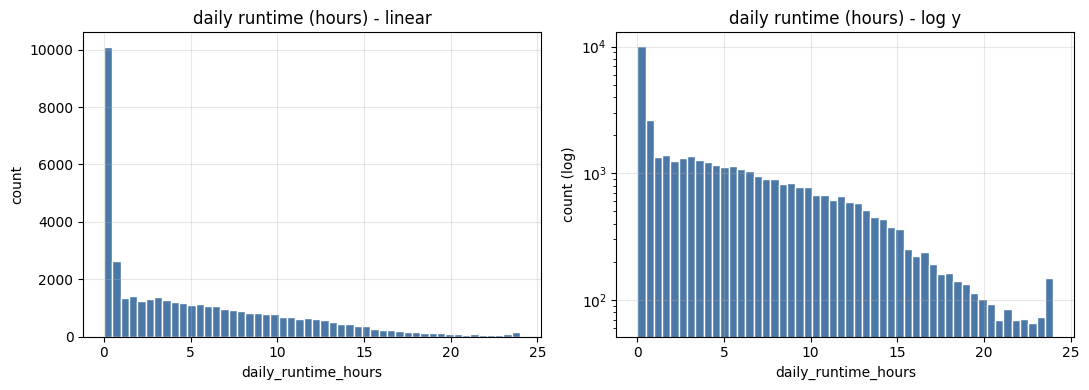

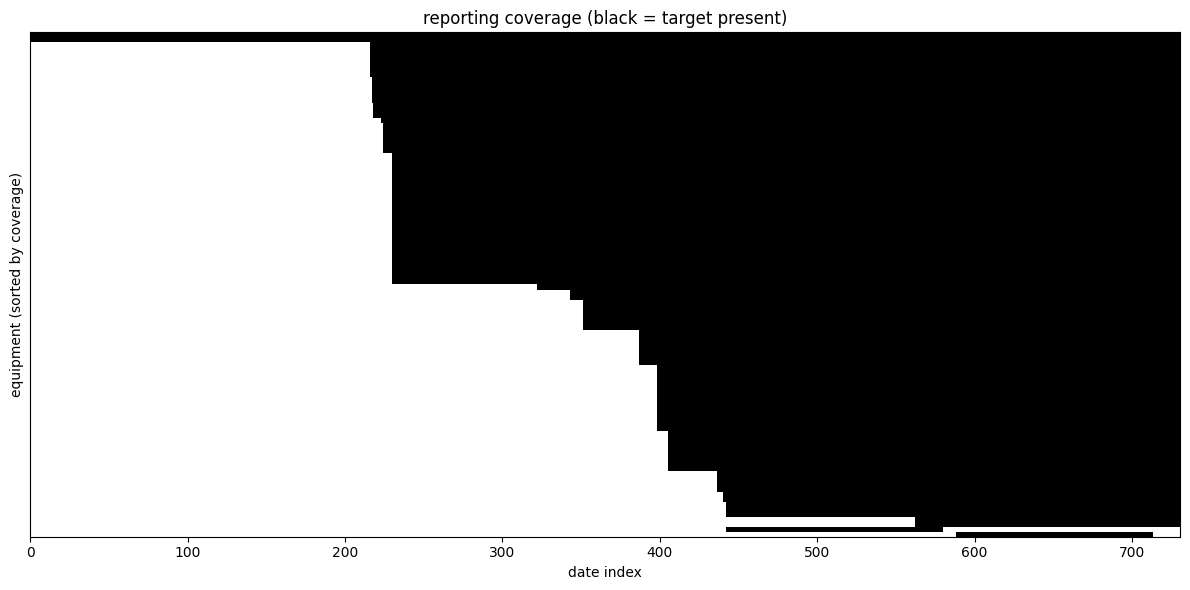

coverage per equipment: mean=0.57, median=0.62, min=0.17


In [12]:
"""
==========================================================================
BLOCK 12: EDA 1 - TARGET DISTRIBUTION AND DATA COVERAGE
==========================================================================
Characterizes the regression target (daily_runtime_hours) and the
reporting coverage across equipment and calendar days. These plots
motivate the treatment of zero-runtime days and the calendar gridding
applied in Block 11.
==========================================================================
"""

# ---------------------------------------------------------------------------
#
# prepare the eda frame (rows with a real target value only)
#
# ---------------------------------------------------------------------------

# isolate rows where the target is present so distribution plots are
# not skewed by calendar-grid padding
#
eda_df = master_processed.dropna(subset=["daily_runtime_hours"]).copy()

# report basic target statistics
#
runtime = eda_df["daily_runtime_hours"]
print("daily_runtime_hours summary:")
print(f"  n           : {len(runtime)}")
print(f"  mean        : {runtime.mean():.3f}")
print(f"  std         : {runtime.std():.3f}")
print(f"  min / max   : {runtime.min():.3f} / {runtime.max():.3f}")
print(f"  zero-days % : {(runtime == 0).mean() * 100:.2f}%")

# ---------------------------------------------------------------------------
#
# figure 1: linear and log histograms of the target
#
# ---------------------------------------------------------------------------

# plot linear and log-scaled histograms side by side
#
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(runtime, bins=50, color="#4c78a8", edgecolor="white")
axes[0].set_title("daily runtime (hours) - linear")
axes[0].set_xlabel("daily_runtime_hours")
axes[0].set_ylabel("count")
axes[0].grid(alpha=0.3)

axes[1].hist(runtime, bins=50, color="#4c78a8", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("daily runtime (hours) - log y")
axes[1].set_xlabel("daily_runtime_hours")
axes[1].set_ylabel("count (log)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
#
# figure 2: per-equipment reporting coverage heatmap
#
# ---------------------------------------------------------------------------

# build a presence matrix of (equipment x date) indicating whether a
# real target reading exists on that day
#
coverage = master_processed.pivot_table(
    index="Equipment_ID", columns="Date",
    values="daily_runtime_hours", aggfunc="first",
).notna().astype(int)

# sort equipment by total coverage descending for a readable figure
#
coverage = coverage.loc[coverage.sum(axis=1).sort_values(ascending=False).index]

# plot the coverage heatmap
#
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(coverage.values, aspect="auto", cmap="Greys", interpolation="nearest")
ax.set_title("reporting coverage (black = target present)")
ax.set_xlabel("date index")
ax.set_ylabel("equipment (sorted by coverage)")
ax.set_yticks([])
plt.tight_layout()
plt.show()

# report coverage statistics
#
per_eq_coverage = coverage.sum(axis=1) / coverage.shape[1]
print(f"coverage per equipment: mean={per_eq_coverage.mean():.2f}, "
      f"median={per_eq_coverage.median():.2f}, "
      f"min={per_eq_coverage.min():.2f}")


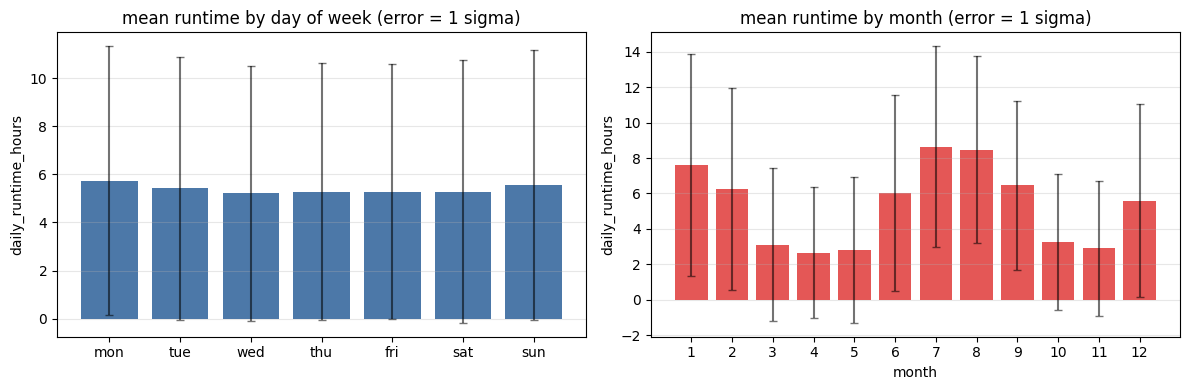

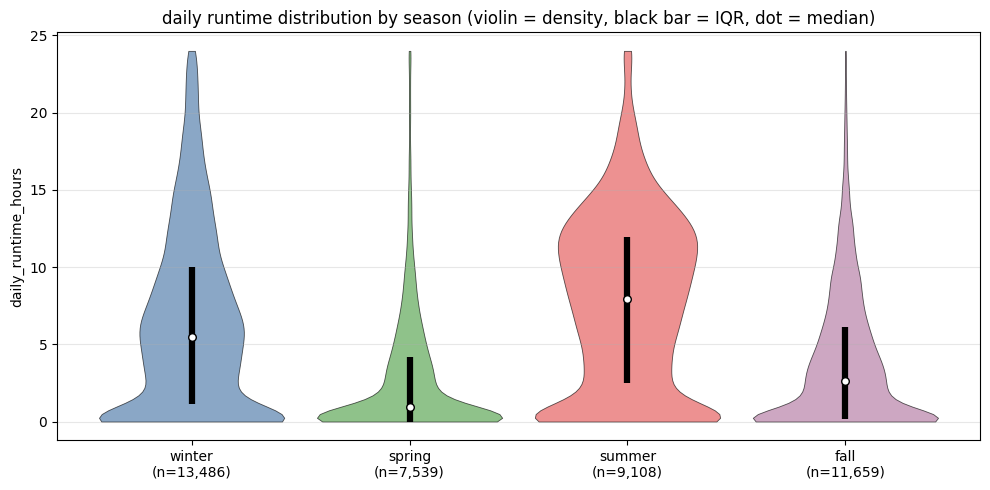

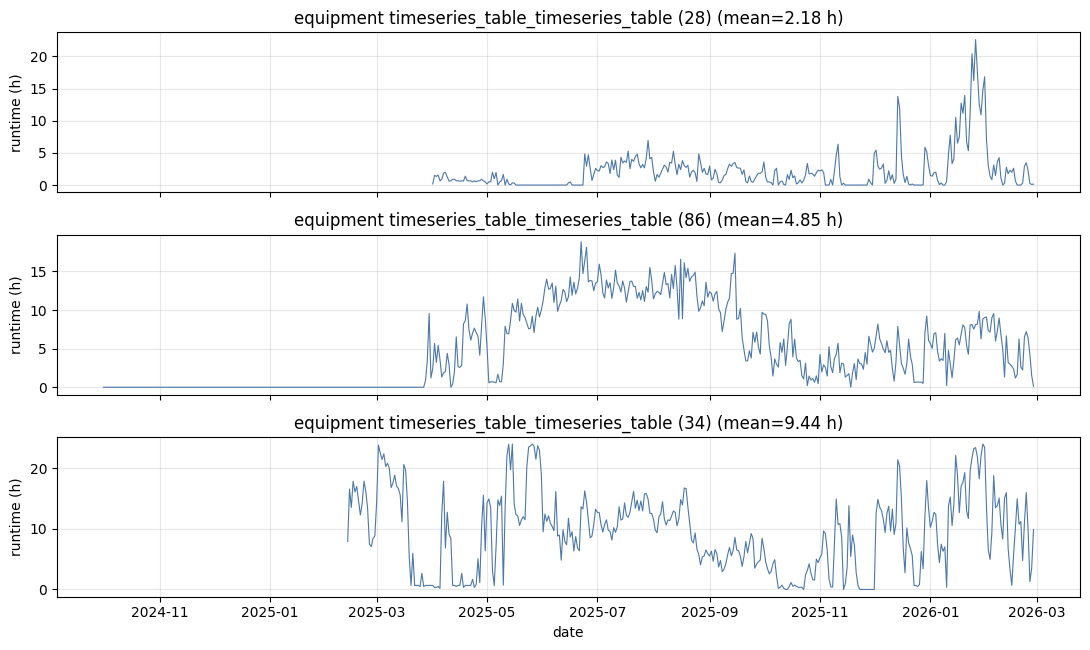

In [13]:
"""
==========================================================================
BLOCK 13: EDA 2 - TEMPORAL STRUCTURE OF RUNTIME
==========================================================================
Breaks daily_runtime_hours down by day-of-week, month, and season, and
overlays a small selection of per-equipment time series. These views
motivate the calendar encodings (day_of_week, is_weekend, month_sin,
month_cos) already in the feature pool and justify the need for lag
features that track evolving per-equipment behavior.
==========================================================================
"""

# reuse the eda frame from block 12 (rows with real targets only)
#
eda_df = master_processed.dropna(subset=["daily_runtime_hours"]).copy()
eda_df["_month"] = eda_df["Date"].dt.month
eda_df["_dow"] = eda_df["Date"].dt.dayofweek


def _season_from_month(m):
    """
    function: _season_from_month

    arguments:
      m: integer month (1-12)

    return:
      string season name

    description:
      maps a calendar month to its meteorological season for plotting;
      mirrors the month_to_season helper defined in block 23.
    """
    if m in {12, 1, 2}:
        return "winter"
    if m in {3, 4, 5}:
        return "spring"
    if m in {6, 7, 8}:
        return "summer"
    return "fall"


eda_df["_season"] = eda_df["_month"].map(_season_from_month)

# ---------------------------------------------------------------------------
#
# figure 1: mean daily runtime by day-of-week and by month
#
# ---------------------------------------------------------------------------

# aggregate mean and std of runtime by day-of-week and by month so the
# bar heights are shown with a one-sigma variability range
#
by_dow_mean = eda_df.groupby("_dow")["daily_runtime_hours"].mean()
by_dow_std = eda_df.groupby("_dow")["daily_runtime_hours"].std()
by_month_mean = eda_df.groupby("_month")["daily_runtime_hours"].mean()
by_month_std = eda_df.groupby("_month")["daily_runtime_hours"].std()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(by_dow_mean.index, by_dow_mean.values,
            yerr=by_dow_std.values, color="#4c78a8",
            capsize=3, error_kw={"ecolor": "black", "alpha": 0.55})
axes[0].set_title("mean runtime by day of week (error = 1 sigma)")
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(["mon", "tue", "wed", "thu", "fri", "sat", "sun"])
axes[0].set_ylabel("daily_runtime_hours")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(by_month_mean.index, by_month_mean.values,
            yerr=by_month_std.values, color="#e45756",
            capsize=3, error_kw={"ecolor": "black", "alpha": 0.55})
axes[1].set_title("mean runtime by month (error = 1 sigma)")
axes[1].set_xlabel("month")
axes[1].set_ylabel("daily_runtime_hours")
axes[1].set_xticks(range(1, 13))
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
#
# figure 2: violin plot of runtime by season (full distribution shown)
#
# ---------------------------------------------------------------------------

# violin plots show the full distribution including the tails, whereas
# the previous boxplot hid outliers and collapsed each group to five
# numbers.  for skewed, heavy-tailed runtime data the tail mass IS the
# story (long heating peaks in winter, idle mass in spring/fall), so
# the distribution shape is informative.
#
season_order = ["winter", "spring", "summer", "fall"]
season_palette = {
    "winter": "#4c78a8",
    "spring": "#54a24b",
    "summer": "#e45756",
    "fall":   "#b279a2",
}
season_data = [eda_df.loc[eda_df["_season"] == s, "daily_runtime_hours"].dropna().values
               for s in season_order]
season_counts = [len(v) for v in season_data]

fig, ax = plt.subplots(figsize=(10, 5))
parts = ax.violinplot(
    season_data,
    positions=range(1, len(season_order) + 1),
    showmeans=False,
    showmedians=False,
    showextrema=False,
    widths=0.85,
)

# color each violin body to match the season, keep the edges visible
#
for body, s in zip(parts["bodies"], season_order):
    body.set_facecolor(season_palette[s])
    body.set_edgecolor("black")
    body.set_linewidth(0.6)
    body.set_alpha(0.65)

# overlay quartile whiskers and the median as a white dot so the
# summary stats are still readable on top of the distribution shape
#
for i, data in enumerate(season_data, start=1):
    if len(data) == 0:
        continue
    q25, q50, q75 = np.percentile(data, [25, 50, 75])
    ax.vlines(i, q25, q75, color="black", linewidth=4.5)
    ax.scatter([i], [q50], color="white", edgecolor="black",
               zorder=5, s=30)

# label each violin with the sample count underneath the x axis
#
ax.set_xticks(range(1, len(season_order) + 1))
ax.set_xticklabels([f"{s}\n(n={n:,})" for s, n in zip(season_order, season_counts)])
ax.set_title("daily runtime distribution by season "
             "(violin = density, black bar = IQR, dot = median)")
ax.set_ylabel("daily_runtime_hours")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
#
# figure 3: sample per-equipment time series (low/median/high activity)
#
# ---------------------------------------------------------------------------

# rank equipment by mean runtime and pick one near low / median / high
#
per_eq_mean = eda_df.groupby("Equipment_ID")["daily_runtime_hours"].mean().sort_values()
if len(per_eq_mean) >= 3:
    pick_ids = [per_eq_mean.index[0],
                per_eq_mean.index[len(per_eq_mean) // 2],
                per_eq_mean.index[-1]]
else:
    pick_ids = per_eq_mean.index.tolist()

fig, axes = plt.subplots(len(pick_ids), 1, figsize=(11, 2.2 * len(pick_ids)),
                          sharex=True)
if len(pick_ids) == 1:
    axes = [axes]
for ax, eq in zip(axes, pick_ids):
    series = eda_df[eda_df["Equipment_ID"] == eq].sort_values("Date")
    ax.plot(series["Date"], series["daily_runtime_hours"],
            color="#4c78a8", linewidth=0.8)
    ax.set_title(f"equipment {eq} (mean={per_eq_mean[eq]:.2f} h)")
    ax.set_ylabel("runtime (h)")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("date")
plt.tight_layout()
plt.show()


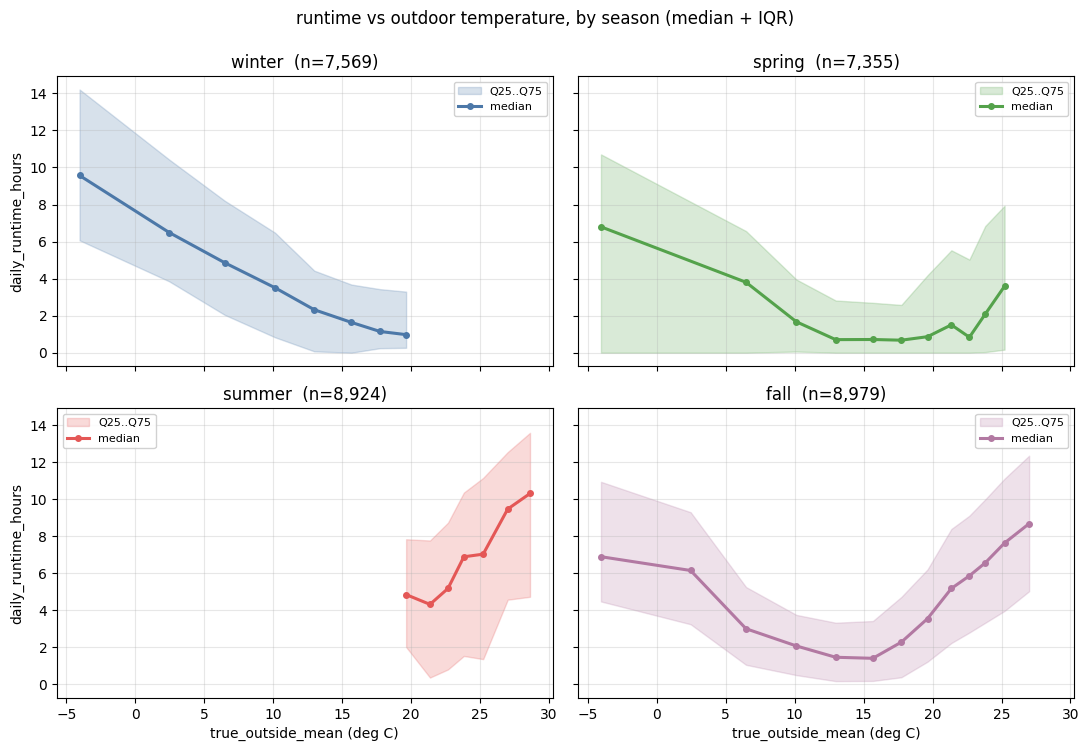

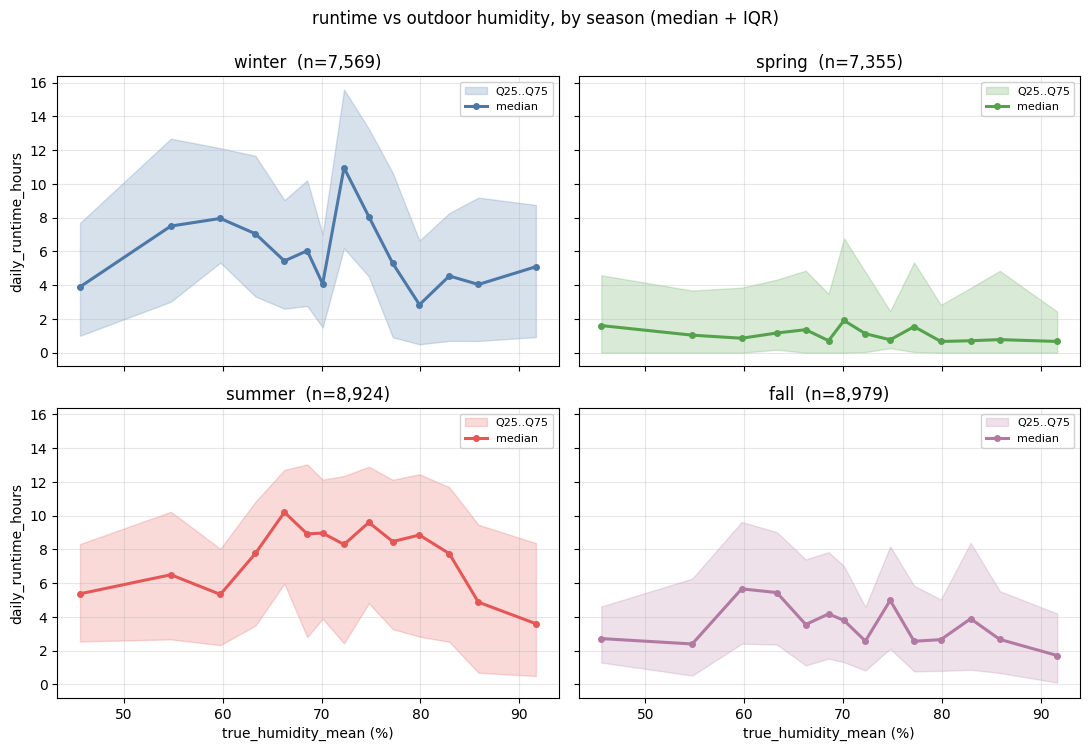

In [14]:
"""
==========================================================================
BLOCK 14: EDA 3 - WEATHER-RUNTIME RELATIONSHIPS
==========================================================================
Shows how daily_runtime_hours responds to outdoor temperature and
outdoor humidity, stratified by meteorological season.  The previous
version stacked all four season curves on a single axis, which made
the cooling-season and heating-season legs overlap and hide each
other.  The new version gives each season its own panel with shared
x and y scales so the four conditional curves are directly
comparable, and drops the hexbin density / gradient overlays that
did not add information beyond the season curves.
==========================================================================
"""

# reuse the eda frame
#
eda_df = master_processed.dropna(subset=["daily_runtime_hours"]).copy()

# attach a season label by month so we can stratify the curves
#
_SEASON_ORDER = ["winter", "spring", "summer", "fall"]
_SEASON_COLOR = {
    "winter": "#4c78a8",
    "spring": "#54a24b",
    "summer": "#e45756",
    "fall":   "#b279a2",
}


def _month_to_season(m):
    """
    function: _month_to_season

    arguments:
      m: integer month (1-12)

    return:
      string season name

    description:
      local helper mirroring month_to_season from block 23.  kept local
      so this EDA cell can run before block 23 defines its version.
    """
    if m in {12, 1, 2}:
        return "winter"
    if m in {3, 4, 5}:
        return "spring"
    if m in {6, 7, 8}:
        return "summer"
    return "fall"


eda_df["_season"] = pd.to_datetime(eda_df["Date"]).dt.month.map(_month_to_season)


def _conditional_quantiles(x, y, n_bins=20, min_bin=25, edges=None):
    """
    function: _conditional_quantiles

    arguments:
      x: driver array (e.g. outdoor temperature)
      y: response array (runtime)
      n_bins: number of equal-count bins along x (ignored if edges given)
      min_bin: minimum samples required in a bin to emit a value
      edges: optional pre-computed bin edges so all panels share the
        same x-axis discretization

    return:
      tuple (centers, q25, q50, q75, counts) of numpy arrays

    description:
      splits x into equal-count quantile bins and computes the 25/50/75
      percentiles of y within each bin.  accepting an externally
      provided edges array lets multiple panels share identical bin
      locations so the faceted season curves line up in x.
    """

    # drop nan pairs so np.quantile does not error
    #
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    if len(x) < min_bin * 2:
        return (np.array([]),) * 5

    # build quantile edges on x unless caller supplied them
    #
    if edges is None:
        qs = np.linspace(0, 1, n_bins + 1)
        edges = np.quantile(x, qs)

    # walk each bin and summarize
    #
    centers, q25, q50, q75, counts = [], [], [], [], []
    nb = len(edges) - 1
    for i in range(nb):
        lo, hi = edges[i], edges[i + 1]
        m = (x >= lo) & (x <= hi if i == nb - 1 else x < hi)
        if m.sum() < min_bin:
            continue
        centers.append(0.5 * (lo + hi))
        yi = y[m]
        q25.append(np.percentile(yi, 25))
        q50.append(np.percentile(yi, 50))
        q75.append(np.percentile(yi, 75))
        counts.append(m.sum())
    return (np.array(centers), np.array(q25), np.array(q50),
            np.array(q75), np.array(counts))


def _facet_weather_runtime(feature_col, xlabel, title):
    """
    function: _facet_weather_runtime

    arguments:
      feature_col: column name in eda_df for the x-axis driver
      xlabel: x-axis label shared across facets
      title: overall figure title

    return:
      None

    description:
      draws a 2 x 2 grid where each panel shows the conditional
      median + IQR of runtime vs the driver for a single season,
      with shared x and y axes so panels are directly comparable.
      uses a single shared set of equal-count bin edges computed on
      the pooled x values, so all four panels snap to the same x
      locations.
    """
    sub = eda_df.dropna(subset=[feature_col, "daily_runtime_hours"])
    if len(sub) < 200:
        return

    # shared bin edges from pooled x so panels line up visually
    #
    x_all = sub[feature_col].values
    lo_x, hi_x = np.percentile(x_all, [0.5, 99.5])
    pooled = x_all[(x_all >= lo_x) & (x_all <= hi_x)]
    shared_edges = np.quantile(pooled, np.linspace(0, 1, 15))

    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5),
                             sharex=True, sharey=True)
    for ax, season in zip(axes.flatten(), _SEASON_ORDER):
        ss = sub[sub["_season"] == season]
        if len(ss) < 80:
            ax.set_title(f"{season} (no data)")
            ax.grid(alpha=0.3)
            continue
        centers, q25, q50, q75, counts = _conditional_quantiles(
            ss[feature_col].values,
            ss["daily_runtime_hours"].values,
            edges=shared_edges,
            min_bin=15,
        )
        color = _SEASON_COLOR[season]
        if len(centers):
            ax.fill_between(centers, q25, q75, color=color, alpha=0.22,
                            label="Q25..Q75")
            ax.plot(centers, q50, color=color, linewidth=2.2,
                    marker="o", markersize=4.0, label="median")
        ax.set_title(f"{season}  (n={len(ss):,})")
        ax.grid(alpha=0.3)
        ax.legend(loc="best", fontsize=8, framealpha=0.9)

    # place axis labels only on the outer edges of the 2x2 grid
    #
    for ax in axes[1, :]:
        ax.set_xlabel(xlabel)
    for ax in axes[:, 0]:
        ax.set_ylabel("daily_runtime_hours")
    fig.suptitle(title, y=0.995, fontsize=12)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
#
# figure 1: runtime vs outdoor temperature, one panel per season
#
# ---------------------------------------------------------------------------

# each panel shares x/y scales so the heating leg in winter/fall and
# the cooling leg in summer can be read against each other at a
# glance.  spring sits in the low-runtime shoulder band and is the
# baseline non-thermal reference.
#
_facet_weather_runtime(
    "true_outside_mean",
    xlabel="true_outside_mean (deg C)",
    title="runtime vs outdoor temperature, by season (median + IQR)",
)

# ---------------------------------------------------------------------------
#
# figure 2: runtime vs outdoor humidity, one panel per season
#
# ---------------------------------------------------------------------------

# humidity is a secondary thermal driver: in summer the latent cooling
# load rises with humidity and pushes runtime up.  faceting makes the
# summer slope visible without the heating-leg curves obscuring it.
#
_facet_weather_runtime(
    "true_humidity_mean",
    xlabel="true_humidity_mean (%)",
    title="runtime vs outdoor humidity, by season (median + IQR)",
)


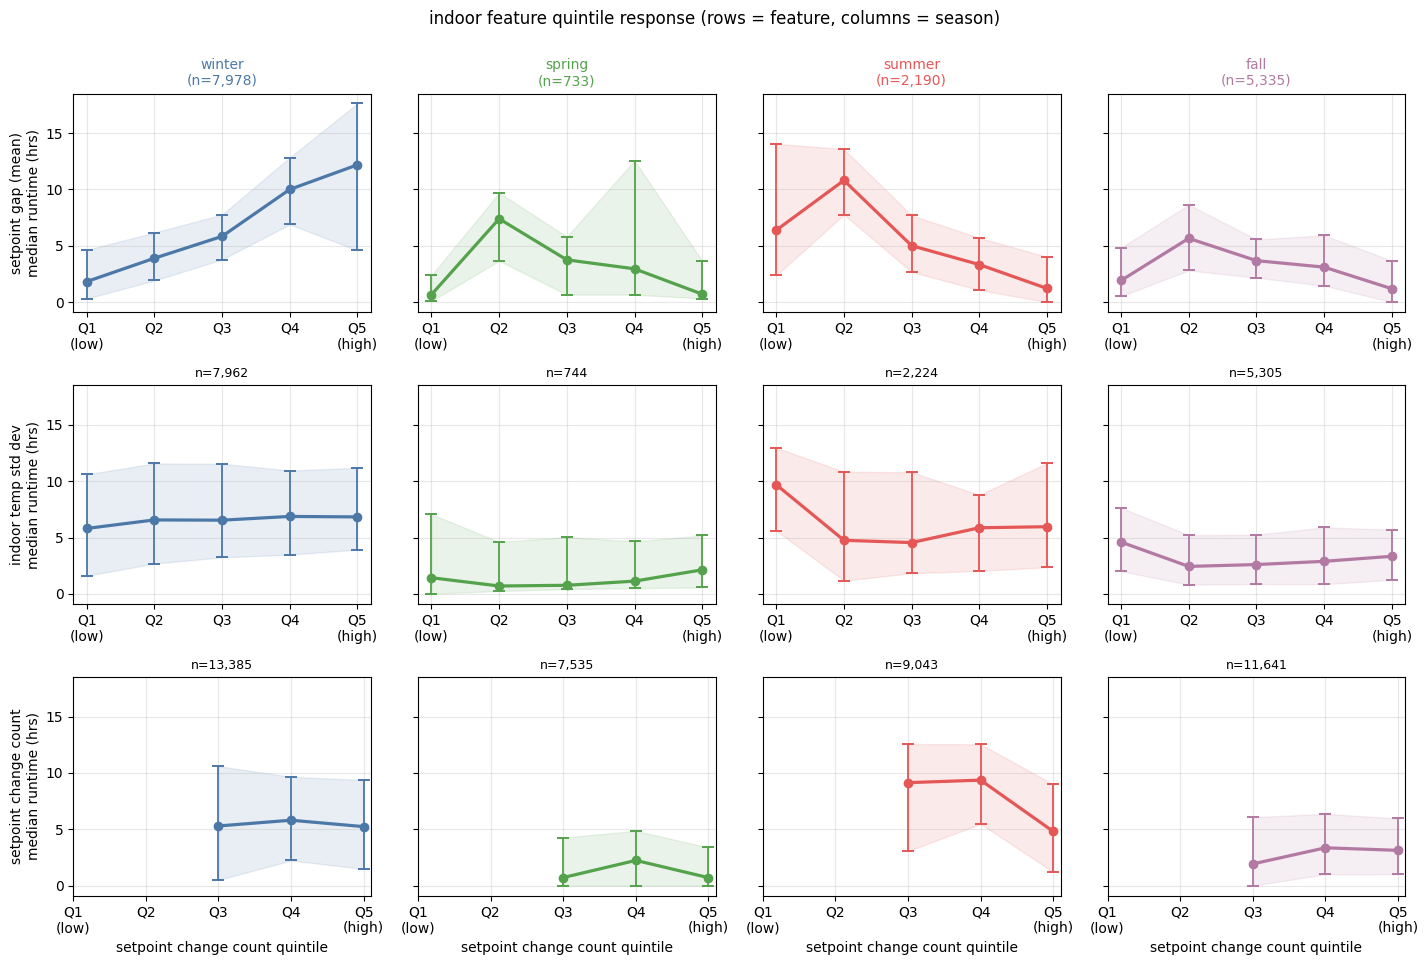

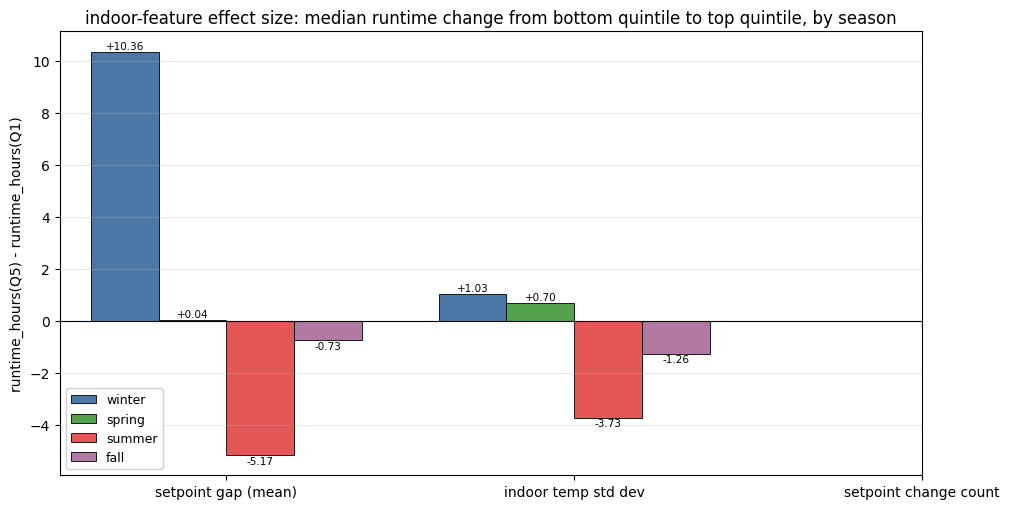

In [15]:
"""
==========================================================================
BLOCK 15: EDA 4 - INDOOR DYNAMICS VS RUNTIME (INTERACTION VIEW)
==========================================================================
Examines how three indoor comfort indicators (setpoint gap, indoor
temperature dispersion, setpoint change count) drive daily runtime,
and whether that relationship depends on season.  Figure 1 shows the
quintile response curve with one panel per (feature, season), shared
y across the whole figure and shared x within each feature row, so
each season gets its own clean axis instead of four curves fighting
on one plot.  Figure 2 compresses each season-feature pair to a
single Q5 - Q1 effect size so the direction and magnitude of each
relationship is directly comparable.
==========================================================================
"""

# reuse the eda frame built in block 14
#
eda_df = master_processed.dropna(subset=["daily_runtime_hours"]).copy()
if "_season" not in eda_df.columns:
    eda_df["_season"] = pd.to_datetime(eda_df["Date"]).dt.month.map(
        _month_to_season
    )


def _quintile_profile(sub_df, col, edges, min_n=15):
    """
    function: _quintile_profile

    arguments:
      sub_df: slice of eda_df to summarize (e.g. a single season)
      col: indoor feature column name
      edges: shared quintile edges on the pooled feature values
      min_n: minimum per-bin sample size to emit a value

    return:
      (medians, q25s, q75s, counts) numpy arrays, length = len(edges) - 1

    description:
      for each of the five pooled quintile bins of col, computes the
      median and IQR of daily_runtime_hours on the rows of sub_df
      that fall in that bin.  returns NaN for any bin whose row
      count is below min_n so sparse shoulder-season slices do not
      produce a spuriously smooth curve.
    """
    n = len(edges) - 1
    medians = np.full(n, np.nan)
    q25s = np.full(n, np.nan)
    q75s = np.full(n, np.nan)
    counts = np.zeros(n, dtype=int)
    xv = sub_df[col].values
    yv = sub_df["daily_runtime_hours"].values
    for i in range(n):
        lo, hi = edges[i], edges[i + 1]
        m = (xv >= lo) & (xv <= hi if i == n - 1 else xv < hi)
        yi = yv[m]
        yi = yi[~np.isnan(yi)]
        counts[i] = len(yi)
        if len(yi) >= min_n:
            medians[i] = np.median(yi)
            q25s[i] = np.percentile(yi, 25)
            q75s[i] = np.percentile(yi, 75)
    return medians, q25s, q75s, counts


# indoor comfort features to profile; keep only those present
#
targets_plot = [
    ("setpoint_gap_mean", "setpoint gap (mean)"),
    ("indoor_temp_std", "indoor temp std dev"),
    ("setpoint_change_count", "setpoint change count"),
]
available = [(c, lbl) for (c, lbl) in targets_plot if c in eda_df.columns]

# ---------------------------------------------------------------------------
#
# figure 1: feature-by-season grid of quintile response curves
#
# ---------------------------------------------------------------------------

# one row per indoor feature, one column per season.  each panel has
# five equal-count quintile markers (Q1..Q5) on the x-axis and the
# median daily_runtime_hours with IQR whiskers on the y-axis.
# reading the figure:
#   - slope inside a panel = feature effect within that season
#   - difference across columns at the same quintile = season effect
#   - shared y across the whole figure makes effect magnitudes
#     directly comparable across features and seasons
#
if available:
    n_feat = len(available)
    n_season = len(_SEASON_ORDER)
    fig, axes = plt.subplots(
        n_feat, n_season,
        figsize=(3.6 * n_season, 3.2 * n_feat),
        sharey=True,
    )
    
    # axes shape: (n_feat, n_season).  normalize to 2-d even when
    # n_feat == 1 so the loops below stay uniform.
    #
    if n_feat == 1:
        axes = np.array([axes])

    xpos = np.arange(5)
    quintile_labels = ["Q1\n(low)", "Q2", "Q3", "Q4", "Q5\n(high)"]

    for row_i, (col, lbl) in enumerate(available):
        sub = eda_df.dropna(subset=[col, "daily_runtime_hours"])
        if len(sub) < 200:
            for ax in axes[row_i]:
                ax.set_title(f"{lbl} (insufficient data)")
            continue

        # clip tails for display, compute shared quintile edges on
        # the pooled clipped data so all season panels in this row
        # share the same x-axis discretization
        #
        xv_all = sub[col].values
        lo_x, hi_x = np.percentile(xv_all, [0.5, 99.5])
        sub = sub[(sub[col] >= lo_x) & (sub[col] <= hi_x)]
        edges = np.quantile(sub[col].values, np.linspace(0, 1, 6))

        for col_j, season in enumerate(_SEASON_ORDER):
            ax = axes[row_i, col_j]
            ss = sub[sub["_season"] == season]
            color = _SEASON_COLOR[season]

            if len(ss) < 80:
                ax.set_title(f"{season} (no data)")
                ax.grid(alpha=0.3)
                ax.set_xticks(xpos)
                ax.set_xticklabels(quintile_labels)
                if row_i == n_feat - 1:
                    ax.set_xlabel(f"{lbl} quintile")
                if col_j == 0:
                    ax.set_ylabel("median runtime (hrs)")
                continue

            medians, q25s, q75s, counts = _quintile_profile(
                ss, col, edges, min_n=15
            )

            # asymmetric IQR whiskers around the median
            #
            lower = medians - q25s
            upper = q75s - medians
            ax.errorbar(
                xpos, medians,
                yerr=[lower, upper],
                color=color, linewidth=2.3,
                marker="o", markersize=6.0,
                capsize=4, capthick=1.4,
                elinewidth=1.3,
            )
            # faint band connecting Q25..Q75 for visual continuity
            #
            ok = ~(np.isnan(q25s) | np.isnan(q75s))
            if ok.any():
                ax.fill_between(
                    xpos[ok], q25s[ok], q75s[ok],
                    color=color, alpha=0.12, step=None,
                )
            ax.set_xticks(xpos)
            ax.set_xticklabels(quintile_labels)
            ax.grid(alpha=0.3)

            # titles, axis labels only on outer edges to reduce clutter
            #
            if row_i == 0:
                ax.set_title(f"{season}\n(n={int(counts.sum()):,})",
                             color=color, fontsize=10)
            else:
                ax.set_title(f"n={int(counts.sum()):,}", fontsize=9)
            if row_i == n_feat - 1:
                ax.set_xlabel(f"{lbl} quintile")
            if col_j == 0:
                ax.set_ylabel(f"{lbl}\nmedian runtime (hrs)")

    fig.suptitle(
        "indoor feature quintile response (rows = feature, columns = season)",
        y=1.0, fontsize=12,
    )
    plt.tight_layout()
    plt.show()
else:
    print("no indoor comfort features available for plotting")

# ---------------------------------------------------------------------------
#
# figure 2: effect-size summary - runtime delta from Q1 to Q5 per feature
#
# ---------------------------------------------------------------------------

# the faceted interaction grid above answers "is there a relationship",
# this grouped bar chart compresses each (feature, season) pair into
# a single scalar: median_runtime(Q5) - median_runtime(Q1), so the
# sign and magnitude of each effect can be read against the others
# at a glance.
#
if available:
    fig, ax = plt.subplots(
        figsize=(max(8.5, 2.4 * len(available) + 3.0), 5.2)
    )

    n_feat = len(available)
    n_season = len(_SEASON_ORDER)
    width = 0.78 / n_season
    group_centers = np.arange(n_feat)

    for s_idx, season in enumerate(_SEASON_ORDER):
        deltas = []
        for (col, lbl) in available:
            sub = eda_df.dropna(subset=[col, "daily_runtime_hours"])
            if len(sub) < 200:
                deltas.append(np.nan)
                continue
            xv_all = sub[col].values
            lo_x, hi_x = np.percentile(xv_all, [0.5, 99.5])
            sub = sub[(sub[col] >= lo_x) & (sub[col] <= hi_x)]
            edges = np.quantile(sub[col].values, np.linspace(0, 1, 6))
            ss = sub[sub["_season"] == season]
            if len(ss) < 80:
                deltas.append(np.nan)
                continue
            medians, _, _, _ = _quintile_profile(ss, col, edges, min_n=15)
            if np.isnan(medians[0]) or np.isnan(medians[-1]):
                deltas.append(np.nan)
            else:
                deltas.append(medians[-1] - medians[0])

        offset = (s_idx - (n_season - 1) / 2) * width
        xs = group_centers + offset
        bars = ax.bar(
            xs, deltas, width=width,
            color=_SEASON_COLOR[season],
            edgecolor="black", linewidth=0.6,
            label=season,
        )

        # annotate each bar with its value for readability
        #
        for b, v in zip(bars, deltas):
            if np.isnan(v):
                continue
            ax.text(
                b.get_x() + b.get_width() / 2,
                v + (0.03 if v >= 0 else -0.03),
                f"{v:+.2f}",
                ha="center",
                va="bottom" if v >= 0 else "top",
                fontsize=7.5,
            )

    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_xticks(group_centers)
    ax.set_xticklabels([lbl for (_, lbl) in available])
    ax.set_ylabel("runtime_hours(Q5) - runtime_hours(Q1)")
    ax.set_title(
        "indoor-feature effect size: median runtime change from bottom "
        "quintile to top quintile, by season"
    )
    ax.grid(alpha=0.3, axis="y")
    ax.legend(loc="best", fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.show()


ACF computed on 100 equipment series
CCF (runtime vs outdoor mean) computed on 100 equipment series
  CCF rows for winter: 99
  CCF rows for spring: 87
  CCF rows for summer: 97
  CCF rows for fall: 99


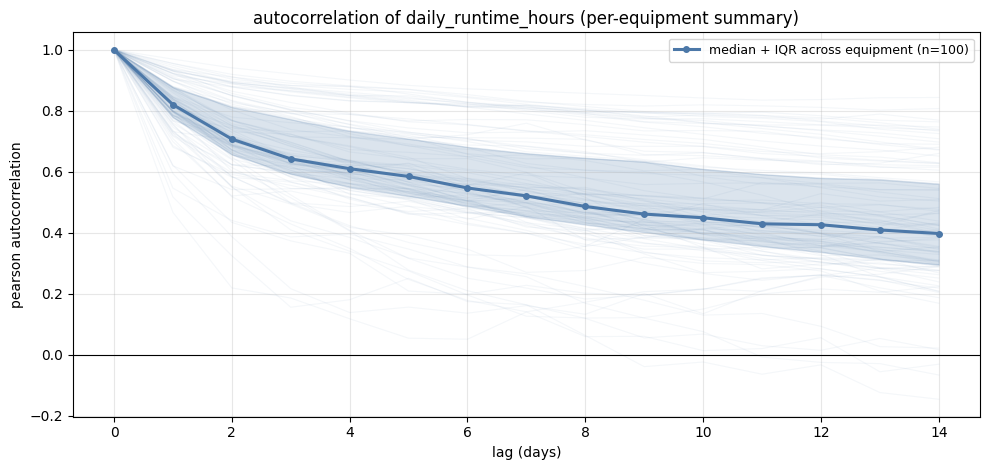

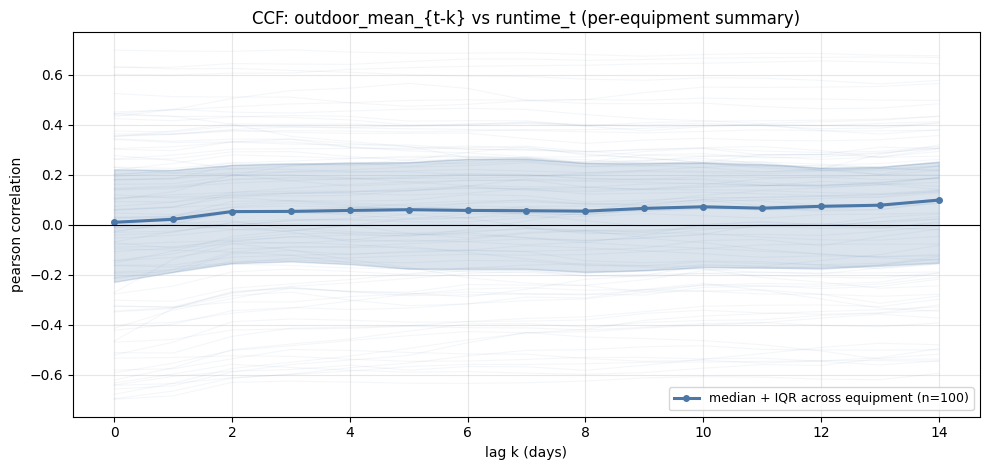

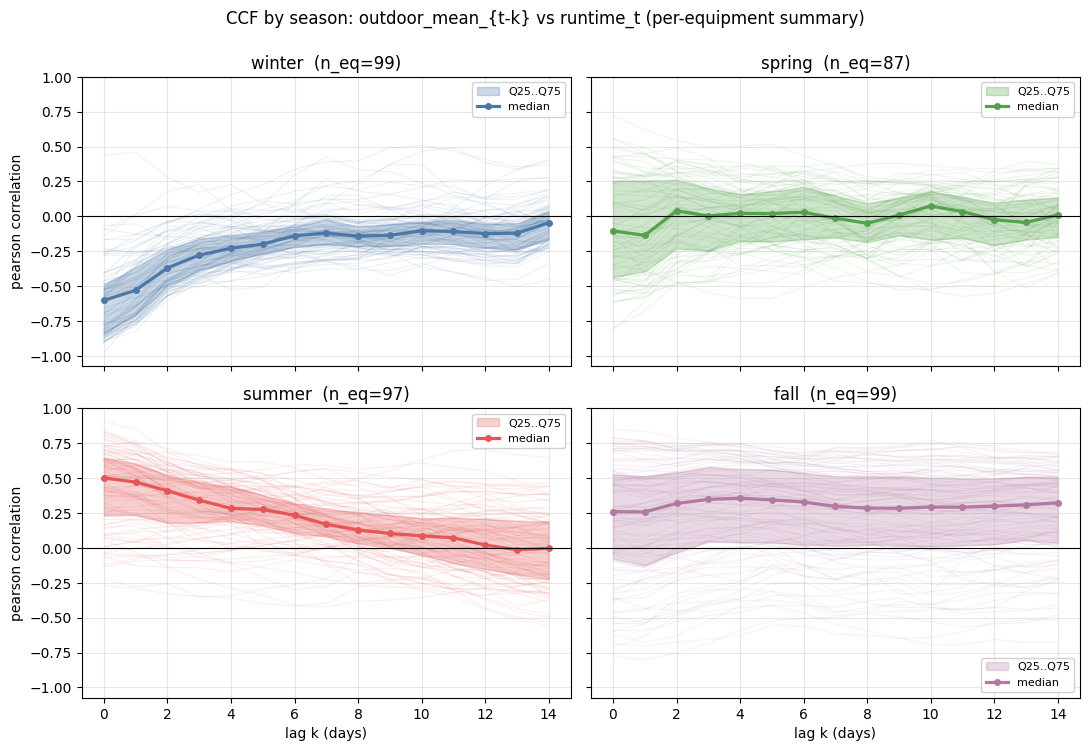

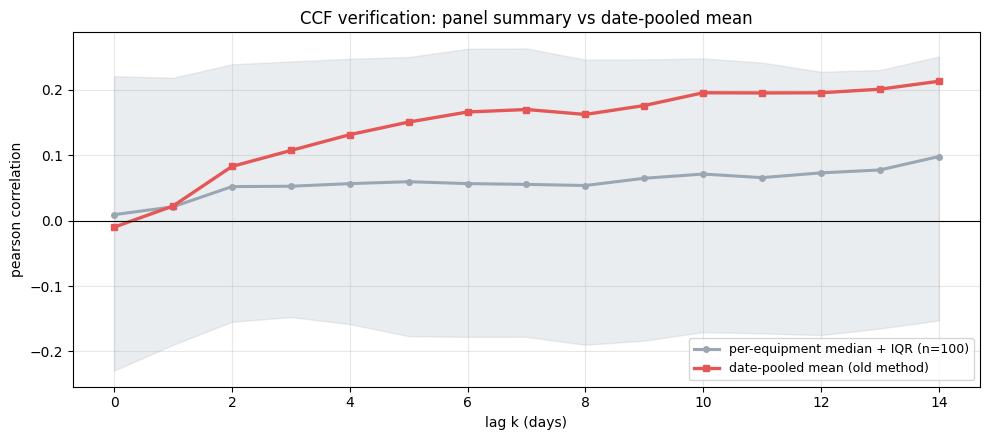

In [16]:
"""
==========================================================================
BLOCK 16: EDA 5 - AUTOCORRELATION AND CROSS-CORRELATION
==========================================================================
Computes the autocorrelation of daily_runtime_hours across every
equipment (not just a sample of three), and the cross-correlation of
runtime with true_outside_mean at lags 0..14.  Summarizes both as
median + IQR bands over equipments.  The season-stratified CCF is
now rendered as a 2x2 facet with shared x and y scales so the four
season curves can be compared against each other directly instead of
being overplotted on a single axis.  All correlation helpers skip
constant-variance series explicitly so np.corrcoef no longer emits
a divide-by-zero warning for houses with flat runtime in a season.
These diagnostics directly motivate LAG_DAYS and the lag-window
sweep in Block 28.
==========================================================================
"""

# maximum lag in days for the diagnostic plots
#
MAX_LAG_DAYS_EDA = 14


def _safe_corr(a, b):
    """
    function: _safe_corr

    arguments:
      a: 1-d numpy array
      b: 1-d numpy array (same length)

    return:
      float pearson correlation, or nan if either series is constant
      or has fewer than two finite entries

    description:
      thin wrapper around np.corrcoef that skips the computation when
      either series has zero standard deviation.  the original code
      used pandas .corr() which silently emitted
      "RuntimeWarning: invalid value encountered in scalar divide"
      for every season where a house had constant runtime (mostly
      short or frozen-thermostat records).  returning NaN explicitly
      keeps the downstream nanmedian / nanpercentile summary correct
      and suppresses the warning noise.
    """
    if len(a) < 2 or len(b) < 2:
        return np.nan
    sa = float(np.nanstd(a))
    sb = float(np.nanstd(b))
    if not (np.isfinite(sa) and np.isfinite(sb)
            and sa > 1e-12 and sb > 1e-12):
        return np.nan
    with np.errstate(invalid="ignore", divide="ignore"):
        c = np.corrcoef(a, b)[0, 1]
    return c if np.isfinite(c) else np.nan


def _autocorr_series(series, max_lag):
    """
    function: _autocorr_series

    arguments:
      series: 1-d pandas Series of daily values
      max_lag: integer upper bound on lag in days

    return:
      numpy array of length max_lag + 1 with autocorrelation coefficients

    description:
      computes pearson autocorrelation between a series and its shifted
      copy at each lag, skipping rows where either side is missing.
      uses _safe_corr so constant segments do not raise.
    """
    out = np.full(max_lag + 1, np.nan)
    out[0] = 1.0
    for k in range(1, max_lag + 1):
        pair = pd.concat([series, series.shift(k)], axis=1).dropna()
        if len(pair) >= 20:
            out[k] = _safe_corr(pair.iloc[:, 0].values,
                                pair.iloc[:, 1].values)
    return out


def _cross_corr_series(y, x, max_lag):
    """
    function: _cross_corr_series

    arguments:
      y: target series (runtime)
      x: driver series, same index as y (outdoor mean)
      max_lag: maximum lag in days

    return:
      numpy array of length max_lag + 1, where out[k] is
      corr(y_t, x_{t-k}): positive lag k means x leads y by k days

    description:
      shifts x forward by k days so that each row aligns today's y
      with x from k days ago, then computes pearson correlation via
      _safe_corr over non-null rows.  correct for panel data only
      when applied to each equipment's own aligned daily series
      (which is what this block does below).
    """
    out = np.full(max_lag + 1, np.nan)
    for k in range(max_lag + 1):
        pair = pd.concat([y, x.shift(k)], axis=1).dropna()
        if len(pair) >= 20:
            out[k] = _safe_corr(pair.iloc[:, 0].values,
                                pair.iloc[:, 1].values)
    return out


# iterate over every equipment and compute ACF + CCF per series.  this
# replaces the old sampling of only the first three equipment ids,
# which was not representative of the 100-unit panel.
#
eq_ids_all = master_processed["Equipment_ID"].dropna().unique()

# accumulators: one row per equipment, one column per lag
#
acf_rows = []
ccf_rows = []
ccf_by_season = {s: [] for s in ["winter", "spring", "summer", "fall"]}


def _season_from_month_local(m):
    """
    function: _season_from_month_local

    arguments:
      m: integer month (1-12)

    return:
      string season name

    description:
      local helper so this block stays runnable before Block 23
      defines the canonical month_to_season.
    """
    if m in {12, 1, 2}:
        return "winter"
    if m in {3, 4, 5}:
        return "spring"
    if m in {6, 7, 8}:
        return "summer"
    return "fall"


for eq in eq_ids_all:
    sub = (master_processed[master_processed["Equipment_ID"] == eq]
           .sort_values("Date"))
    if len(sub) < (MAX_LAG_DAYS_EDA + 40):
        continue

    # per-equipment runtime ACF
    #
    acf_rows.append(_autocorr_series(
        sub["daily_runtime_hours"].reset_index(drop=True),
        MAX_LAG_DAYS_EDA))

    # per-equipment runtime vs outdoor-mean CCF.  computing on the
    # equipment's own calendar preserves any daily alignment that a
    # cross-equipment pooled mean could wash out.
    #
    if "true_outside_mean" in sub.columns:
        y_eq = sub["daily_runtime_hours"].reset_index(drop=True)
        x_eq = sub["true_outside_mean"].reset_index(drop=True)
        ccf_rows.append(_cross_corr_series(y_eq, x_eq, MAX_LAG_DAYS_EDA))

        # season-stratified CCF: restrict both y and x to rows where
        # the equipment was in that season.
        #
        s_sub = sub.assign(_season=pd.to_datetime(sub["Date"]).dt.month
                           .map(_season_from_month_local))
        for season in ["winter", "spring", "summer", "fall"]:
            ss = s_sub[s_sub["_season"] == season]
            if len(ss) < (MAX_LAG_DAYS_EDA + 20):
                continue
            y_s = ss["daily_runtime_hours"].reset_index(drop=True)
            x_s = ss["true_outside_mean"].reset_index(drop=True)
            ccf_by_season[season].append(
                _cross_corr_series(y_s, x_s, MAX_LAG_DAYS_EDA)
            )

acf_arr = np.array(acf_rows) if acf_rows else np.zeros((0, MAX_LAG_DAYS_EDA + 1))
ccf_arr = np.array(ccf_rows) if ccf_rows else np.zeros((0, MAX_LAG_DAYS_EDA + 1))

print(f"ACF computed on {len(acf_arr)} equipment series")
print(f"CCF (runtime vs outdoor mean) computed on {len(ccf_arr)} equipment series")
for s in ["winter", "spring", "summer", "fall"]:
    print(f"  CCF rows for {s}: {len(ccf_by_season[s])}")


def _plot_band(ax, mat, lags, color, label):
    """
    function: _plot_band

    arguments:
      ax: matplotlib axis
      mat: 2-d array, rows over equipment, columns over lags
      lags: integer lag indices
      color: line and fill color
      label: legend label

    return:
      None

    description:
      plots the median line plus the 25..75 percentile band across
      equipment.  with _safe_corr producing NaN for degenerate
      series, np.nanmedian / np.nanpercentile skip those rows
      cleanly without warnings.
    """
    if len(mat) == 0:
        return
    with np.errstate(invalid="ignore"):
        med = np.nanmedian(mat, axis=0)
        q25 = np.nanpercentile(mat, 25, axis=0)
        q75 = np.nanpercentile(mat, 75, axis=0)
    ax.fill_between(lags, q25, q75, color=color, alpha=0.20)
    ax.plot(lags, med, color=color, linewidth=2.2, marker="o",
            markersize=4.0, label=label)


# ---------------------------------------------------------------------------
#
# figure 1: autocorrelation of daily_runtime_hours across all equipment
#
# ---------------------------------------------------------------------------

lags = np.arange(MAX_LAG_DAYS_EDA + 1)
fig, ax = plt.subplots(figsize=(10, 4.8))

# thin per-equipment traces in the background for texture
#
for row in acf_arr:
    ax.plot(lags, row, color="#4c78a8", alpha=0.06, linewidth=0.8)

_plot_band(ax, acf_arr, lags, color="#4c78a8",
           label=f"median + IQR across equipment (n={len(acf_arr)})")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_title("autocorrelation of daily_runtime_hours (per-equipment summary)")
ax.set_xlabel("lag (days)")
ax.set_ylabel("pearson autocorrelation")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
#
# figure 2: cross-correlation runtime vs outdoor mean - per-equipment summary
#
# ---------------------------------------------------------------------------

# computed on each equipment's OWN aligned series rather than on a
# date-pooled mean.  treat this as the primary pooled CCF view.
#
fig, ax = plt.subplots(figsize=(10, 4.8))
for row in ccf_arr:
    ax.plot(lags, row, color="#4c78a8", alpha=0.06, linewidth=0.8)
_plot_band(ax, ccf_arr, lags, color="#4c78a8",
           label=f"median + IQR across equipment (n={len(ccf_arr)})")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_title("CCF: outdoor_mean_{t-k} vs runtime_t (per-equipment summary)")
ax.set_xlabel("lag k (days)")
ax.set_ylabel("pearson correlation")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
#
# figure 3: season-stratified cross-correlation, 2x2 facet
#
# ---------------------------------------------------------------------------

# heating and cooling correlate with outdoor temperature with opposite
# signs, so the within-season CCF amplitude matters more than the
# pooled one.  faceting gives each season its own panel on shared
# x and y scales, so the negative-sloped cooling CCF in summer and
# the positive-sloped heating CCF in winter can be compared directly.
#
_season_color = {
    "winter": "#4c78a8",
    "spring": "#54a24b",
    "summer": "#e45756",
    "fall":   "#b279a2",
}
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5),
                         sharex=True, sharey=True)
for ax, season in zip(axes.flatten(), ["winter", "spring", "summer", "fall"]):
    rows = ccf_by_season[season]
    color = _season_color[season]
    if not rows:
        ax.set_title(f"{season} (no data)")
        ax.axhline(0.0, color="black", linewidth=0.8)
        ax.grid(alpha=0.3)
        continue
    mat = np.array(rows)

    # faint per-equipment traces in the background
    #
    for row in mat:
        ax.plot(lags, row, color=color, alpha=0.10, linewidth=0.8)

    with np.errstate(invalid="ignore"):
        med = np.nanmedian(mat, axis=0)
        q25 = np.nanpercentile(mat, 25, axis=0)
        q75 = np.nanpercentile(mat, 75, axis=0)
    ax.fill_between(lags, q25, q75, color=color, alpha=0.28,
                    label="Q25..Q75")
    ax.plot(lags, med, color=color, linewidth=2.3, marker="o",
            markersize=4.0, label="median")
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_title(f"{season}  (n_eq={len(rows)})")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=8, framealpha=0.9)

# place axis labels only on the outer edges
#
for ax in axes[1, :]:
    ax.set_xlabel("lag k (days)")
for ax in axes[:, 0]:
    ax.set_ylabel("pearson correlation")
fig.suptitle("CCF by season: outdoor_mean_{t-k} vs runtime_t "
             "(per-equipment summary)", y=0.995, fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
#
# figure 4: cross-check - date-pooled CCF (the old calculation)
#
# ---------------------------------------------------------------------------

# kept as a sanity check against the per-equipment panel summary.
# if the pooled curve agrees with the panel median, the outdoor
# weather series is genuinely shared across houses on each date and
# both approaches are valid; if they diverge, the per-equipment
# panel summary is the correct one because it respects the panel
# structure of the data.
#
pooled = master_processed.dropna(
    subset=["daily_runtime_hours", "true_outside_mean"]
).groupby("Date").agg({
    "daily_runtime_hours": "mean",
    "true_outside_mean": "mean",
}).sort_index()
xc_pooled = _cross_corr_series(
    pooled["daily_runtime_hours"],
    pooled["true_outside_mean"],
    MAX_LAG_DAYS_EDA,
)

fig, ax = plt.subplots(figsize=(10, 4.5))
_plot_band(ax, ccf_arr, lags, color="#9aa7b3",
           label=f"per-equipment median + IQR (n={len(ccf_arr)})")
ax.plot(lags, xc_pooled, color="#e45756", linewidth=2.4, marker="s",
        markersize=4.0, label="date-pooled mean (old method)")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_title("CCF verification: panel summary vs date-pooled mean")
ax.set_xlabel("lag k (days)")
ax.set_ylabel("pearson correlation")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


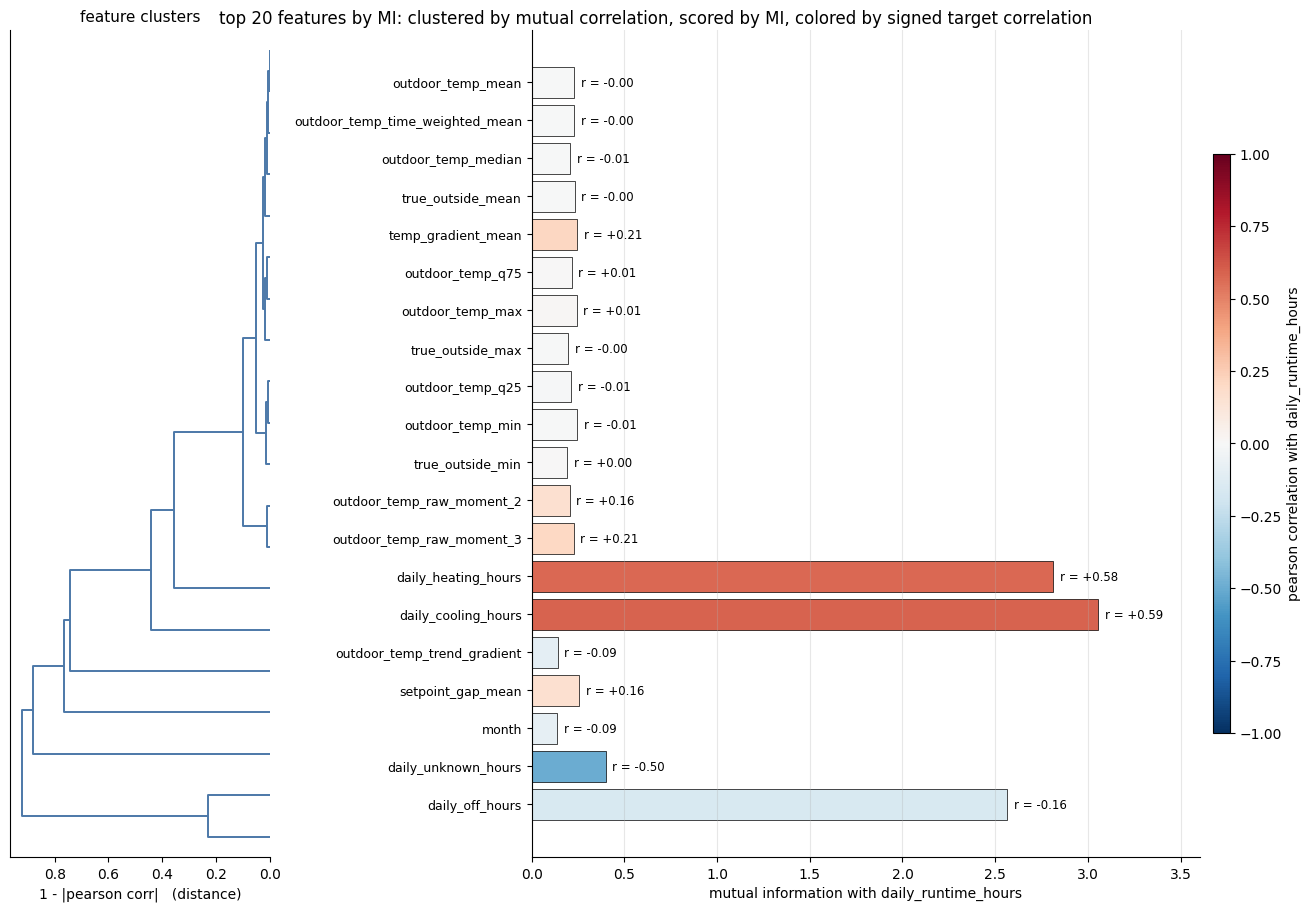

In [17]:
"""
==========================================================================
BLOCK 17: EDA 6 - FEATURE RANKING AND REDUNDANCY
==========================================================================
Replaces the previous correlation heatmap with a two-panel view that
answers two different questions on the same ordering:

  1. left  - hierarchical dendrogram of the top candidate features,
             built from 1 - |pearson correlation| so collinear
             clusters (e.g. outdoor temperature family, indoor
             temperature family) separate into visible sub-trees.
  2. right - horizontal bar chart of each feature's mutual
             information against daily_runtime_hours, in the same
             dendrogram leaf order, with the bar color encoding the
             SIGNED pearson correlation with the target.  a diverging
             red-to-blue colormap makes the sign readable at a
             glance, and the numeric r value is annotated at the end
             of each bar.

Reading the figure:
  - features that share a sub-tree on the left are mutually
    correlated and therefore partially redundant in the model.
  - the bar lengths on the right say which features carry
    information about runtime, and the bar colors say in which
    direction.
  - a long blue bar inside a small sub-tree is a strong signed
    predictor that is not duplicated by neighbors.  a short bar
    inside a tight sub-tree is a candidate for pruning.
==========================================================================
"""

from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
from scipy.spatial.distance import squareform

# number of top features to display
#
N_HEATMAP = 20

# collect numeric candidates, drop target and leakage columns
#
num_cols_eda = master_processed.select_dtypes(include=[np.number]).columns.tolist()
cand_eda = [c for c in num_cols_eda if c not in LEAKAGE_COLS]

# build the base frame keyed on a valid target value.  each
# candidate is then scored against the target using ONLY the rows
# where that individual candidate is finite (pairwise-complete),
# so structurally sparse features (e.g. 7-day outdoor gradient
# warmup, higher-order moments) are not penalised just because
# unrelated columns have NaN in the same rows.
#
eda_mi_frame = master_processed.dropna(subset=["daily_runtime_hours"]).copy()
avail_eda = [c for c in cand_eda if c in eda_mi_frame.columns]


def _pairwise_mi(frame, target, features, min_rows=200,
                 random_state=27, n_neighbors=5):
    """
    function: _pairwise_mi

    arguments:
      frame: dataframe holding target and feature columns
      target: name of the target column
      features: iterable of feature column names to score
      min_rows: minimum pairwise-complete rows required to score
        a feature; below this threshold MI is returned as NaN
      random_state: forwarded to mutual_info_regression
      n_neighbors: forwarded to mutual_info_regression

    return:
      dict mapping feature name to (mi_score, n_rows_used)

    description:
      computes mutual information feature-by-feature using only
      the rows where BOTH the feature and the target are finite.
      this avoids the biased subset that a joint dropna across
      all features would produce, while still letting the caller
      see how many rows backed each score.
    """
    out = {}
    y_full = frame[target]
    for feat in features:
        sub = frame[[feat, target]].dropna()
        if len(sub) < min_rows:
            out[feat] = (np.nan, len(sub))
            continue
        mi = mutual_info_regression(
            sub[[feat]], sub[target],
            random_state=random_state, n_neighbors=n_neighbors,
        )[0]
        out[feat] = (float(mi), len(sub))
    return out


# score each candidate with its pairwise-complete row subset
#
mi_pairs = _pairwise_mi(
    eda_mi_frame, "daily_runtime_hours", avail_eda,
)
preview_df = pd.DataFrame(
    [(f, mi, n) for f, (mi, n) in mi_pairs.items()],
    columns=["feature", "mi", "n_rows"],
).sort_values("mi", ascending=False, na_position="last").reset_index(drop=True)
top_feats = (
    preview_df.dropna(subset=["mi"]).head(N_HEATMAP)["feature"].tolist()
)
top_mi = dict(zip(preview_df["feature"], preview_df["mi"]))

# signed correlation matrix on top features plus the target
#
corr_signed = eda_mi_frame[top_feats + ["daily_runtime_hours"]].corr()

# hierarchical clustering on (1 - |corr|) distance of the FEATURES ONLY
# so the clustering is about feature redundancy, not target overlap.
#
feat_corr = corr_signed.loc[top_feats, top_feats].values
dist = 1.0 - np.abs(feat_corr)
np.fill_diagonal(dist, 0.0)
condensed = squareform(dist, checks=False)
Z = linkage(condensed, method="average")

# use dendrogram(no_plot=True) once to get the leaf order we want,
# then re-use it for both panels so they share a vertical axis
#
dendro_info = dendrogram(Z, labels=top_feats, no_plot=True,
                         color_threshold=0.0)
ordered_feats = dendro_info["ivl"]  # bottom-to-top visual order

# pull per-feature scores in that order
#
mi_vals = np.array([top_mi[f] for f in ordered_feats])
pearson_t = np.array(
    [corr_signed.loc[f, "daily_runtime_hours"] for f in ordered_feats]
)

# build the figure: dendrogram on the left, bar chart on the right,
# shared vertical axis so the dendrogram leaves line up with the bars
#
fig = plt.figure(figsize=(13, 9), constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[0.28, 0.72], wspace=0.02)
ax_d = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])

# horizontal dendrogram: leaves on the right edge of the left panel,
# root on the left edge.  a single color avoids implying cluster
# identity that the algorithm has not established.
#
with plt.rc_context({"lines.linewidth": 1.4}):
    dendrogram(
        Z,
        orientation="left",
        labels=top_feats,
        color_threshold=0.0,
        above_threshold_color="#4c78a8",
        ax=ax_d,
        no_labels=True,
    )
ax_d.set_xlabel("1 - |pearson corr|   (distance)")
ax_d.tick_params(axis="y", left=False, labelleft=False)
ax_d.spines["top"].set_visible(False)
ax_d.spines["right"].set_visible(False)
ax_d.set_title("feature clusters", fontsize=11)

# right panel: horizontal bars of mutual information, color = sign/
# strength of linear correlation with the target.
#
y_pos = np.arange(len(ordered_feats))
norm = plt.Normalize(vmin=-1.0, vmax=1.0)
cmap = plt.cm.RdBu_r
bar_colors = [cmap(norm(v)) for v in pearson_t]

ax_b.barh(y_pos, mi_vals, color=bar_colors,
          edgecolor="black", linewidth=0.5)
ax_b.set_yticks(y_pos)
ax_b.set_yticklabels(ordered_feats, fontsize=9)
# scipy's left-oriented dendrogram places dendro_info["ivl"][0] at
# the BOTTOM of the left panel, so y_pos growing upward already
# matches the dendrogram - no axis inversion needed
#
ax_b.set_xlabel("mutual information with daily_runtime_hours")
ax_b.grid(alpha=0.3, axis="x")
ax_b.spines["top"].set_visible(False)
ax_b.spines["right"].set_visible(False)

# annotate each bar with the signed pearson correlation value, placed
# just beyond the bar tip so long and short bars stay readable
#
x_max = float(np.nanmax(mi_vals)) if len(mi_vals) else 1.0
pad = x_max * 0.012
for i, (m, r) in enumerate(zip(mi_vals, pearson_t)):
    ax_b.text(m + pad, i, f"r = {r:+.2f}",
              va="center", ha="left", fontsize=8.5,
              color="black")
ax_b.set_xlim(0, x_max * 1.18)

# colorbar explaining the bar color encoding
#
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_b, orientation="vertical",
                    pad=0.02, aspect=35, shrink=0.7)
cbar.set_label("pearson correlation with daily_runtime_hours")

fig.suptitle(
    f"top {N_HEATMAP} features by MI: clustered by mutual correlation, "
    "scored by MI, colored by signed target correlation",
    y=0.995, fontsize=12,
)
plt.show()


In [18]:
"""
==========================================================================
BLOCK 18: TEMPORAL CLUSTERING OF EQUIPMENT BY RUNTIME CURVES
==========================================================================
Clusters equipment by their daily runtime time series using tslearn
TimeSeriesKMeans with a dynamic time warping metric. The resulting
cluster label is attached to master_processed so it propagates through
lag generation (Block 22) into master_local_lags for cluster-based
modeling in Block 26.
==========================================================================
"""

try:
    from tslearn.clustering import TimeSeriesKMeans
    from tslearn.preprocessing import TimeSeriesScalerMeanVariance
    TSLEARN_AVAILABLE = True
except ImportError:
    TSLEARN_AVAILABLE = False
    print("tslearn not installed. install with: pip install tslearn")
    print("skipping temporal clustering.")

if TSLEARN_AVAILABLE:

    # define the number of clusters
    #
    N_CLUSTERS = 3

    # pivot daily runtime into a (equipment x date) matrix on the
    # reconstructed frame; lag columns are not needed here
    #
    pivot_df = master_processed.pivot_table(
        index="Equipment_ID", columns="Date",
        values="daily_runtime_hours", aggfunc="first",
    )

    # fill missing days with each EQUIPMENT'S OWN MEAN runtime
    # rather than a global zero.  after TimeSeriesScalerMeanVariance
    # each house is centered at its own mean, so a mean-filled
    # reporting gap scales to ~0 and contributes no pseudo-signal.
    # a global zero-fill, by contrast, injected a shared "idle"
    # pattern that pulled every house with big gaps into the same
    # DTW cluster regardless of thermal behavior.  houses that
    # never reported at all fall back to the overall mean so the
    # clustering input never contains NaN.
    #
    row_means = pivot_df.mean(axis=1)
    overall_mean = float(pivot_df.stack().mean())
    row_means = row_means.fillna(overall_mean)
    pivot_filled = pivot_df.apply(
        lambda r: r.fillna(row_means.loc[r.name]), axis=1
    ).values

    # reshape for tslearn (n_samples, n_timestamps, n_features)
    #
    ts_data = pivot_filled.reshape(pivot_filled.shape[0], pivot_filled.shape[1], 1)

    # scale each series to zero mean / unit variance
    #
    scaler_ts = TimeSeriesScalerMeanVariance()
    ts_scaled = scaler_ts.fit_transform(ts_data)

    # replace any nans introduced by constant series
    #
    ts_scaled = np.nan_to_num(ts_scaled, nan=0.0)

    # fit k-means with dtw metric
    #
    km = TimeSeriesKMeans(
        n_clusters=N_CLUSTERS,
        metric="dtw",
        max_iter=30,
        random_state=27,
        verbose=0,
    )
    cluster_labels = km.fit_predict(ts_scaled)

    # map cluster labels back to equipment ids
    #
    cluster_map = dict(zip(pivot_df.index, cluster_labels))

    # attach cluster assignment to master_processed so the lag concat in
    # block 22 carries it through into master_local_lags
    #
    master_processed["cluster"] = master_processed["Equipment_ID"].map(cluster_map)

    # store the scaled series and the fitted model for blocks 19 and 20
    #
    cluster_pivot = pivot_df
    cluster_ts_scaled = ts_scaled
    cluster_km = km

    # report cluster sizes
    #
    print(f"\ntemporal clustering ({N_CLUSTERS} clusters, dtw metric):")
    for c_id in range(N_CLUSTERS):
        n_houses = sum(1 for v in cluster_map.values() if v == c_id)
        print(f"  cluster {c_id}: {n_houses} households")


tslearn not installed. install with: pip install tslearn
skipping temporal clustering.


In [19]:
"""
==========================================================================
BLOCK 19: CLUSTER CHARACTERIZATION
==========================================================================
Plots the dtw centroid of each cluster, the mean runtime by month per
cluster, and prints the equipment membership summary. This is the
qualitative counterpart to Block 20's quantitative diagnostics.
==========================================================================
"""

if TSLEARN_AVAILABLE:

    # ---------------------------------------------------------------------
    #
    # figure 1: cluster centroids (scaled runtime vs time)
    #
    # ---------------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(11, 4.5))
    colors = ["#4c78a8", "#e45756", "#54a24b", "#f58518", "#b279a2"]
    for c_id in range(N_CLUSTERS):
        centroid = cluster_km.cluster_centers_[c_id].ravel()
        ax.plot(centroid, color=colors[c_id % len(colors)],
                linewidth=1.2, label=f"cluster {c_id}")
    ax.set_title("dtw cluster centroids (scaled runtime)")
    ax.set_xlabel("day index (calendar-aligned)")
    ax.set_ylabel("scaled daily_runtime_hours")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------------------
    #
    # figure 2: mean runtime by month, per cluster
    #
    # ---------------------------------------------------------------------

    tmp = master_processed.dropna(subset=["daily_runtime_hours", "cluster"]).copy()
    tmp["_month"] = tmp["Date"].dt.month
    monthly = tmp.groupby(["cluster", "_month"])["daily_runtime_hours"].mean().unstack("cluster")

    fig, ax = plt.subplots(figsize=(10, 4.5))
    for c_id in monthly.columns:
        ax.plot(monthly.index, monthly[c_id], marker="o",
                color=colors[int(c_id) % len(colors)],
                label=f"cluster {int(c_id)}")
    ax.set_title("mean daily runtime by month, per cluster")
    ax.set_xlabel("month")
    ax.set_ylabel("mean runtime (hours)")
    ax.set_xticks(range(1, 13))
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------------------
    #
    # cluster membership summary
    #
    # ---------------------------------------------------------------------

    print("\ncluster membership summary:")
    for c_id in range(N_CLUSTERS):
        members = [eq for eq, lab in cluster_map.items() if lab == c_id]
        sample = ", ".join(members[:5])
        extra = f" (+{len(members) - 5} more)" if len(members) > 5 else ""
        print(f"  cluster {c_id} ({len(members)} equipment): {sample}{extra}")


In [20]:
"""
==========================================================================
BLOCK 20: CLUSTER DIAGNOSTICS
==========================================================================
Quantitative diagnostics for the temporal clustering: silhouette score
at the chosen N_CLUSTERS and an inertia-vs-k sweep over a small range.
Intended as a sanity check on the cluster count choice rather than a
full grid search.
==========================================================================
"""

if TSLEARN_AVAILABLE:

    # ---------------------------------------------------------------------
    #
    # silhouette score at the chosen cluster count (euclidean on flattened series)
    #
    # ---------------------------------------------------------------------

    # flatten each scaled series into a vector for silhouette scoring;
    # silhouette does not accept dtw, so we use a euclidean proxy here
    #
    flat = cluster_ts_scaled.reshape(cluster_ts_scaled.shape[0], -1)
    if len(set(cluster_km.labels_)) > 1:
        sil = silhouette_score(flat, cluster_km.labels_)
        print(f"silhouette (euclidean proxy) at k={N_CLUSTERS}: {sil:.4f}")
    else:
        print(f"silhouette not defined: only one cluster assigned")

    # ---------------------------------------------------------------------
    #
    # small inertia-vs-k sweep (k = 2..5)
    #
    # ---------------------------------------------------------------------

    k_range = list(range(2, 6))
    inertias = []
    for k in k_range:
        km_k = TimeSeriesKMeans(
            n_clusters=k, metric="dtw", max_iter=20,
            random_state=27, verbose=0,
        )
        km_k.fit(cluster_ts_scaled)
        inertias.append(km_k.inertia_)
        print(f"  k={k}: inertia={km_k.inertia_:.3f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(k_range, inertias, marker="o", color="#4c78a8")
    ax.axvline(N_CLUSTERS, color="#e45756", linestyle="--",
               label=f"chosen k={N_CLUSTERS}")
    ax.set_title("dtw k-means inertia vs k")
    ax.set_xlabel("number of clusters")
    ax.set_ylabel("inertia")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [21]:
"""
==========================================================================
BLOCK 21: FEATURE SELECTION ON BASE (NON-LAGGED) FEATURES
==========================================================================
Runs pearson correlation, mutual information, and rfe against the
target on the reconstructed master frame. The mi ranking is used to
pick the top N features. The selected set is then split into
lag-worthy (evolving state that benefits from historical context) and
same-day-only (calendar, weather extremes, gradient) groups.
==========================================================================
"""

# number of top features to keep based on mutual information
#
N_TOP_FEATURES = 25

# features that should NOT be lagged because they describe today only,
# are static calendar encodings, or already encode multi-day history
#
SAME_DAY_ONLY = {
    "day_of_week", "is_weekend",
    "month", "month_sin", "month_cos",
    "true_outside_min", "true_outside_max",
    "true_outside_mean", "true_humidity_mean",
    "outdoor_temp_trend_gradient",
    "setpoint_change_count",
    "occupied_ping_count", "unoccupied_ping_count",
}

# identify all numeric columns as candidate base features
#
num_cols = master_processed.select_dtypes(include=[np.number]).columns.tolist()

# exclude target and leakage columns from the candidate set
#
candidate_feats = [c for c in num_cols if c not in LEAKAGE_COLS]

# prepare the scoring dataset.  we only require a valid target
# here; candidate features may still have NaN values, which are
# handled downstream via pairwise-complete scoring and a NaN-
# tolerant RFE estimator.  doing a joint dropna across every
# candidate (the old behavior) collapsed the frame to a biased
# all-feature-complete slice that systematically penalised
# structurally sparse columns (higher-order moments, multi-day
# warmup signals).
#
score_df = master_processed.dropna(subset=["daily_runtime_hours"]).copy()
avail_feats = [f for f in candidate_feats if f in score_df.columns]

# extract the feature matrix and target.  X_score keeps NaN in place
# for pairwise-complete scoring; X_rfe below is a median-imputed
# copy used only by sklearn RFE, which does not tolerate NaN.
#
X_score = score_df[avail_feats]
y_score = score_df["daily_runtime_hours"]

# ---------------------------------------------------------------------------
#
# pearson correlation (pandas corrwith handles per-column NaN via
# pairwise deletion, so no joint dropna is needed here)
#
# ---------------------------------------------------------------------------

pearson_corr = X_score.corrwith(y_score).abs()
pearson_df = pd.DataFrame({
    "feature": pearson_corr.index,
    "pearson_abs": pearson_corr.values,
}).sort_values("pearson_abs", ascending=False).reset_index(drop=True)

# display the top 30 features by pearson correlation
#
print("top 30 features by |pearson correlation| with daily_runtime_hours:")
print(pearson_df.head(30).to_string(index=False))

# ---------------------------------------------------------------------------
#
# mutual information scoring (pairwise-complete rows per feature)
#
# ---------------------------------------------------------------------------


def _pairwise_mi_scores(frame, target, features, min_rows=200,
                        random_state=27, n_neighbors=5):
    """
    function: _pairwise_mi_scores

    arguments:
      frame: dataframe holding the target and candidate features
      target: name of the target column
      features: iterable of feature column names
      min_rows: minimum pairwise-complete rows to score a feature
      random_state: forwarded to mutual_info_regression
      n_neighbors: forwarded to mutual_info_regression

    return:
      dataframe with columns (feature, mi_score, n_rows), sorted
      by mi_score descending with NaN scores last

    description:
      scores each feature against the target using the subset of
      rows where that specific feature and the target are both
      finite.  avoids the all-feature-complete bias that the
      previous joint dropna introduced.
    """
    rows = []
    for feat in features:
        sub = frame[[feat, target]].dropna()
        if len(sub) < min_rows:
            rows.append((feat, np.nan, len(sub)))
            continue
        mi = mutual_info_regression(
            sub[[feat]], sub[target],
            random_state=random_state, n_neighbors=n_neighbors,
        )[0]
        rows.append((feat, float(mi), len(sub)))
    out = pd.DataFrame(rows, columns=["feature", "mi_score", "n_rows"])
    return out.sort_values(
        "mi_score", ascending=False, na_position="last",
    ).reset_index(drop=True)


mi_df = _pairwise_mi_scores(score_df, "daily_runtime_hours", avail_feats)

# display the top 30 features by mutual information
#
print("\ntop 30 features by mutual information with daily_runtime_hours:")
print(mi_df.head(30).to_string(index=False))

# ---------------------------------------------------------------------------
#
# recursive feature elimination (rfe) using an LGBM estimator so
# NaN values are handled natively.  sklearn's RFE still requires a
# rectangular non-NaN matrix, so X_rfe is median-imputed just for
# this call; the median is a conservative neutral value that does
# not invent extreme inputs for the splitter.
#
# ---------------------------------------------------------------------------

X_rfe = X_score.fillna(X_score.median(numeric_only=True))
lgb_rfe = LGBMRegressor(
    n_estimators=100, max_depth=5, num_leaves=15,
    min_child_samples=20, random_state=27, n_jobs=1, verbose=-1,
)

# run rfe to rank all features
#
rfe = RFE(estimator=lgb_rfe, n_features_to_select=1, step=5)
rfe.fit(X_rfe, y_score)

# create a ranked dataframe
#
rfe_df = pd.DataFrame({
    "feature": avail_feats,
    "rfe_rank": rfe.ranking_,
}).sort_values("rfe_rank").reset_index(drop=True)

# display the top 30 features by rfe rank
#
print("\ntop 30 features by rfe rank:")
print(rfe_df.head(30).to_string(index=False))

# ---------------------------------------------------------------------------
#
# select the top N features based on mutual information
#
# ---------------------------------------------------------------------------

# take the top N features by mi score
#
selected_feats = mi_df.head(N_TOP_FEATURES)["feature"].tolist()

# always include daily_runtime_hours for target lag generation
#
if "daily_runtime_hours" not in selected_feats:
    selected_feats.append("daily_runtime_hours")

# split selected features into lag-worthy and same-day-only
#
lag_worthy_feats = [f for f in selected_feats if f not in SAME_DAY_ONLY]
same_day_feats = [f for f in selected_feats if f in SAME_DAY_ONLY]

# report selection
#
print(f"\nselected {len(selected_feats)} base features by mutual information:")
print(f"  lag-worthy ({len(lag_worthy_feats)}): features that get lag_1..lag_{LAG_DAYS}")
for feat in lag_worthy_feats:
    mi_match = mi_df.loc[mi_df["feature"] == feat, "mi_score"].values
    mi_str = f"mi={mi_match[0]:.4f}" if len(mi_match) > 0 else "target (forced)"
    print(f"    {feat}: {mi_str}")
print(f"  same-day only ({len(same_day_feats)}): no lags generated")
for feat in same_day_feats:
    mi_match = mi_df.loc[mi_df["feature"] == feat, "mi_score"].values
    mi_str = f"mi={mi_match[0]:.4f}" if len(mi_match) > 0 else "target (forced)"
    print(f"    {feat}: {mi_str}")


top 30 features by |pearson correlation| with daily_runtime_hours:
                    feature  pearson_abs
        daily_cooling_hours     0.589843
        daily_heating_hours     0.576700
        daily_unknown_hours     0.495676
         temp_gradient_mean     0.212683
  outdoor_temp_raw_moment_3     0.207218
            daily_off_hours     0.162502
  outdoor_temp_raw_moment_2     0.162348
          setpoint_gap_mean     0.159617
          indoor_temp_range     0.117985
            indoor_temp_min     0.107584
outdoor_temp_trend_gradient     0.094864
                      month     0.091469
          outdoor_hum_range     0.090710
            outdoor_hum_iqr     0.089351
       indoor_temp_variance     0.083857
            indoor_temp_std     0.077609
       indoor_temp_skewness     0.073464
outdoor_hum_kurtosis_excess     0.073284
            indoor_temp_iqr     0.067251
             setpoint_range     0.066535
               setpoint_iqr     0.063788
               setpoint_std    

In [22]:
"""
==========================================================================
BLOCK 22: LAG GENERATION ON LAG-WORTHY FEATURES
==========================================================================
Generates lag_1 through lag_7 only for features that capture evolving
state (runtime, temperatures, comfort gaps, etc). Same-day features
(calendar, weather extremes, gradient) are included as-is without lags.
==========================================================================
"""

# filter lag-worthy features to those present in the dataframe
#
lag_cols_for_shift = [c for c in lag_worthy_feats if c in master_processed.columns]

# generate lags 1..LAG_DAYS for lag-worthy features only
#
lags = []
for i in range(1, LAG_DAYS + 1):

    # shift lag-worthy columns by i days within each equipment group
    #
    s = master_processed.groupby("Equipment_ID")[lag_cols_for_shift].shift(i)

    # rename columns with lag suffix
    #
    s.columns = [f"{c}_lag_{i}" for c in s.columns]

    # append to lag list
    #
    lags.append(s)

# concatenate original data with lag features
#
master_local_lags = pd.concat([master_processed] + lags, axis=1)

# defragment the BlockManager; the concat above leaves many small blocks,
# and subsequent per-column assignments (here and in later blocks) would
# otherwise trip pandas' PerformanceWarning on highly fragmented frames
#
master_local_lags = master_local_lags.copy()

# cast equipment id to categorical for model routing
#
master_local_lags["Equipment_ID"] = master_local_lags["Equipment_ID"].astype("category")

# define the lag feature set
#
lag_feats = [c for c in master_local_lags.columns if "_lag_" in c]

# define same-day features (no lags, used as-is)
#
day_only_feats = [c for c in same_day_feats if c != "daily_runtime_hours"]

# compile the final feature set: same-day exogenous + lag features only.
# current-day endogenous features (indoor temp, fan hours, setpoint gap,
# etc.) are excluded because they are concurrent outcomes of hvac
# operation that would not be available at prediction time.
#
final_feature_set = day_only_feats + lag_feats

# report feature counts
#
print(f"\nfinal feature set: {len(final_feature_set)} total")
print(f"  same-day exogenous features: {len(day_only_feats)}")
print(f"  lag features: {len(lag_feats)}")



final feature set: 146 total
  same-day exogenous features: 6
  lag features: 140


In [23]:
"""
==========================================================================
BLOCK 23: STRATIFIED BLOCKED TIME SERIES SPLIT (train / val / test)
==========================================================================
Divides the calendar into 14-day contiguous blocks and assigns each
block to a meteorological season.  Within each season the blocks are
chronologically sorted and the LAST ~20% are held out as test.  The
blocks immediately preceding test are held out as val; val is used by
downstream models (Blocks 25, 27, 28) as the early-stopping eval_set
so the test set is never consulted during training or model selection.
Blocks that do not use early stopping (Blocks 24, 26) pool train + val
for fitting since no holdout is required.

A final tail-guard extends the last block to date_max so every
reporting day is assigned a split value (the old date_range stride
could drop up to BLOCK_SIZE_DAYS - 1 trailing days, which silently
remained at the default "train" assignment).
==========================================================================
"""

# define block size in days
#
BLOCK_SIZE_DAYS = 14

# fraction of each season's blocks reserved for test (the latest ones)
#
TEST_FRACTION = 0.20

# fraction of each season's NON-TEST blocks reserved for val (the
# latest ones before test).  val is only materialized when at least two
# non-test blocks remain in the season so every season keeps at least
# one train block.
#
VAL_FRACTION = 0.15


def month_to_season(m):
    """
    function: month_to_season

    arguments:
      m: integer month (1-12)

    return:
      string season name

    description:
      maps a calendar month to its meteorological season.
    """

    # winter: december, january, february
    #
    if m in {12, 1, 2}:
        return "winter"

    # spring: march, april, may
    #
    if m in {3, 4, 5}:
        return "spring"

    # summer: june, july, august
    #
    if m in {6, 7, 8}:
        return "summer"

    # fall: september, october, november
    #
    return "fall"


# determine the global date range across all households
#
all_dates = master_local_lags["Date"].dropna()
date_min = all_dates.min().normalize()
date_max = all_dates.max().normalize()

# create contiguous 14-day blocks spanning the full range, then extend
# the last block to date_max so trailing days the stride would skip
# still receive a split assignment
#
block_starts = pd.date_range(
    start=date_min, end=date_max, freq=f"{BLOCK_SIZE_DAYS}D"
)
blocks = []
for i, bs in enumerate(block_starts):

    # compute block end and midpoint
    #
    be = bs + pd.Timedelta(days=BLOCK_SIZE_DAYS - 1)

    # extend the last block forward so any tail days past the stride
    # are included in the assignment
    #
    if i == len(block_starts) - 1 and be < date_max:
        be = date_max

    mid = bs + (be - bs) / 2

    # assign season based on the midpoint month
    #
    blocks.append({
        "block_id": i,
        "start": bs,
        "end": be,
        "season": month_to_season(mid.month),
    })

# convert to dataframe
#
block_df = pd.DataFrame(blocks)

# within each season, assign the last TEST_FRACTION blocks to test,
# then the immediately preceding VAL_FRACTION of remaining blocks to
# val.  val is skipped entirely for a season with fewer than 2
# non-test blocks so train never becomes empty.
#
block_df["split"] = "train"
for season in block_df["season"].unique():

    # isolate blocks for this season in chronological order
    #
    season_idx = (
        block_df[block_df["season"] == season]
        .sort_values("block_id")
        .index
    )
    n_season = len(season_idx)
    n_test = max(1, int(np.ceil(n_season * TEST_FRACTION)))
    n_remain = n_season - n_test

    # reserve val only when at least one train block will remain
    #
    if n_remain >= 2:
        n_val = max(1, int(np.ceil(n_remain * VAL_FRACTION)))
    else:
        n_val = 0

    # assign the latest blocks to test
    #
    block_df.loc[season_idx[-n_test:], "split"] = "test"

    # assign the blocks immediately before test to val
    #
    if n_val > 0:
        val_slice = season_idx[-(n_test + n_val):-n_test]
        block_df.loc[val_slice, "split"] = "val"

# map each day in the master dataframe to its block split assignment
#
master_local_lags["split"] = "train"
for _, blk in block_df.iterrows():

    # find rows within this block date range
    #
    day_mask = (
        (master_local_lags["Date"] >= blk["start"]) &
        (master_local_lags["Date"] <= blk["end"])
    )

    # assign the block split value
    #
    master_local_lags.loc[day_mask, "split"] = blk["split"]

# create boolean masks for model training
#
train_mask = master_local_lags["split"] == "train"
val_mask = master_local_lags["split"] == "val"
test_mask = master_local_lags["split"] == "test"

# report split statistics
#
print(f"\nstratified blocked split ({BLOCK_SIZE_DAYS}-day blocks):")
print(f"  total blocks: {len(block_df)}")
for season in ["winter", "spring", "summer", "fall"]:
    s_blk = block_df[block_df["season"] == season]
    n_tr = (s_blk["split"] == "train").sum()
    n_va = (s_blk["split"] == "val").sum()
    n_te = (s_blk["split"] == "test").sum()
    print(f"  {season}: {n_tr} train, {n_va} val, {n_te} test")
print(
    f"  train rows: {train_mask.sum()}, "
    f"val rows: {val_mask.sum()}, "
    f"test rows: {test_mask.sum()}"
)



stratified blocked split (14-day blocks):
  total blocks: 53
  winter: 7 train, 2 val, 3 test
  spring: 10 train, 2 val, 3 test
  summer: 7 train, 2 val, 3 test
  fall: 9 train, 2 val, 3 test
  train rows: 15771, val rows: 10688, test rows: 15333


In [24]:
"""
==========================================================================
BLOCK 24: PER-HOUSE MODELS
==========================================================================
Trains one LightGBM model per household using the stratified blocked
split from Block 23.  Pools predictions across all houses for reporting.
Defines report_model_metrics, a shared helper reused by every
subsequent tree-model block to emit overall pooled, overall averaged,
per-season pooled, and per-season averaged metric groups.

NOTE on per-season averaged metrics: the prior version filtered per-
equipment slices on `len(g) < n_features + 2`, which ejected nearly
every house because a single season of test data contains ~15-25 rows
while the feature set exceeds 80 columns.  That made every
"per-season averaged" row collapse to NaN for every model.  The
threshold is now MIN_ROWS_FOR_METRIC (small constant), and houses
that fall below it or produce a non-finite metric are listed by id
so the caller can see exactly which units are driving any NaNs.
==========================================================================
"""

from sklearn.metrics import root_mean_squared_error

# minimum per-equipment rows required to contribute a metric tuple
# to the "averaged across equipments" aggregates.  5 is a reasonable
# floor: RMSE/MAE stabilize quickly, and r2 becomes numerically
# meaningful once var(y_true) is non-trivial.  adj_r2 is always NaN-
# safe inside _metrics for n <= p + 1.
#
MIN_ROWS_FOR_METRIC = 5


def _safe_col_mean(rows_2d):
    """
    function: _safe_col_mean

    arguments:
      rows_2d: sequence of tuples/lists all of the same length,
        or a 2-d numpy array

    return:
      numpy array of column means; any column that is all-NaN
      becomes np.nan with no RuntimeWarning

    description:
      np.nanmean(arr, axis=0) emits "RuntimeWarning: Mean of empty
      slice" once per all-NaN column, which is the case for the
      adj_r2 column of per-season per-house metric tuples because
      n_per_house_per_season (~20-40 rows) is always below
      n_features + 1 and therefore adj_r2 is NaN for every house.
      this helper returns the same numeric result without the
      noise by masking NaNs per column explicitly.
    """
    arr = np.asarray(rows_2d, dtype=float)
    if arr.size == 0:
        return np.array([])
    if arr.ndim == 1:
        finite = arr[np.isfinite(arr)]
        return np.array([finite.mean()]) if len(finite) else np.array([np.nan])
    out = np.empty(arr.shape[1])
    for j in range(arr.shape[1]):
        col = arr[:, j]
        finite = col[np.isfinite(col)]
        out[j] = float(finite.mean()) if len(finite) else np.nan
    return out

def report_model_metrics(eval_df, n_features, model_name,
                         min_rows=MIN_ROWS_FOR_METRIC, verbose_excluded=True):
    """
    function: report_model_metrics

    arguments:
      eval_df: dataframe with columns Equipment_ID, Date, y_true, y_pred
      n_features: number of model features (for adjusted r-squared)
      model_name: label printed at the top of the report
      min_rows: minimum per-equipment rows required to contribute to
        the averaged metric groups.  see MIN_ROWS_FOR_METRIC note above.
      verbose_excluded: when true, prints the equipment ids that were
        excluded from each averaged aggregate and why.

    return:
      dict with keys
        "pooled", "averaged", "season_pooled", "season_averaged",
        and "excluded" (nested diagnostic map of which equipment
        contributed, were too sparse, or produced non-finite metrics).

    description:
      prints four metric groups: overall pooled across every test row,
      overall averaged across per-equipment metrics, per-season pooled,
      and per-season averaged across per-equipment metrics.  each
      group emits rmse, mae, r-squared, and adjusted r-squared.
      per-equipment inclusion/exclusion diagnostics are printed so a
      NaN in any group can be traced back to specific equipment ids.
    """

    # inner helper: compute the four core metrics on one subset
    #
    def _metrics(y_true, y_pred, p):
        n = len(y_true)
        if n < 2:
            return np.nan, np.nan, np.nan, np.nan
        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)
        rmse = root_mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        # r2_score returns 0.0 when var(y_true) = 0 and residuals are
        # also zero, and a large negative number otherwise.  guard so
        # a degenerate constant-target slice does not silently poison
        # the nanmean over equipment.
        #
        if np.nanstd(y_true) < 1e-12:
            r2 = np.nan
        else:
            r2 = r2_score(y_true, y_pred)
        denom = n - p - 1
        if denom > 0 and not np.isnan(r2):
            adj_r2 = 1 - (1 - r2) * (n - 1) / denom
        else:
            adj_r2 = np.nan
        return rmse, mae, r2, adj_r2

    # diagnostic container: tracks what contributed to each aggregate
    #
    excluded = {
        "averaged_too_few_rows": [],
        "averaged_non_finite": [],
        "season_too_few_rows": {s: [] for s in ["winter", "spring",
                                                 "summer", "fall"]},
        "season_non_finite": {s: [] for s in ["winter", "spring",
                                              "summer", "fall"]},
        "season_absent": {s: [] for s in ["winter", "spring",
                                          "summer", "fall"]},
    }

    # overall pooled across every test row
    #
    y_true_all = eval_df["y_true"].values
    y_pred_all = eval_df["y_pred"].values
    pooled = _metrics(y_true_all, y_pred_all, n_features)

    # overall averaged across per-equipment metrics
    #
    eq_rows = []
    for eq_id, g in eval_df.groupby("Equipment_ID", observed=True):
        if len(g) < min_rows:
            excluded["averaged_too_few_rows"].append((str(eq_id), int(len(g))))
            continue
        m = _metrics(g["y_true"].values, g["y_pred"].values, n_features)
        # rmse and mae are always finite when n >= 2; r2 / adj_r2 can
        # be NaN for constant-target slices.  we use RMSE/MAE/r2 as the
        # finiteness criterion for inclusion in the mean.
        #
        if not (np.isfinite(m[0]) and np.isfinite(m[1])):
            excluded["averaged_non_finite"].append(str(eq_id))
            continue
        eq_rows.append(m)
    if eq_rows:
        averaged = tuple(_safe_col_mean(eq_rows))
    else:
        averaged = (np.nan,) * 4

    # assign a season label to each row using the block 23 helper
    #
    tmp = eval_df.copy()
    tmp["_season"] = pd.to_datetime(tmp["Date"]).dt.month.map(month_to_season)

    # compute per-season pooled and per-season averaged metrics
    #
    season_pooled = {}
    season_averaged = {}
    for season in ["winter", "spring", "summer", "fall"]:
        sdf = tmp[tmp["_season"] == season]
        if len(sdf) >= 2:
            season_pooled[season] = _metrics(
                sdf["y_true"].values, sdf["y_pred"].values, n_features,
            )
        else:
            season_pooled[season] = (np.nan,) * 4

        rows = []
        # any equipment id present in the overall eval frame but
        # absent from this season's slice is recorded separately so
        # the diagnostic output can tell "absent" apart from
        # "present-but-too-sparse"
        #
        season_eq_set = set(sdf["Equipment_ID"].unique().tolist())
        all_eq_set = set(eval_df["Equipment_ID"].unique().tolist())
        for eq_id in (all_eq_set - season_eq_set):
            excluded["season_absent"][season].append(str(eq_id))

        for eq_id, g in sdf.groupby("Equipment_ID", observed=True):
            if len(g) < min_rows:
                excluded["season_too_few_rows"][season].append(
                    (str(eq_id), int(len(g)))
                )
                continue
            m = _metrics(g["y_true"].values, g["y_pred"].values, n_features)
            if not (np.isfinite(m[0]) and np.isfinite(m[1])):
                excluded["season_non_finite"][season].append(str(eq_id))
                continue
            rows.append(m)
        season_averaged[season] = (tuple(_safe_col_mean(rows))
                                   if rows else (np.nan,) * 4)

    # print the report
    #
    def _fmt(t):
        return (f"rmse={t[0]:.4f}  mae={t[1]:.4f}  "
                f"r2={t[2]:.4f}  adj_r2={t[3]:.4f}")

    print(f"\n=== {model_name} ===")
    print(f"overall pooled:   {_fmt(pooled)}")
    print(f"overall averaged: {_fmt(averaged)}   "
          f"(contributing houses: {len(eq_rows)})")
    print("per-season pooled:")
    for s in ["winter", "spring", "summer", "fall"]:
        print(f"  {s:6s}: {_fmt(season_pooled[s])}")
    print("per-season averaged:")
    for s in ["winter", "spring", "summer", "fall"]:
        n_contrib = (len(tmp[tmp["_season"] == s]
                         .groupby("Equipment_ID", observed=True))
                     - len(excluded["season_too_few_rows"][s])
                     - len(excluded["season_non_finite"][s]))
        print(f"  {s:6s}: {_fmt(season_averaged[s])}   "
              f"(contributing houses: {max(n_contrib, 0)})")

    # print diagnostic lists so any NaN or low count can be tied
    # back to specific equipment ids.  kept short by truncating long
    # lists to their first N entries.
    #
    if verbose_excluded:
        def _short(xs, k=10):
            if not xs:
                return "none"
            xs = list(xs)
            tail = f", ... (+{len(xs) - k} more)" if len(xs) > k else ""
            return ", ".join(str(x) for x in xs[:k]) + tail

        print("\n-- averaged-group diagnostics --")
        print(f"  excluded (rows < {min_rows}): "
              f"{_short(excluded['averaged_too_few_rows'])}")
        print(f"  excluded (non-finite metric): "
              f"{_short(excluded['averaged_non_finite'])}")

        print("-- per-season averaged diagnostics --")
        for s in ["winter", "spring", "summer", "fall"]:
            print(f"  [{s}]")
            print(f"    absent from season      : "
                  f"{_short(excluded['season_absent'][s])}")
            print(f"    excluded rows<{min_rows}        : "
                  f"{_short(excluded['season_too_few_rows'][s])}")
            print(f"    excluded non-finite     : "
                  f"{_short(excluded['season_non_finite'][s])}")

    return {
        "pooled": pooled,
        "averaged": averaged,
        "season_pooled": season_pooled,
        "season_averaged": season_averaged,
        "excluded": excluded,
    }


def print_lgbm_feature_importance(model, feature_names, title):
    """
    function: print_lgbm_feature_importance

    arguments:
      model: fitted LGBMRegressor
      feature_names: iterable of feature names matching training order
      title: label printed at the top of the ranking

    return:
      None

    description:
      prints the full list of features ranked by gain descending. used
      by every tree block to replace any prior top-k style reporting.
    """
    gains = model.booster_.feature_importance(importance_type="gain")
    fi = pd.DataFrame({"feature": list(feature_names), "gain": gains})
    fi = fi.sort_values("gain", ascending=False).reset_index(drop=True)
    print(f"\n{title} (full feature importance by gain):")
    print(fi.to_string(index=False))


# define per-house model parameters
#
local_params = {
    'n_estimators': 300,
    'learning_rate': 0.05,
    'num_leaves': 15,
    'max_depth': 5,
    'min_child_samples': 10,
    'random_state': 27,
    'n_jobs': -1,
    'verbose': -1,
}

# initialize pooled tracking arrays
#
pooled_y_true = []
pooled_y_pred = []
pooled_eq = []
pooled_date = []
successful_models = 0
flagged_houses = []

# accumulate per-house gain so we can rank features once at the end
#
per_feature_gain_sum = np.zeros(len(final_feature_set), dtype=float)
per_feature_gain_count = 0

# iterate over each equipment id
#
for house_id in master_local_lags["Equipment_ID"].unique():

    # filter to this house
    #
    house_df = master_local_lags[
        master_local_lags["Equipment_ID"] == house_id
    ].copy()
    house_df = house_df.dropna(subset=["daily_runtime_hours"])

    # apply the stratified blocked split.  per-house models do
    # not use early stopping, so train pools rows labeled "train"
    # and "val" from block 23.  the "val" label is only meaningful
    # for blocks that need an early-stopping eval_set.
    #
    h_train = house_df[house_df["split"].isin({"train", "val"})]
    h_test = house_df[house_df["split"] == "test"]

    # skip houses with insufficient train or test data
    #
    if len(h_train) < 40 or len(h_test) < 10:
        continue

    # split features and target
    #
    X_train_local = h_train[final_feature_set]
    y_train_local = h_train["daily_runtime_hours"]
    X_test_local = h_test[final_feature_set]
    y_test_local = h_test["daily_runtime_hours"]

    # train the per-house model
    #
    local_model = LGBMRegressor(**local_params)
    try:
        local_model.fit(X_train_local, y_train_local)
    except Exception as e:
        flagged_houses.append((house_id, str(e)))
        continue

    # predict on the test slice and accumulate pooled predictions
    #
    preds_local = local_model.predict(X_test_local)
    pooled_y_true.extend(y_test_local.values.tolist())
    pooled_y_pred.extend(preds_local.tolist())
    pooled_eq.extend([house_id] * len(preds_local))
    pooled_date.extend(h_test["Date"].tolist())
    successful_models += 1

    # accumulate feature gain from this house's booster
    #
    per_feature_gain_sum += local_model.booster_.feature_importance(
        importance_type="gain"
    )
    per_feature_gain_count += 1

# report training summary
#
print(f"\nper-house models trained: {successful_models}")
if flagged_houses:
    print(f"flagged houses (skipped): {len(flagged_houses)}")
    for hid, err in flagged_houses:
        print(f"  {hid}: {err}")

# build the evaluation frame and report metrics via the shared helper
#
eval_local = pd.DataFrame({
    "Equipment_ID": pooled_eq,
    "Date": pooled_date,
    "y_true": pooled_y_true,
    "y_pred": pooled_y_pred,
})
local_metrics = report_model_metrics(
    eval_local, n_features=len(final_feature_set),
    model_name="BLOCK 24: per-house LightGBM (pooled predictions)",
)

# print the pooled-gain feature importance ranking (mean gain per feature)
#
if per_feature_gain_count > 0:
    mean_gains = per_feature_gain_sum / per_feature_gain_count
    fi_local = pd.DataFrame({
        "feature": final_feature_set, "mean_gain": mean_gains,
    }).sort_values("mean_gain", ascending=False).reset_index(drop=True)
    print("\nper-house pooled feature importance (mean gain across houses):")
    print(fi_local.to_string(index=False))



per-house models trained: 100

=== BLOCK 24: per-house LightGBM (pooled predictions) ===
overall pooled:   rmse=3.3840  mae=2.3469  r2=0.6492  adj_r2=0.6459
overall averaged: rmse=3.2378  mae=2.3653  r2=0.5557  adj_r2=-6.9193   (contributing houses: 100)
per-season pooled:
  winter: rmse=4.2779  mae=3.1504  r2=0.4977  adj_r2=0.4813
  spring: rmse=2.6443  mae=1.5915  r2=0.6199  adj_r2=0.5950
  summer: rmse=3.1082  mae=2.2589  r2=0.6586  adj_r2=0.6468
  fall  : rmse=2.8427  mae=1.9559  r2=0.4209  adj_r2=0.3987
per-season averaged:
  winter: rmse=3.8938  mae=3.1644  r2=0.0411  adj_r2=nan   (contributing houses: 99)
  spring: rmse=2.0649  mae=1.6285  r2=-1.8574  adj_r2=nan   (contributing houses: 97)
  summer: rmse=2.9160  mae=2.2589  r2=0.1039  adj_r2=nan   (contributing houses: 97)
  fall  : rmse=2.4996  mae=1.9559  r2=0.0290  adj_r2=nan   (contributing houses: 99)

-- averaged-group diagnostics --
  excluded (rows < 5): none
  excluded (non-finite metric): none
-- per-season averaged d

In [25]:
"""
==========================================================================
BLOCK 25: GLOBAL LIGHTGBM MODEL
==========================================================================
Trains a single LightGBM regressor on all households using the
stratified blocked split from Block 23. Reports the four standard
metric groups via report_model_metrics (Block 24) and emits the full
feature importance ranking by gain.
==========================================================================
"""

# prepare the global dataset
#
global_df = master_local_lags.dropna(subset=["daily_runtime_hours"]).copy()

# apply the stratified blocked split.  val is used as the
# early-stopping eval_set so the test set is never read during
# training; test is only scored once at the end.
#
g_train = global_df[global_df["split"] == "train"]
g_val = global_df[global_df["split"] == "val"]
g_test = global_df[global_df["split"] == "test"]

# report split sizes
#
print(
    f"global split: {len(g_train)} train, "
    f"{len(g_val)} val, {len(g_test)} test"
)

# define global model parameters
#
global_params = {
    'n_estimators': 800,
    'learning_rate': 0.01,
    'num_leaves': 63,
    'max_depth': 8,
    'min_child_samples': 65,
    'colsample_bytree': 0.8,
    'random_state': 27,
    'n_jobs': -1,
    'verbose': -1,
}

# split features and target for each of the three slices
#
X_train_global = g_train[final_feature_set]
y_train_global = g_train["daily_runtime_hours"]
X_val_global = g_val[final_feature_set]
y_val_global = g_val["daily_runtime_hours"]
X_test_global = g_test[final_feature_set]
y_test_global = g_test["daily_runtime_hours"]

# train the global model with early stopping against val.  val is
# drawn from the block-23 three-way split and is entirely disjoint
# from test, so the reported test metrics below are an honest
# held-out estimate rather than an in-sample tuning score.
#
global_model = LGBMRegressor(**global_params)
global_model.fit(
    X_train_global, y_train_global,
    eval_set=[(X_val_global, y_val_global)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0),
    ],
)

# predict on the held-out test slice
#
preds_global = global_model.predict(X_test_global)

# build the evaluation frame and report metrics via the shared helper
#
eval_global = pd.DataFrame({
    "Equipment_ID": g_test["Equipment_ID"].values,
    "Date": g_test["Date"].values,
    "y_true": y_test_global.values,
    "y_pred": preds_global,
})
global_metrics = report_model_metrics(
    eval_global, n_features=len(final_feature_set),
    model_name="BLOCK 25: global LightGBM",
)

# print the full feature importance ranking by gain
#
print_lgbm_feature_importance(
    global_model, final_feature_set,
    title="BLOCK 25: global LightGBM",
)


global split: 15771 train, 10688 val, 15333 test

=== BLOCK 25: global LightGBM ===
overall pooled:   rmse=2.7484  mae=1.9137  r2=0.7686  adj_r2=0.7664
overall averaged: rmse=2.6564  mae=1.9203  r2=0.6970  adj_r2=-4.4870   (contributing houses: 100)
per-season pooled:
  winter: rmse=3.1828  mae=2.3197  r2=0.7219  adj_r2=0.7129
  spring: rmse=2.1764  mae=1.3484  r2=0.7425  adj_r2=0.7256
  summer: rmse=2.8376  mae=2.0720  r2=0.7155  adj_r2=0.7056
  fall  : rmse=2.3827  mae=1.6029  r2=0.5931  adj_r2=0.5776
per-season averaged:
  winter: rmse=2.9700  mae=2.3181  r2=0.4386  adj_r2=nan   (contributing houses: 99)
  spring: rmse=1.7615  mae=1.3768  r2=-0.2381  adj_r2=nan   (contributing houses: 97)
  summer: rmse=2.6897  mae=2.0720  r2=0.2359  adj_r2=nan   (contributing houses: 97)
  fall  : rmse=2.0858  mae=1.6029  r2=0.3952  adj_r2=nan   (contributing houses: 99)

-- averaged-group diagnostics --
  excluded (rows < 5): none
  excluded (non-finite metric): none
-- per-season averaged diagnos

In [26]:
"""
==========================================================================
BLOCK 26: CLUSTER-BASED MODELS
==========================================================================
Trains one LightGBM model per temporal cluster from Block 18 using the
stratified blocked split from Block 23. Predictions from every cluster
are pooled before calling report_model_metrics so the report is
directly comparable to Block 25. A pooled-gain feature ranking across
clusters is printed at the end.
==========================================================================
"""

if TSLEARN_AVAILABLE:

    # initialize pooled tracking across clusters
    #
    cluster_pooled_true = []
    cluster_pooled_pred = []
    cluster_pooled_eq = []
    cluster_pooled_date = []

    # accumulate per-cluster feature gain for a pooled ranking
    #
    cluster_gain_sum = np.zeros(len(final_feature_set), dtype=float)
    cluster_gain_count = 0

    # train one model per cluster
    #
    for c_id in range(N_CLUSTERS):

        # filter to this cluster and apply the stratified blocked
        # split.  cluster models do not use early stopping, so the
        # train fold pools block-23 "train" and "val" rows; only
        # test is held out.
        #
        c_df = master_local_lags[
            master_local_lags["cluster"] == c_id
        ].dropna(subset=["daily_runtime_hours"]).copy()
        c_train = c_df[c_df["split"].isin({"train", "val"})]
        c_test = c_df[c_df["split"] == "test"]

        # skip clusters with insufficient data
        #
        if len(c_train) < 40 or len(c_test) < 10:
            print(f"  cluster {c_id}: insufficient data, skipping")
            continue

        # split features and target
        #
        X_train_c = c_train[final_feature_set]
        y_train_c = c_train["daily_runtime_hours"]
        X_test_c = c_test[final_feature_set]
        y_test_c = c_test["daily_runtime_hours"]

        # train model for this cluster
        #
        cluster_model = LGBMRegressor(**global_params)
        cluster_model.fit(X_train_c, y_train_c)

        # predict and accumulate pooled rows
        #
        preds_c = cluster_model.predict(X_test_c)
        cluster_pooled_true.extend(y_test_c.values.tolist())
        cluster_pooled_pred.extend(preds_c.tolist())
        cluster_pooled_eq.extend(c_test["Equipment_ID"].tolist())
        cluster_pooled_date.extend(c_test["Date"].tolist())

        # accumulate feature gain from this cluster's booster
        #
        cluster_gain_sum += cluster_model.booster_.feature_importance(
            importance_type="gain"
        )
        cluster_gain_count += 1

        # report per-cluster training size for context
        #
        print(f"  cluster {c_id}: trained ({len(c_train)} train, {len(c_test)} test)")

    # build the pooled evaluation frame and report metrics
    #
    if cluster_pooled_true:
        eval_cluster = pd.DataFrame({
            "Equipment_ID": cluster_pooled_eq,
            "Date": cluster_pooled_date,
            "y_true": cluster_pooled_true,
            "y_pred": cluster_pooled_pred,
        })
        cluster_metrics = report_model_metrics(
            eval_cluster, n_features=len(final_feature_set),
            model_name="BLOCK 26: cluster-based LightGBM (pooled predictions)",
        )

        # print the pooled-gain feature ranking across clusters
        #
        if cluster_gain_count > 0:
            mean_gains_c = cluster_gain_sum / cluster_gain_count
            fi_cluster = pd.DataFrame({
                "feature": final_feature_set, "mean_gain": mean_gains_c,
            }).sort_values("mean_gain", ascending=False).reset_index(drop=True)
            print("\ncluster-based pooled feature importance (mean gain across clusters):")
            print(fi_cluster.to_string(index=False))


In [27]:
"""
==========================================================================
BLOCK 27: GLOBAL CATBOOST MODEL
==========================================================================
Trains a CatBoost regressor on all households using the stratified
blocked split from Block 23. CatBoost uses ordered boosting to reduce
prediction shift and handles NaN values natively without imputation.
Reports the four standard metric groups and a full feature importance
ranking.
==========================================================================
"""

from catboost import CatBoostRegressor

# prepare the dataset
#
cb_df = master_local_lags.dropna(subset=["daily_runtime_hours"]).copy()

# apply the stratified blocked split.  val drives early stopping
# so the test slice is only scored after the model is frozen.
#
cb_train = cb_df[cb_df["split"] == "train"]
cb_val = cb_df[cb_df["split"] == "val"]
cb_test = cb_df[cb_df["split"] == "test"]

# report split sizes
#
print(
    f"catboost split: {len(cb_train)} train, "
    f"{len(cb_val)} val, {len(cb_test)} test"
)

# define catboost parameters
#
cb_params = {
    'iterations': 800,
    'learning_rate': 0.01,
    'depth': 8,
    'l2_leaf_reg': 1.0,
    'min_data_in_leaf': 50,
    'rsm': 0.8,
    'random_seed': 27,
    'verbose': 0,
    'allow_writing_files': False,
}

# split features and target for each of the three slices
#
X_train_cb = cb_train[final_feature_set]
y_train_cb = cb_train["daily_runtime_hours"]
X_val_cb = cb_val[final_feature_set]
y_val_cb = cb_val["daily_runtime_hours"]
X_test_cb = cb_test[final_feature_set]
y_test_cb = cb_test["daily_runtime_hours"]

# train catboost with early stopping against val so the test
# slice is never consulted during training
#
cb_model = CatBoostRegressor(**cb_params)
cb_model.fit(
    X_train_cb, y_train_cb,
    eval_set=(X_val_cb, y_val_cb),
    early_stopping_rounds=50,
    verbose=0,
)

# predict on the held-out test slice
#
preds_cb = cb_model.predict(X_test_cb)

# build the evaluation frame and report metrics via the shared helper
#
eval_cb = pd.DataFrame({
    "Equipment_ID": cb_test["Equipment_ID"].values,
    "Date": cb_test["Date"].values,
    "y_true": y_test_cb.values,
    "y_pred": preds_cb,
})
cb_metrics = report_model_metrics(
    eval_cb, n_features=len(final_feature_set),
    model_name="BLOCK 27: global CatBoost",
)

# print the full feature importance ranking by gain
#
cb_gains = cb_model.get_feature_importance()
fi_cb = pd.DataFrame({
    "feature": final_feature_set, "gain": cb_gains,
}).sort_values("gain", ascending=False).reset_index(drop=True)
print("\nBLOCK 27: global CatBoost (full feature importance by gain):")
print(fi_cb.to_string(index=False))


catboost split: 15771 train, 10688 val, 15333 test

=== BLOCK 27: global CatBoost ===
overall pooled:   rmse=2.7619  mae=1.9536  r2=0.7664  adj_r2=0.7641
overall averaged: rmse=2.6724  mae=1.9599  r2=0.6935  adj_r2=-4.5884   (contributing houses: 100)
per-season pooled:
  winter: rmse=3.2160  mae=2.3698  r2=0.7161  adj_r2=0.7069
  spring: rmse=2.2387  mae=1.4225  r2=0.7276  adj_r2=0.7097
  summer: rmse=2.8020  mae=2.0550  r2=0.7226  adj_r2=0.7130
  fall  : rmse=2.4025  mae=1.6729  r2=0.5864  adj_r2=0.5705
per-season averaged:
  winter: rmse=3.0021  mae=2.3686  r2=0.4303  adj_r2=nan   (contributing houses: 99)
  spring: rmse=1.8219  mae=1.4523  r2=-0.6793  adj_r2=nan   (contributing houses: 97)
  summer: rmse=2.6570  mae=2.0550  r2=0.2565  adj_r2=nan   (contributing houses: 97)
  fall  : rmse=2.1280  mae=1.6729  r2=0.3657  adj_r2=nan   (contributing houses: 99)

-- averaged-group diagnostics --
  excluded (rows < 5): none
  excluded (non-finite metric): none
-- per-season averaged diagn

In [28]:
"""
==========================================================================
BLOCK 28: LIGHTGBM LAG WINDOW SWEEP
==========================================================================
Trains the global LightGBM model with an increasing lag window from
1 to 21 days, reusing the Block 25 hyperparameters and the Block 23
stratified blocked split. Critically, the outdoor temperature trend
gradient is recomputed per window k (not frozen at
OUTDOOR_TREND_WINDOW=7) so the feature matches the lag horizon it is
paired with. Reports all four metric groups for every window and
retains the best-adj-r2 model for the extra evaluations in Block 29.
==========================================================================
"""

# define the maximum lag window for the sweep
#
EXTENDED_LAG_DAYS = 21

# rebuild the lag-worthy column list in case block 22 locals are stale
#
lag_cols_for_shift = [c for c in lag_worthy_feats if c in master_processed.columns]

# generate lags beyond what block 22 already produced (lag_8..lag_21)
#
extra_lags = []
for i in range(LAG_DAYS + 1, EXTENDED_LAG_DAYS + 1):
    s = master_processed.groupby("Equipment_ID")[lag_cols_for_shift].shift(i)
    s.columns = [f"{c}_lag_{i}" for c in s.columns]
    extra_lags.append(s)

# stitch the extended lags onto master_local_lags, defragment, and reset
# the index so downstream .loc[...] lookups in block 29 do not fan out
# across duplicate labels
#
ext_df = pd.concat([master_local_lags] + extra_lags, axis=1).copy()
ext_df = ext_df.reset_index(drop=True)

# ---------------------------------------------------------------------------
#
# recompute outdoor_temp_trend_gradient per window k
#
# ---------------------------------------------------------------------------

# collapse weather to one row per date so the gradient is computed on
# the shared outdoor timeline rather than repeated per equipment
#
weather_timeline = (
    master_processed.dropna(subset=["true_outside_mean"])
    .groupby("Date", as_index=False)["true_outside_mean"].mean()
    .sort_values("Date")
    .reset_index(drop=True)
)
temps_timeline = weather_timeline["true_outside_mean"].values

# pre-compute one gradient column per window size on the shared timeline
#
window_grad_by_date = {"Date": weather_timeline["Date"].values}
for k in range(1, EXTENDED_LAG_DAYS + 1):
    window_grad_by_date[f"outdoor_temp_trend_gradient_w{k}"] = compute_outdoor_gradient(
        temps_timeline, k,
    )
window_grad_df = pd.DataFrame(window_grad_by_date)

# merge window-specific gradients onto ext_df by date
#
ext_df = ext_df.merge(window_grad_df, on="Date", how="left")

# ---------------------------------------------------------------------------
#
# build the modeling slice
#
# ---------------------------------------------------------------------------

# drop rows with missing target, mirror block 25.  the sweep now
# materializes val alongside train and test: val is used both for
# early stopping inside each LGBM fit and for selecting the best
# lag window, so test remains untouched until the final scoring
# at the bottom of this block.
#
model_rows = ext_df.dropna(subset=["daily_runtime_hours"])
ext_train = model_rows[model_rows["split"] == "train"]
ext_val = model_rows[model_rows["split"] == "val"]
ext_test = model_rows[model_rows["split"] == "test"]
print(
    f"lag sweep dataset: {len(ext_train)} train, "
    f"{len(ext_val)} val, {len(ext_test)} test"
)

# mirror block 25 hyperparameters exactly
#
sweep_params = {
    'n_estimators': 800,
    'learning_rate': 0.01,
    'num_leaves': 63,
    'max_depth': 8,
    'min_child_samples': 65,
    'colsample_bytree': 0.8,
    'random_state': 27,
    'n_jobs': -1,
    'verbose': -1,
}


def lag_feats_up_to(df, max_lag):
    """
    function: lag_feats_up_to

    arguments:
      df: dataframe containing lag columns named {feat}_lag_{k}
      max_lag: inclusive upper bound on the lag index

    return:
      list of column names whose lag index is within [1, max_lag]

    description:
      extracts lag columns up to the given window size, sorted by
      (feature name, lag index) for deterministic ordering.
    """

    # collect (feature_name, lag_index, column_name) triples
    #
    triples = []
    for c in df.columns:
        if "_lag_" not in c:
            continue
        base, _, suffix = c.rpartition("_lag_")
        try:
            j = int(suffix)
        except ValueError:
            continue
        if 1 <= j <= max_lag:
            triples.append((base, j, c))

    # sort for deterministic feature order across sweep iterations
    #
    triples.sort()
    return [c for (_, _, c) in triples]


def day_feats_for_window(same_day_base, k):
    """
    function: day_feats_for_window

    arguments:
      same_day_base: list of same-day feature names (from block 22)
      k: current lag window

    return:
      list of same-day feature names, with outdoor_temp_trend_gradient
      swapped out for its window-k equivalent when available

    description:
      ensures the outdoor gradient in the feature set matches the lag
      horizon being swept rather than being frozen at the 7-day value
      produced in block 9.
    """

    # swap the fixed gradient for the window-matched column when present
    #
    swapped = []
    for c in same_day_base:
        if c == "outdoor_temp_trend_gradient":
            alt = f"outdoor_temp_trend_gradient_w{k}"
            swapped.append(alt if alt in ext_df.columns else c)
        else:
            swapped.append(c)
    return swapped


# ---------------------------------------------------------------------------
#
# sweep: one model per lag window, track best adjusted r2
#
# ---------------------------------------------------------------------------

# each sweep iteration records BOTH a val metric (used to pick
# best_k) and a test metric (reported only so the reader can see
# the full table).  best-k selection looks exclusively at the val
# column so the test split stays uncontaminated by model selection.
#
sweep_results = []
best_val_adj_r2 = -float("inf")
best_k = None
best_model = None
best_features = None
best_test_X = None
best_test_y = None
best_test_eq = None
best_test_date = None


def _scalar_metrics(y_true, y_pred, p):
    """
    function: _scalar_metrics

    arguments:
      y_true: array-like of true values
      y_pred: array-like of predicted values
      p: integer feature count (for adjusted r-squared)

    return:
      tuple (rmse, mae, r2, adj_r2).  any metric that is not
      numerically defined on the given slice comes back as NaN.

    description:
      small helper that packages the four sweep-table metrics
      while guarding against degenerate slices (constant target
      or p >= n - 1, both of which would otherwise throw).
    """
    n = len(y_true)
    if n < 2:
        return (np.nan, np.nan, np.nan, np.nan)
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    if float(np.nanstd(y_true)) < 1e-12:
        r2 = np.nan
    else:
        r2 = r2_score(y_true, y_pred)
    denom = n - p - 1
    if denom > 0 and np.isfinite(r2):
        adj_r2 = 1 - (1 - r2) * (n - 1) / denom
    else:
        adj_r2 = np.nan
    return rmse, mae, r2, adj_r2


for k in range(1, EXTENDED_LAG_DAYS + 1):

    # assemble the feature set for this window (window-matched gradient)
    #
    feats_k = day_feats_for_window(day_only_feats, k) + lag_feats_up_to(ext_df, k)

    # split features and target for each of the three slices
    #
    X_train_k = ext_train[feats_k]
    y_train_k = ext_train["daily_runtime_hours"]
    X_val_k = ext_val[feats_k]
    y_val_k = ext_val["daily_runtime_hours"]
    X_test_k = ext_test[feats_k]
    y_test_k = ext_test["daily_runtime_hours"]

    # train with the same hyperparameters as block 25 and early
    # stop against val so the test set is untouched during training
    #
    model_k = LGBMRegressor(**sweep_params)
    model_k.fit(
        X_train_k, y_train_k,
        eval_set=[(X_val_k, y_val_k)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    # score both val and test.  val drives best_k; test is logged
    # here purely so the sweep table stays complete, and is also
    # what gets reported once at the end for the selected model.
    #
    val_preds_k = model_k.predict(X_val_k)
    test_preds_k = model_k.predict(X_test_k)
    p_k = len(feats_k)
    val_rmse, val_mae, val_r2, val_adj_r2 = _scalar_metrics(
        y_val_k, val_preds_k, p_k,
    )
    test_rmse, test_mae, test_r2, test_adj_r2 = _scalar_metrics(
        y_test_k, test_preds_k, p_k,
    )

    sweep_results.append({
        "lag_window": k,
        "n_features": p_k,
        "val_rmse": val_rmse,
        "val_mae": val_mae,
        "val_r2": val_r2,
        "val_adj_r2": val_adj_r2,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_r2": test_r2,
        "test_adj_r2": test_adj_r2,
        "trees_used": model_k.best_iteration_,
    })

    # best-k selection uses VAL adj_r2 so the test slice never
    # influences the chosen window.  ties are broken by lower k
    # (strict > keeps the first / smallest-window winner).
    #
    if np.isfinite(val_adj_r2) and val_adj_r2 > best_val_adj_r2:
        best_val_adj_r2 = val_adj_r2
        best_k = k
        best_model = model_k
        best_features = feats_k
        best_test_X = X_test_k
        best_test_y = y_test_k
        best_test_eq = ext_test["Equipment_ID"].values
        best_test_date = ext_test["Date"].values

    print(
        f"lag 1..{k:2d}  features={p_k:3d}  "
        f"val(rmse={val_rmse:.4f} r2={val_r2:.4f} adj={val_adj_r2:.4f})  "
        f"test(rmse={test_rmse:.4f} r2={test_r2:.4f} adj={test_adj_r2:.4f})  "
        f"trees={model_k.best_iteration_}"
    )

# sweep summary
#
sweep_df = pd.DataFrame(sweep_results)
print(
    f"\nbest val_adj_r2 at lag window 1..{best_k}: "
    f"val_adj_r2={best_val_adj_r2:.4f}  (features={len(best_features)})"
)

# ---------------------------------------------------------------------------
#
# final report on the selected model: four metric groups + feature
# importance, scored on the held-out test slice only (test is
# touched exactly once, here)
#
# ---------------------------------------------------------------------------

eval_sweep = pd.DataFrame({
    "Equipment_ID": best_test_eq,
    "Date": best_test_date,
    "y_true": best_test_y.values,
    "y_pred": best_model.predict(best_test_X),
})
sweep_metrics = report_model_metrics(
    eval_sweep, n_features=len(best_features),
    model_name=f"BLOCK 28: LightGBM lag sweep (best k=1..{best_k})",
)
print_lgbm_feature_importance(
    best_model, best_features,
    title=f"BLOCK 28: LightGBM lag sweep (best k=1..{best_k})",
)


lag sweep dataset: 15771 train, 10688 val, 15333 test
lag 1.. 1  features= 26  val(rmse=2.7368 r2=0.7084 adj=0.7077)  test(rmse=2.7931 r2=0.7610 adj=0.7606)  trees=374
lag 1.. 2  features= 46  val(rmse=2.7110 r2=0.7139 adj=0.7126)  test(rmse=2.7685 r2=0.7652 adj=0.7645)  trees=443
lag 1.. 3  features= 66  val(rmse=2.6996 r2=0.7163 adj=0.7145)  test(rmse=2.7447 r2=0.7693 adj=0.7683)  trees=455
lag 1.. 4  features= 86  val(rmse=2.7127 r2=0.7135 adj=0.7112)  test(rmse=2.7473 r2=0.7688 adj=0.7675)  trees=484
lag 1.. 5  features=106  val(rmse=2.7152 r2=0.7130 adj=0.7101)  test(rmse=2.7573 r2=0.7671 adj=0.7655)  trees=483
lag 1.. 6  features=126  val(rmse=2.7162 r2=0.7128 adj=0.7094)  test(rmse=2.7509 r2=0.7682 adj=0.7663)  trees=486
lag 1.. 7  features=146  val(rmse=2.7088 r2=0.7143 adj=0.7104)  test(rmse=2.7533 r2=0.7678 adj=0.7656)  trees=463
lag 1.. 8  features=166  val(rmse=2.7046 r2=0.7152 adj=0.7107)  test(rmse=2.7498 r2=0.7684 adj=0.7659)  trees=488
lag 1.. 9  features=186  val(rmse=

naive baselines on the block 28 test slice:
  persistence (yesterday):    rmse=3.0567  mae=2.0244  r2=0.7139  (n=15,323, coverage=99.9%)
  model on persistence mask:  rmse=2.7446  mae=1.9157  r2=0.7693  (same n for direct comparison vs persistence)
  training-set mean:          rmse=5.9595  mae=4.7105  (scored on full test set)

BLOCK 29: extra-eval target (best lag window model) (full feature importance by gain):
                              feature         gain
            daily_runtime_hours_lag_1 1.350481e+07
            daily_runtime_hours_lag_2 2.398412e+06
                daily_off_hours_lag_1 5.971664e+05
            daily_runtime_hours_lag_3 5.401074e+05
            daily_heating_hours_lag_1 3.324375e+05
            daily_unknown_hours_lag_1 3.077001e+05
                    true_outside_mean 2.263109e+05
                     true_outside_max 2.079536e+05
                     true_outside_min 1.281026e+05
            daily_cooling_hours_lag_1 1.269517e+05
            daily_coo

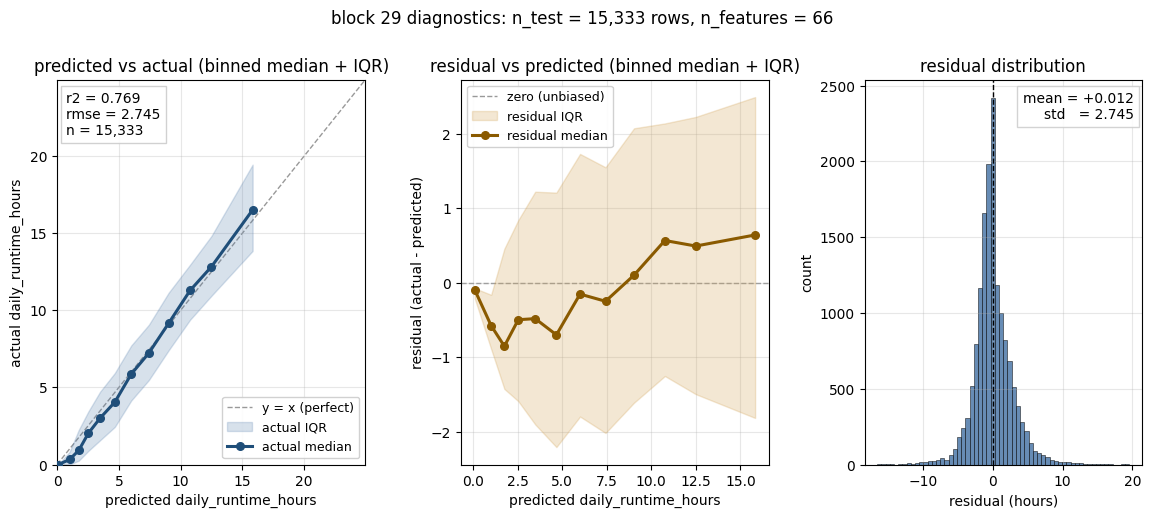

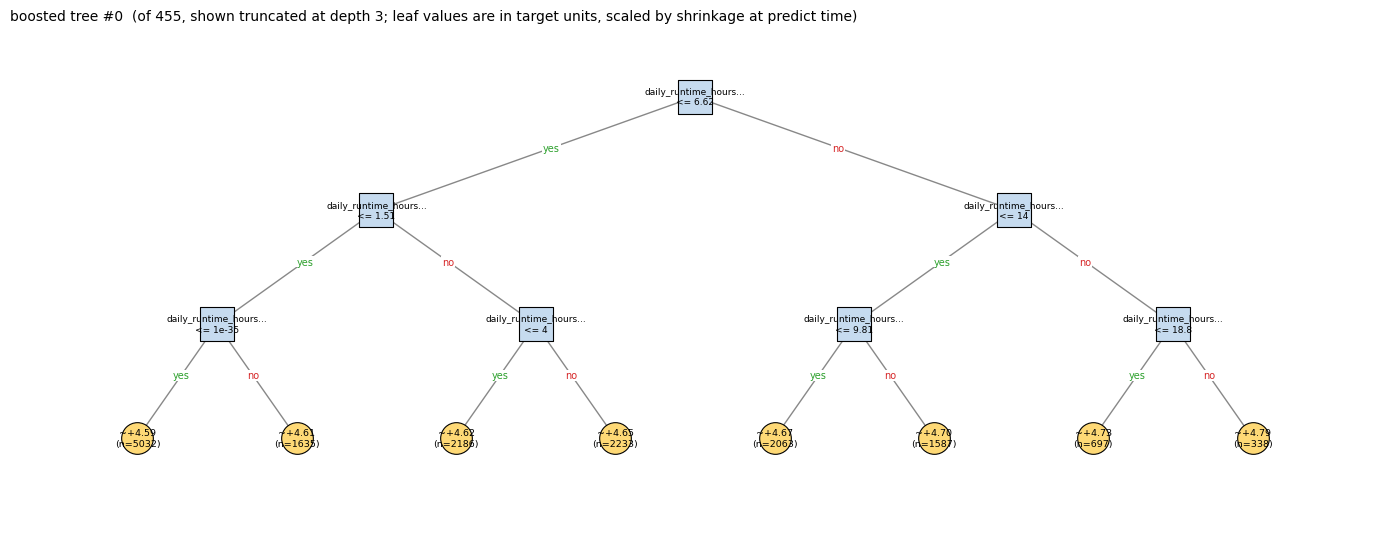

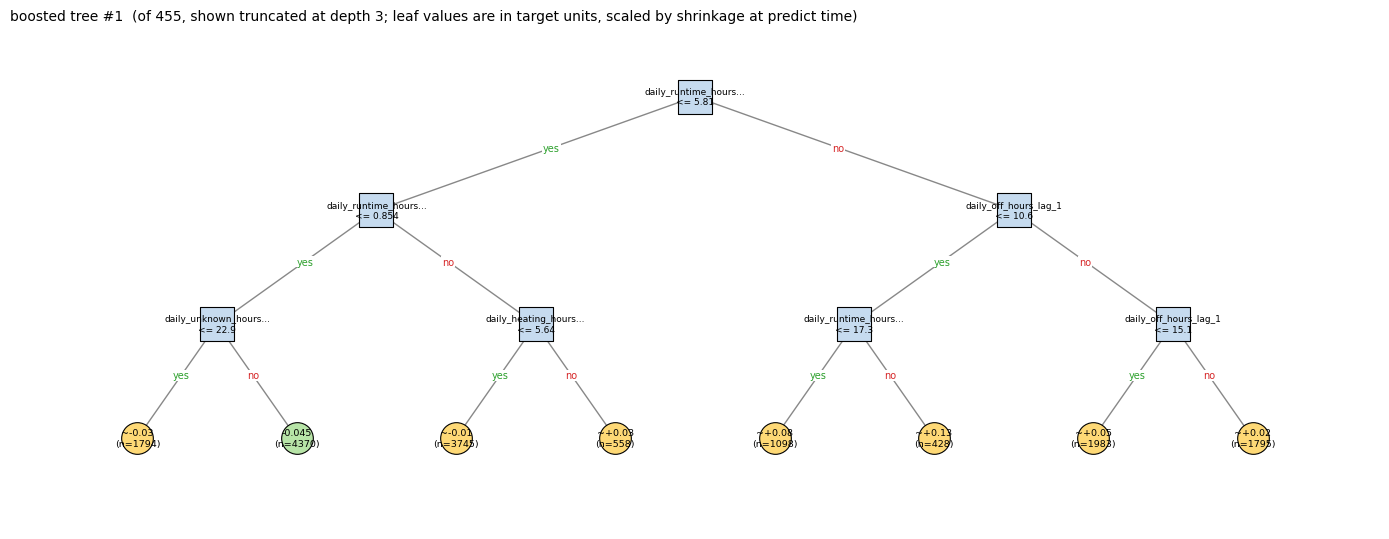

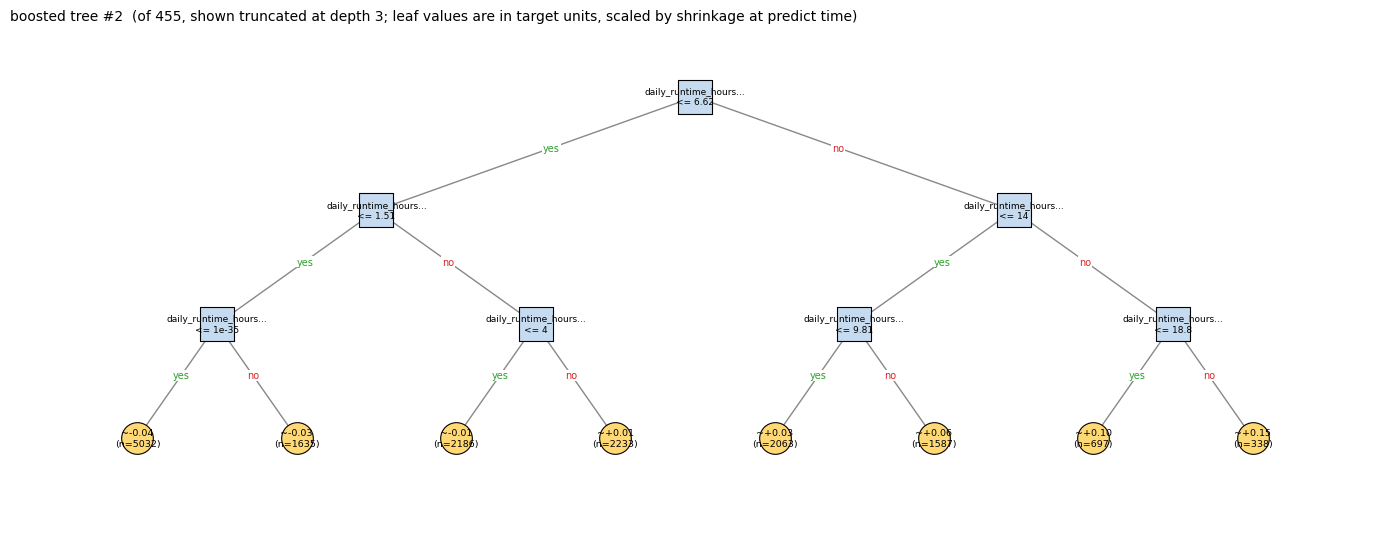

In [29]:
"""
==========================================================================
BLOCK 29: EXTRA EVALUATIONS ON BEST LAG WINDOW MODEL
==========================================================================
Evaluates the best-adj-r2 lag window model from Block 28 along axes
not covered by the core metric report:
  1. Naive baselines (persistence = yesterday, training-set mean) to
     quantify the lift the model provides over trivial predictors.
  2. Full feature importance ranking by gain (replaces the former
     top-15 view).
  3. Predicted vs actual diagnostics: a joint density view with the
     y=x reference line, and residual-vs-predicted / residual
     histogram panels to surface bias and heteroscedasticity.
  4. Decision-tree visualizations: renders the first three boosted
     trees from the ensemble in a depth-limited layout using a
     pure-matplotlib tree drawer so the plots work without a
     graphviz system install.
==========================================================================
"""

# predict on the best model's held-out test rows
#
best_preds = best_model.predict(best_test_X)
y_true = best_test_y.values

# ---------------------------------------------------------------------------
#
# 1. naive baselines
#
# ---------------------------------------------------------------------------

# persistence: predict yesterday's runtime within each equipment
# group.  shifting inside ext_df gives a series aligned to
# ext_df's index, which is the same index family as best_test_y,
# so .loc pulls back the correct rows.
#
persistence_full = ext_df.groupby("Equipment_ID")["daily_runtime_hours"].shift(1)
y_persistence = persistence_full.loc[best_test_y.index].values

# persistence is nan at the start of each equipment's series, so
# score persistence AND the model on the intersected subset where
# yesterday's value is available.  reporting the two metrics on
# identical rows lets the reader treat them as a fair comparison;
# a coverage-only model score on the same mask is printed
# alongside so any gap between "matched" and "all-test" model
# performance is transparent.
#
pers_mask = ~np.isnan(y_persistence)
y_true_pm = y_true[pers_mask]
y_pers_pm = y_persistence[pers_mask]
model_pm = best_preds[pers_mask]

pers_rmse = root_mean_squared_error(y_true_pm, y_pers_pm)
pers_mae = mean_absolute_error(y_true_pm, y_pers_pm)
pers_r2 = r2_score(y_true_pm, y_pers_pm)

model_on_pm_rmse = root_mean_squared_error(y_true_pm, model_pm)
model_on_pm_mae = mean_absolute_error(y_true_pm, model_pm)
model_on_pm_r2 = r2_score(y_true_pm, model_pm)

# training-set mean baseline, scored on the FULL test set so it
# matches the top-line model report produced by block 28
#
y_train_mean = ext_train["daily_runtime_hours"].mean()
mean_preds = np.full_like(y_true, y_train_mean, dtype=float)
mean_rmse = root_mean_squared_error(y_true, mean_preds)
mean_mae = mean_absolute_error(y_true, mean_preds)

# report naive baselines
#
print("naive baselines on the block 28 test slice:")
print(
    f"  persistence (yesterday):    rmse={pers_rmse:.4f}  "
    f"mae={pers_mae:.4f}  r2={pers_r2:.4f}  "
    f"(n={pers_mask.sum():,}, coverage={pers_mask.mean() * 100:.1f}%)"
)
print(
    f"  model on persistence mask:  rmse={model_on_pm_rmse:.4f}  "
    f"mae={model_on_pm_mae:.4f}  r2={model_on_pm_r2:.4f}  "
    f"(same n for direct comparison vs persistence)"
)
print(
    f"  training-set mean:          rmse={mean_rmse:.4f}  "
    f"mae={mean_mae:.4f}  (scored on full test set)"
)

# ---------------------------------------------------------------------------
#
# 2. full feature importance ranking by gain (replaces top-15 view)
#
# ---------------------------------------------------------------------------

print_lgbm_feature_importance(
    best_model, best_features,
    title="BLOCK 29: extra-eval target (best lag window model)",
)

# ---------------------------------------------------------------------------
#
# 3. predicted vs actual and residual diagnostics
#
# ---------------------------------------------------------------------------

# (a) predicted vs actual summarized by equal-count bins of
#     predicted: median + IQR of actual within each bin.  the
#     y=x line is the perfect-calibration reference.
# (b) residual vs predicted, same binning scheme: zero-line
#     sits across the panel and the median + IQR band shows
#     how bias and spread change with predicted runtime.
# (c) residual histogram with a zero-reference line, for the
#     shape of the error distribution.
#
residual = y_true - best_preds
abs_max = float(np.nanmax(np.abs(np.concatenate([y_true, best_preds]))))
ax_lim = (0.0, 1.04 * abs_max) if abs_max > 0 else (0.0, 1.0)

def _binned_summary(xv, yv, n_bins=12, min_n=25):
    """
    function: _binned_summary

    arguments:
      xv: 1-d array of x values (predicted)
      yv: 1-d array of y values paired with xv
      n_bins: number of equal-count bins along xv
      min_n: minimum samples per bin to emit a stat

    return:
      (centers, medians, q25, q75, counts) arrays, length n_bins

    description:
      summarizes a noisy scatter by equal-count x-bins.  each bin gets
      the median, 25th, and 75th percentile of yv inside it, which
      gives a clean median curve + IQR shading instead of a hexbin of
      overlapping daily-runtime points.  bins with < min_n samples
      become NaN so sparse tails do not produce spurious wiggles.
    """
    xv = np.asarray(xv, dtype=float)
    yv = np.asarray(yv, dtype=float)
    m = np.isfinite(xv) & np.isfinite(yv)
    xv, yv = xv[m], yv[m]
    if len(xv) == 0:
        return (np.array([]),) * 5
    # equal-count edges on x
    #
    qs = np.linspace(0.0, 1.0, n_bins + 1)
    edges = np.quantile(xv, qs)
    # nudge duplicate edges to avoid zero-width bins
    #
    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = edges[i - 1] + 1e-9
    centers = np.full(n_bins, np.nan)
    medians = np.full(n_bins, np.nan)
    q25 = np.full(n_bins, np.nan)
    q75 = np.full(n_bins, np.nan)
    counts = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        sel = (xv >= lo) & (xv <= hi if i == n_bins - 1 else xv < hi)
        yi = yv[sel]
        counts[i] = len(yi)
        if len(yi) >= min_n:
            centers[i] = float(np.median(xv[sel]))
            medians[i] = float(np.median(yi))
            q25[i] = float(np.percentile(yi, 25))
            q75[i] = float(np.percentile(yi, 75))
    return centers, medians, q25, q75, counts


fig = plt.figure(figsize=(14, 5.0))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.0, 0.9], wspace=0.32)

# (a) predicted vs actual - binned-median curve with IQR band and y=x
#     reference.  the band collapses thousands of noisy points into a
#     readable calibration curve: the closer the median curve sits to
#     y=x and the narrower the IQR band, the better calibrated the
#     model is across the runtime range.
#
ax_pa = fig.add_subplot(gs[0, 0])
x_c, y_m, y_lo, y_hi, y_n = _binned_summary(
    best_preds, y_true, n_bins=12, min_n=25
)
ok = ~np.isnan(y_m)
ax_pa.plot([ax_lim[0], ax_lim[1]], [ax_lim[0], ax_lim[1]],
           color="#999999", linewidth=1.0, linestyle="--",
           label="y = x (perfect)", zorder=1)
if ok.any():
    ax_pa.fill_between(x_c[ok], y_lo[ok], y_hi[ok],
                       color="#4c78a8", alpha=0.22,
                       label="actual IQR", zorder=2)
    ax_pa.plot(x_c[ok], y_m[ok], color="#1f4e79",
               linewidth=2.2, marker="o", markersize=5.5,
               label="actual median", zorder=3)

r2_val = r2_score(y_true, best_preds)
rmse_val = root_mean_squared_error(y_true, best_preds)
ax_pa.text(
    0.03, 0.97,
    f"r2 = {r2_val:.3f}\nrmse = {rmse_val:.3f}\nn = {len(y_true):,}",
    transform=ax_pa.transAxes, va="top", ha="left",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="#ccc"),
)
ax_pa.set_xlim(ax_lim)
ax_pa.set_ylim(ax_lim)
ax_pa.set_xlabel("predicted daily_runtime_hours")
ax_pa.set_ylabel("actual daily_runtime_hours")
ax_pa.set_title("predicted vs actual (binned median + IQR)")
ax_pa.grid(alpha=0.3)
ax_pa.legend(loc="lower right", fontsize=9, framealpha=0.9)

# (b) residual vs predicted - binned-median residual with IQR band
#     and a zero reference line.  bias shows as the median curve
#     drifting off zero, heteroscedasticity shows as the IQR band
#     widening at particular prediction levels.
#
ax_rp = fig.add_subplot(gs[0, 1])
xr_c, r_m, r_lo, r_hi, r_n = _binned_summary(
    best_preds, residual, n_bins=12, min_n=25
)
ok_r = ~np.isnan(r_m)
ax_rp.axhline(0.0, color="#999999", linewidth=1.0, linestyle="--",
              label="zero (unbiased)", zorder=1)
if ok_r.any():
    ax_rp.fill_between(xr_c[ok_r], r_lo[ok_r], r_hi[ok_r],
                       color="#d1a050", alpha=0.25,
                       label="residual IQR", zorder=2)
    ax_rp.plot(xr_c[ok_r], r_m[ok_r], color="#8a5a00",
               linewidth=2.2, marker="o", markersize=5.5,
               label="residual median", zorder=3)
ax_rp.set_xlabel("predicted daily_runtime_hours")
ax_rp.set_ylabel("residual (actual - predicted)")
ax_rp.set_title("residual vs predicted (binned median + IQR)")
ax_rp.grid(alpha=0.3)
ax_rp.legend(loc="best", fontsize=9, framealpha=0.9)

# (c) residual histogram
#
ax_rh = fig.add_subplot(gs[0, 2])
ax_rh.hist(residual, bins=60, color="#4c78a8", edgecolor="black",
           linewidth=0.4, alpha=0.85)
ax_rh.axvline(0.0, color="black", linewidth=1.0, linestyle="--")
mu = float(np.mean(residual))
sd = float(np.std(residual))
ax_rh.text(
    0.97, 0.97,
    f"mean = {mu:+.3f}\nstd   = {sd:.3f}",
    transform=ax_rh.transAxes, va="top", ha="right",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="#ccc"),
)
ax_rh.set_xlabel("residual (hours)")
ax_rh.set_ylabel("count")
ax_rh.set_title("residual distribution")
ax_rh.grid(alpha=0.3)

fig.suptitle(
    f"block 29 diagnostics: n_test = {len(y_true):,} rows, "
    f"n_features = {len(best_features)}",
    y=1.02, fontsize=12,
)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
#
# 4. decision-tree visualizations
#
# ---------------------------------------------------------------------------

# pure-matplotlib tree renderer so this works without requiring a
# graphviz system install (lgb.plot_tree / create_tree_digraph both
# need `dot` on PATH).  the tree is read from booster.dump_model()
# and truncated to max_depth so wide later boosters stay readable.
# tree_index=0 shows the strongest first split, the next two trees
# show how successive boosters refine the residual.
#


def _layout_tree(node, max_depth):
    """
    function: _layout_tree

    arguments:
      node: lightgbm tree_structure dict (root or subtree)
      max_depth: maximum depth to render; deeper subtrees collapse
        into a single pseudo-leaf showing the internal value and
        sample count

    return:
      (truncated_tree, leaves_list) where truncated_tree mirrors
      the input structure but stops at max_depth, and leaves_list
      is the list of leaf dicts in left-to-right visual order

    description:
      walks the tree once to truncate and once to collect leaves
      in in-order traversal, which is the reading order that
      produces a tidy left-to-right layout when x-positions are
      assigned by leaf index.
    """
    def truncate(nd, depth):
        is_leaf = "leaf_index" in nd
        if is_leaf:
            return dict(nd)
        if depth >= max_depth:
            return {
                "leaf_index": -1,
                "leaf_value": nd.get("internal_value", 0.0),
                "leaf_count": nd.get("internal_count", 0),
                "_truncated": True,
            }
        out = {k: nd[k] for k in nd
               if k not in ("left_child", "right_child")}
        out["left_child"] = truncate(nd["left_child"], depth + 1)
        out["right_child"] = truncate(nd["right_child"], depth + 1)
        return out

    truncated = truncate(node, 0)

    leaves = []

    def collect(nd):
        if "leaf_index" in nd:
            leaves.append(nd)
            return
        collect(nd["left_child"])
        collect(nd["right_child"])

    collect(truncated)
    return truncated, leaves


def _render_lgbm_tree(booster, tree_index, feature_names, ax,
                      max_depth=3, title=None):
    """
    function: _render_lgbm_tree

    arguments:
      booster: fitted lightgbm Booster
      tree_index: which tree to render (0-based)
      feature_names: list of feature names matching booster features
      ax: matplotlib axis to draw into
      max_depth: truncation depth (0 = root only)
      title: optional title drawn above the tree

    return:
      None (draws in place)

    description:
      renders a single boosted tree in a left-right layout using only
      matplotlib primitives.  internal nodes show feature + threshold,
      leaves show the leaf_value and sample count, truncated subtrees
      are drawn in a different color with internal_value as the
      fallback displayed value.
    """
    dump = booster.dump_model()
    info = dump["tree_info"][tree_index]
    root = info["tree_structure"]
    truncated, leaves = _layout_tree(root, max_depth)

    # assign x by leaf index, y by depth, internals get child mean
    #
    for i, leaf in enumerate(leaves):
        leaf["_x"] = float(i)

    def assign(nd, depth):
        if "leaf_index" in nd:
            nd["_y"] = -depth
            return nd["_x"]
        lx = assign(nd["left_child"], depth + 1)
        rx = assign(nd["right_child"], depth + 1)
        nd["_x"] = 0.5 * (lx + rx)
        nd["_y"] = -depth
        return nd["_x"]

    assign(truncated, 0)

    # draw edges then nodes, so nodes overlap edges
    #
    def draw_edges(nd):
        if "leaf_index" in nd:
            return
        for child, is_yes in [(nd["left_child"], True),
                              (nd["right_child"], False)]:
            ax.plot(
                [nd["_x"], child["_x"]],
                [nd["_y"], child["_y"]],
                color="#888888", linewidth=1.0, zorder=1,
            )
            mx = 0.55 * nd["_x"] + 0.45 * child["_x"]
            my = 0.55 * nd["_y"] + 0.45 * child["_y"]
            ax.text(
                mx, my, "yes" if is_yes else "no",
                ha="center", va="center",
                fontsize=7,
                color="#2ca02c" if is_yes else "#d62728",
                bbox=dict(facecolor="white",
                          edgecolor="none", pad=0.6),
                zorder=2,
            )
            draw_edges(child)

    draw_edges(truncated)

    def draw_nodes(nd):
        x, y = nd["_x"], nd["_y"]
        if "leaf_index" in nd:
            truncated_leaf = nd.get("_truncated", False)
            val = nd["leaf_value"]
            count = nd.get("leaf_count", 0)
            facecolor = "#fed976" if truncated_leaf else "#b7e4a7"
            ax.scatter([x], [y], s=520, marker="o",
                       color=facecolor, edgecolor="black",
                       linewidths=0.8, zorder=3)
            if truncated_leaf:
                txt = f"~{val:+.2f}\n(n={count})"
            else:
                txt = f"{val:+.3f}\n(n={count})"
            ax.text(x, y, txt, ha="center", va="center",
                    fontsize=6.8, zorder=4)
        else:
            feat_idx = nd["split_feature"]
            feat = (feature_names[feat_idx]
                    if feat_idx < len(feature_names) else f"f{feat_idx}")
            thr = nd["threshold"]
            # shorten long feature names so they fit in the node
            #
            feat_show = feat if len(feat) <= 22 else feat[:19] + "..."
            ax.scatter([x], [y], s=620, marker="s",
                       color="#c6dbef", edgecolor="black",
                       linewidths=0.8, zorder=3)
            ax.text(x, y, f"{feat_show}\n<= {thr:.3g}",
                    ha="center", va="center", fontsize=6.5,
                    zorder=4)
            draw_nodes(nd["left_child"])
            draw_nodes(nd["right_child"])

    draw_nodes(truncated)

    n_leaves = max(len(leaves), 1)
    ax.set_xlim(-0.8, n_leaves - 0.2)
    ax.set_ylim(-max_depth - 0.8, 0.6)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=10, loc="left")


# render the first three trees so we see the initial model geometry.
# tree 0 holds the largest-gain first split, trees 1..2 fit the
# remaining residual after shrinkage.  max_depth=3 trades some
# structure for readability on typical landscape figures.
#
# LGBMRegressor is the sklearn wrapper; the underlying Booster
# (which owns dump_model and num_trees) lives on .booster_.
#
best_booster = best_model.booster_
n_trees_total = best_booster.num_trees()
trees_to_show = [i for i in [0, 1, 2] if i < n_trees_total]

for ti in trees_to_show:
    fig, ax = plt.subplots(figsize=(14, 5.5))
    _render_lgbm_tree(
        best_booster, tree_index=ti,
        feature_names=list(best_features),
        ax=ax, max_depth=3,
        title=(f"boosted tree #{ti}  (of {n_trees_total}, "
               f"shown truncated at depth 3; leaf values are in "
               f"target units, scaled by shrinkage at predict time)"),
    )
    plt.tight_layout()
    plt.show()


In [30]:
"""
==========================================================================
BLOCK 30: PER-HOUSE PERFORMANCE BREAKDOWN OF THE SELECTED LAG MODEL
==========================================================================
Decomposes the Block 28 best-lag-window model's test predictions by
Equipment_ID so the reader can see which houses the global model
serves well and which it struggles on.  Each house is scored on its
own test-slice rows (no pooling), with a minimum-sample floor so
short slices do not produce spurious rankings.  Prints the top and
bottom TOP_N_HOUSES by RMSE and the overall distribution of per-house
metrics; the per-house metric frame is handed to Block 31 for cohort
characterization.
==========================================================================
"""

# minimum test rows a house must have to be scored individually;
# below this floor the house is omitted from the ranking rather than
# producing a noisy metric on 2-3 days of residuals
#
MIN_HOUSE_TEST_ROWS = 10

# number of best and worst houses to print in each direction
#
TOP_N_HOUSES = 10


def _per_house_metrics(eval_df, min_rows=MIN_HOUSE_TEST_ROWS):
    """
    function: _per_house_metrics

    arguments:
      eval_df: dataframe with Equipment_ID, y_true, y_pred columns
      min_rows: minimum test rows a house must have to be scored

    return:
      dataframe indexed by Equipment_ID (string) with columns
      (n_test, rmse, mae, r2, bias_mean, residual_std,
       y_true_mean, y_pred_mean), sorted by rmse ascending.

    description:
      scores every equipment id on its own test slice so downstream
      cohort analysis can see where the global model does and does
      not earn its pooled adj_r2.  r2 is guarded against a constant
      target slice (std ~ 0) to keep the ranking numerically stable
      for low-variability houses.
    """

    # accumulate one record per qualifying house
    #
    rows = []
    for eq_id, g in eval_df.groupby("Equipment_ID", observed=True):

        # skip houses with too few test rows
        #
        n = len(g)
        if n < min_rows:
            continue

        # extract aligned true / predicted arrays and residuals
        #
        yt = g["y_true"].values.astype(float)
        yp = g["y_pred"].values.astype(float)
        resid = yt - yp

        # core metrics; r2 is NaN for constant-target slices
        #
        rmse = root_mean_squared_error(yt, yp)
        mae = mean_absolute_error(yt, yp)
        r2 = r2_score(yt, yp) if float(np.nanstd(yt)) > 1e-12 else np.nan

        rows.append({
            "Equipment_ID": str(eq_id),
            "n_test": int(n),
            "rmse": float(rmse),
            "mae": float(mae),
            "r2": float(r2) if np.isfinite(r2) else np.nan,
            "bias_mean": float(resid.mean()),
            "residual_std": float(resid.std(ddof=0)),
            "y_true_mean": float(yt.mean()),
            "y_pred_mean": float(yp.mean()),
        })

    # assemble and sort best-first by rmse
    #
    out = pd.DataFrame(rows).set_index("Equipment_ID")
    return out.sort_values("rmse")


# compute per-house metrics on the block 28 selected model's test slice
#
per_house_perf = _per_house_metrics(eval_sweep)

# report the best and worst performing houses by rmse
#
print(
    f"\nper-house performance on block 28 selected model "
    f"(k=1..{best_k}, n_houses scored={len(per_house_perf)}):"
)
print(f"\ntop {TOP_N_HOUSES} houses by RMSE (best):")
print(per_house_perf.head(TOP_N_HOUSES).round(4).to_string())
print(f"\nbottom {TOP_N_HOUSES} houses by RMSE (worst):")
print(per_house_perf.tail(TOP_N_HOUSES).round(4).to_string())

# report the overall distribution of per-house metrics so the reader
# can see the spread the top / bottom slices are drawn from
#
print("\nper-house metric distribution (across scored houses):")
summary = per_house_perf[["rmse", "mae", "r2", "bias_mean"]].describe(
    percentiles=[0.25, 0.5, 0.75],
)
print(summary.round(4).to_string())



per-house performance on block 28 selected model (k=1..3, n_houses scored=100):

top 10 houses by RMSE (best):
                                        n_test    rmse     mae      r2  bias_mean  residual_std  y_true_mean  y_pred_mean
Equipment_ID                                                                                                             
timeseries_table_timeseries_table (96)     157  1.6851  1.3463  0.8457    -0.2358        1.6685       5.8680       6.1038
timeseries_table_timeseries_table (84)     157  1.7111  1.2781  0.8372    -0.0064        1.7111       6.3484       6.3548
timeseries_table_timeseries_table (52)     157  1.7166  1.3488  0.7132    -0.3432        1.6819       4.7500       5.0932
timeseries_table_timeseries_table (61)     157  1.7214  1.3158  0.8643     0.0396        1.7209       6.9277       6.8881
timeseries_table_timeseries_table (64)     157  1.7382  1.3625  0.7120    -0.3015        1.7119       5.0334       5.3349
timeseries_table_timeseries_table 


worst-quartile threshold (rmse >= 3.0703): 25 houses; rest: 75 houses

characteristic means (worst quartile vs rest):
                     worst_q4_mean  rest_mean   delta  rel_delta_%
daily_runtime_hours         6.7846     4.8266  1.9580      40.5660
true_outside_mean          16.3409    16.3982 -0.0574      -0.3498
true_humidity_mean         71.0282    70.9460  0.0822       0.1159
indoor_temp_mean           21.4549    21.6490 -0.1941      -0.8966
fan_runtime_ratio              NaN        NaN     NaN          NaN
runtime_std                 5.9659     4.5381  1.4277      31.4611


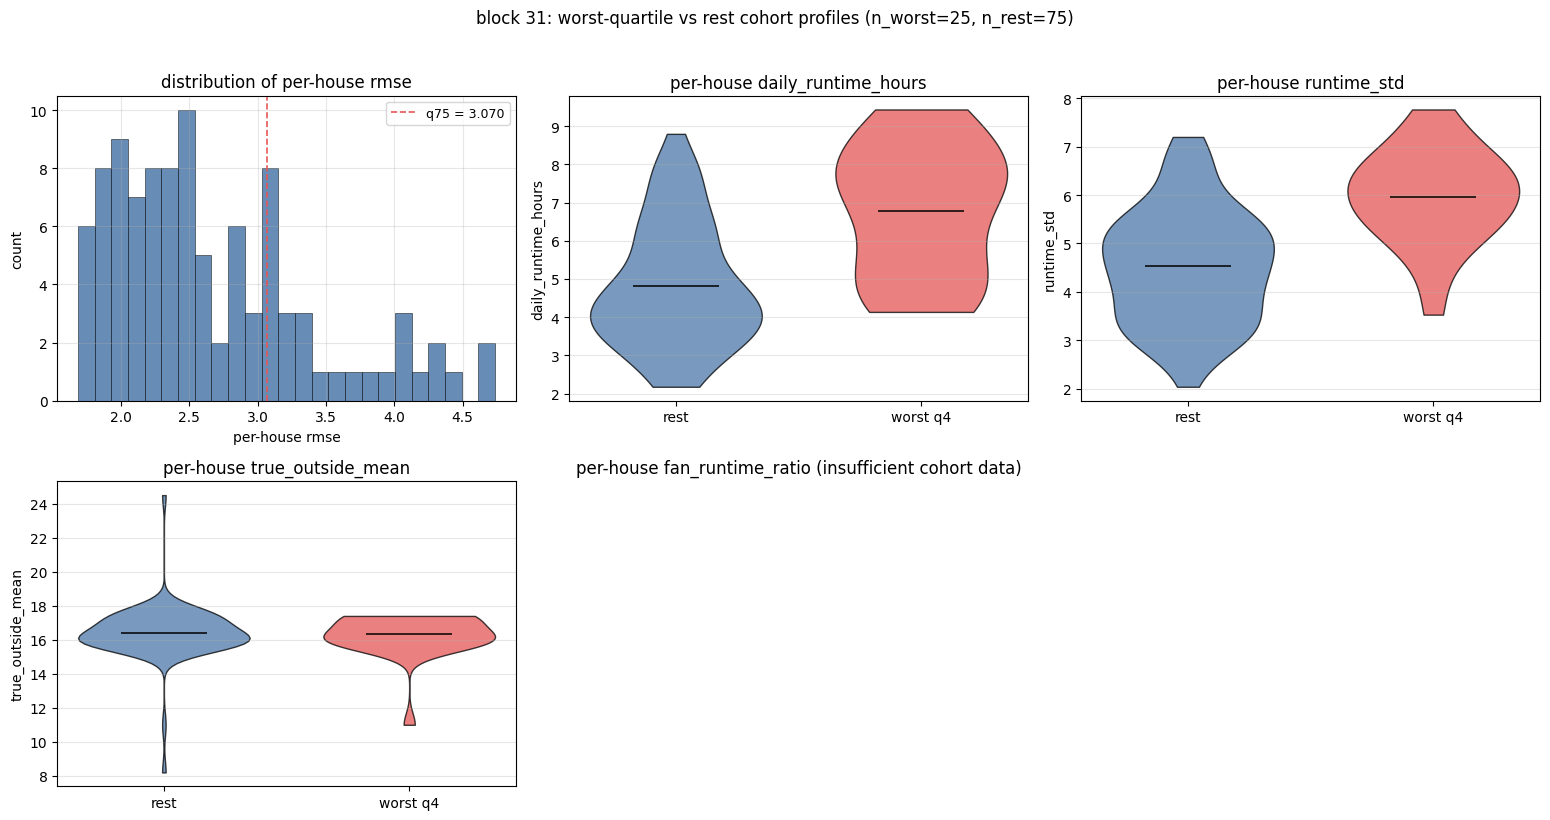

In [31]:
"""
==========================================================================
BLOCK 31: CHARACTERISTICS OF POORLY-PERFORMING HOUSES
==========================================================================
Splits the scored Equipment_IDs from Block 30 into a WORST-QUARTILE
cohort (rmse >= q75) and a REST cohort (everyone else), then compares
their long-run per-house characteristics so we can see what sets the
difficult houses apart.  Characteristics are aggregated over the full
master_processed history (not just the held-out test slice) so they
describe each house's typical behavior rather than the narrow window
on which it was scored.  A four-panel figure pairs the per-house rmse
histogram with violin comparisons on the characteristics most likely
to explain model difficulty.
==========================================================================
"""

# per-day characteristic columns to summarize per house.  columns not
# present in master_processed are skipped silently so this block stays
# portable across pipeline variants
#
HOUSE_CHAR_COLS = [
    "daily_runtime_hours",
    "true_outside_mean",
    "true_humidity_mean",
    "indoor_temp_mean",
    "cooling_comfort_gap_mean",
    "heating_comfort_gap_mean",
    "fan_runtime_ratio",
]


def _per_house_profile(master, char_cols):
    """
    function: _per_house_profile

    arguments:
      master: master_processed-shaped frame with Equipment_ID column
      char_cols: list of per-day columns to summarize per house

    return:
      dataframe indexed by Equipment_ID (string) with one column per
      present char_col (mean over available days), plus runtime_std
      for runtime variability, n_days for coverage, and cluster for
      the block 18 assignment if available.

    description:
      builds a stable per-house summary using only the columns that
      actually appear in the frame, so downstream code never fails
      on an older pipeline run that predates a particular column.
    """

    # keep only characteristics that exist in this run
    #
    present = [c for c in char_cols if c in master.columns]

    # mean over each present characteristic, plus a row count
    #
    agg_spec = {c: "mean" for c in present}
    agg_spec["Date"] = "count"
    prof = master.groupby("Equipment_ID", observed=True).agg(agg_spec)
    prof = prof.rename(columns={"Date": "n_days"})

    # add runtime variability explicitly: mean runtime alone cannot
    # tell a stable-high-runtime house from a highly-bimodal one
    #
    if "daily_runtime_hours" in master.columns:
        prof["runtime_std"] = master.groupby(
            "Equipment_ID", observed=True,
        )["daily_runtime_hours"].std()

    # attach the block 18 dtw cluster if present.  cluster is stored
    # per-day but is identical within each house, so first() recovers
    # the correct label
    #
    if "cluster" in master.columns:
        prof["cluster"] = master.groupby(
            "Equipment_ID", observed=True,
        )["cluster"].first()

    prof.index = prof.index.astype(str)
    return prof


# build the per-house characteristic profile from master_processed
#
house_profile = _per_house_profile(master_processed, HOUSE_CHAR_COLS)

# ---------------------------------------------------------------------------
#
# cohort split: worst quartile vs rest, by block 30 rmse
#
# ---------------------------------------------------------------------------

# q75 on per-house rmse is the cutoff.  >= q75 is the worst quartile
#
rmse_q75 = float(per_house_perf["rmse"].quantile(0.75))
worst_ids = per_house_perf[per_house_perf["rmse"] >= rmse_q75].index.tolist()
rest_ids = per_house_perf[per_house_perf["rmse"] < rmse_q75].index.tolist()
print(
    f"\nworst-quartile threshold (rmse >= {rmse_q75:.4f}): "
    f"{len(worst_ids)} houses; rest: {len(rest_ids)} houses"
)

# ---------------------------------------------------------------------------
#
# cohort comparison table on available characteristics
#
# ---------------------------------------------------------------------------

# exclude structural columns (n_days, cluster) from the mean-of-means
# comparison; those get their own reporting below
#
char_cols_present = [c for c in house_profile.columns
                     if c not in {"cluster", "n_days"}]

# aggregate cohort means for each characteristic column that exists
#
worst_means = house_profile.loc[
    house_profile.index.intersection(worst_ids), char_cols_present
].mean()
rest_means = house_profile.loc[
    house_profile.index.intersection(rest_ids), char_cols_present
].mean()
cohort_summary = pd.DataFrame({
    "worst_q4_mean": worst_means,
    "rest_mean": rest_means,
})
cohort_summary["delta"] = (
    cohort_summary["worst_q4_mean"] - cohort_summary["rest_mean"]
)

# guard against zero denominators so a characteristic that averages
# to exactly 0 in the rest cohort does not produce an inf ratio
#
denom = cohort_summary["rest_mean"].replace(0.0, np.nan)
cohort_summary["rel_delta_%"] = 100.0 * cohort_summary["delta"] / denom

print("\ncharacteristic means (worst quartile vs rest):")
print(cohort_summary.round(4).to_string())

# ---------------------------------------------------------------------------
#
# cluster mix in each cohort (if block 18 ran)
#
# ---------------------------------------------------------------------------

if "cluster" in house_profile.columns:
    worst_clusters = house_profile.loc[
        house_profile.index.intersection(worst_ids), "cluster",
    ].value_counts().sort_index()
    rest_clusters = house_profile.loc[
        house_profile.index.intersection(rest_ids), "cluster",
    ].value_counts().sort_index()
    mix = pd.DataFrame({
        "worst_q4": worst_clusters,
        "rest": rest_clusters,
    }).fillna(0).astype(int)
    mix["worst_q4_%"] = (
        100.0 * mix["worst_q4"] / max(len(worst_ids), 1)
    ).round(1)
    mix["rest_%"] = (
        100.0 * mix["rest"] / max(len(rest_ids), 1)
    ).round(1)
    print("\ncluster membership: worst quartile vs rest:")
    print(mix.to_string())

# ---------------------------------------------------------------------------
#
# diagnostic figure: rmse distribution + violin comparisons
#
# ---------------------------------------------------------------------------

# characteristics to visualise side-by-side; only those that exist
# in the profile get a panel
#
plot_chars = [c for c in
              ["daily_runtime_hours", "runtime_std",
               "true_outside_mean", "fan_runtime_ratio"]
              if c in house_profile.columns]
n_panels = 1 + len(plot_chars)
ncols = min(n_panels, 3)
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(5.2 * ncols, 4.0 * nrows),
)
axes = np.atleast_1d(axes).ravel()

# panel 0: per-house rmse distribution with the q75 cutoff drawn in
#
ax0 = axes[0]
ax0.hist(per_house_perf["rmse"].values, bins=25,
         color="#4c78a8", edgecolor="black",
         linewidth=0.4, alpha=0.85)
ax0.axvline(rmse_q75, color="#e45756", linestyle="--", linewidth=1.2,
            label=f"q75 = {rmse_q75:.3f}")
ax0.set_xlabel("per-house rmse")
ax0.set_ylabel("count")
ax0.set_title("distribution of per-house rmse")
ax0.grid(alpha=0.3)
ax0.legend(loc="best", fontsize=9)

# remaining panels: violin comparison per characteristic
#
cohort_colors = ["#4c78a8", "#e45756"]  # rest first, worst second
for j, ch in enumerate(plot_chars):
    ax = axes[j + 1]
    rest_vals = house_profile.loc[
        house_profile.index.intersection(rest_ids), ch,
    ].dropna().values
    worst_vals = house_profile.loc[
        house_profile.index.intersection(worst_ids), ch,
    ].dropna().values

    # guard against an empty cohort so violinplot never sees an
    # empty array (it would throw)
    #
    data = [rest_vals, worst_vals]
    if len(rest_vals) == 0 or len(worst_vals) == 0:
        ax.set_title(f"per-house {ch} (insufficient cohort data)")
        ax.axis("off")
        continue

    parts = ax.violinplot(
        data, showmeans=True, showextrema=False, widths=0.7,
    )
    for body, color in zip(parts["bodies"], cohort_colors):
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.75)
    if "cmeans" in parts:
        parts["cmeans"].set_color("black")
        parts["cmeans"].set_linewidth(1.1)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["rest", "worst q4"])
    ax.set_ylabel(ch)
    ax.set_title(f"per-house {ch}")
    ax.grid(alpha=0.3, axis="y")

# hide any trailing empty panels when n_panels does not fill the grid
#
for k in range(n_panels, len(axes)):
    axes[k].axis("off")

fig.suptitle(
    f"block 31: worst-quartile vs rest cohort profiles "
    f"(n_worst={len(worst_ids)}, n_rest={len(rest_ids)})",
    y=1.02, fontsize=12,
)
plt.tight_layout()
plt.show()


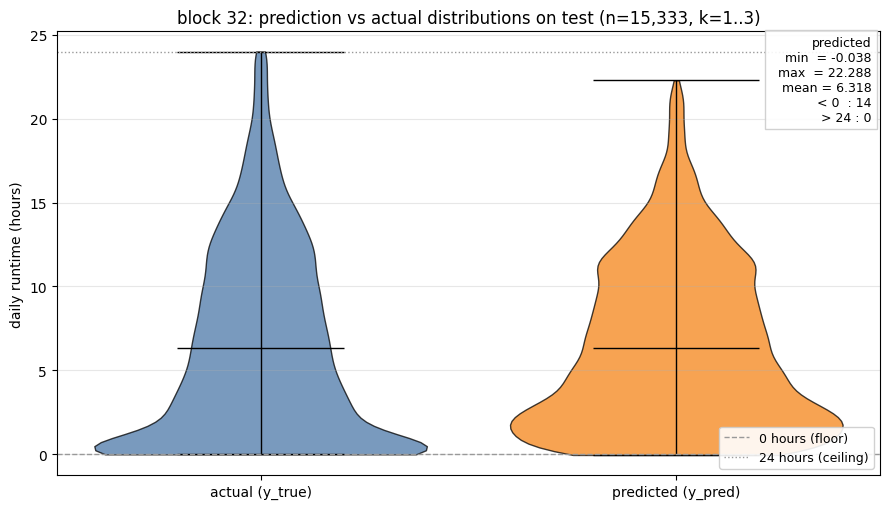


block 32 verdict: min=-0.038, max=22.288, below 0: 14, above 24: 0  [OUT OF RANGE]


In [32]:
"""
==========================================================================
BLOCK 32: PREDICTION DISTRIBUTION SANITY CHECK
==========================================================================
Violin plot of the Block 28 selected model's test-set predictions
alongside actuals, with reference lines at 0 and 24 hours, to confirm
the regressor never steps outside the physical range of daily HVAC
runtime.  Actuals are plotted next to predictions so the prediction
distribution is read against the target distribution it is estimating,
not in isolation.  A plain-text verdict with min / max / out-of-range
counts is printed so any run-all log captures the check.
==========================================================================
"""

# assemble the two distributions we want to view side by side
#
viol_data = [
    best_test_y.values.astype(float),
    best_preds.astype(float),
]
viol_labels = ["actual (y_true)", "predicted (y_pred)"]
viol_colors = ["#4c78a8", "#f58518"]

fig, ax = plt.subplots(figsize=(9, 5.2))

# draw violins with means and extrema so the tails are visible
#
parts = ax.violinplot(
    viol_data, showmeans=True, showextrema=True, widths=0.8,
)
for body, color in zip(parts["bodies"], viol_colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.75)
for key in ("cmeans", "cmaxes", "cmins", "cbars"):
    if key in parts:
        parts[key].set_color("black")
        parts[key].set_linewidth(1.0)

# reference lines at the physical bounds (0h floor and 24h ceiling)
#
ax.axhline(0.0, color="#999999", linestyle="--", linewidth=1.0,
           label="0 hours (floor)")
ax.axhline(24.0, color="#999999", linestyle=":", linewidth=1.0,
           label="24 hours (ceiling)")

# summary stats placed in the upper right so out-of-range predictions
# are obvious without squinting at the tails
#
pred_min = float(np.nanmin(best_preds))
pred_max = float(np.nanmax(best_preds))
pred_mean = float(np.nanmean(best_preds))
n_neg = int((best_preds < 0).sum())
n_over = int((best_preds > 24).sum())

stats_box = (
    "predicted\n"
    f"  min  = {pred_min:.3f}\n"
    f"  max  = {pred_max:.3f}\n"
    f"  mean = {pred_mean:.3f}\n"
    f"  < 0  : {n_neg}\n"
    f"  > 24 : {n_over}"
)
ax.text(
    0.99, 0.99, stats_box, transform=ax.transAxes, va="top", ha="right",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="#ccc"),
)

ax.set_xticks([1, 2])
ax.set_xticklabels(viol_labels)
ax.set_ylabel("daily runtime (hours)")
ax.set_title(
    f"block 32: prediction vs actual distributions on test "
    f"(n={len(best_preds):,}, k=1..{best_k})"
)
ax.grid(alpha=0.3, axis="y")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

# print a plain-text verdict so any run-all log captures whether
# the model ever stepped outside the physical range
#
verdict = "[ok]" if (n_neg == 0 and n_over == 0) else "[OUT OF RANGE]"
print(
    f"\nblock 32 verdict: "
    f"min={pred_min:.3f}, max={pred_max:.3f}, "
    f"below 0: {n_neg}, above 24: {n_over}  {verdict}"
)

In [33]:
"""
==========================================================================
BLOCK 33: NAIVE PERSISTENCE BASELINE BATTERY ON TEST SPLIT
==========================================================================
Per-house persistence baseline (predict today's runtime as yesterday's
runtime) scored on the block 23 test slice, reporting the full metric
battery from the earlier per-house persistence study: MSE, RMSE, MAE,
MedAE, MaxAE, MAPE, SMAPE, R^2, and explained variance.

Methodology per house:
  1. sort by Date within Equipment_ID
  2. compute day_gap within equipment; day_gap == 1 means the prior
     row is the immediately preceding calendar day.  this replaces
     the earlier "largest contiguous run" trick with a direct
     adjacent-pair filter, so every calendar-contiguous test day
     contributes rather than just one run per house.
  3. intersect with split == "test" so the baseline is scored on the
     same rows the models are evaluated on in blocks 25, 27, 28.
  4. accumulate per-house metrics and keep the raw pairs so we can
     also report a pooled global metric.

Serves as a direct like-for-like floor for the block 28 lag-sweep
model: if the model cannot beat this baseline on a given metric, the
tree ensemble is not learning anything useful beyond persistence for
that house.
==========================================================================
"""

from sklearn.metrics import (
    mean_squared_error,
    median_absolute_error,
    max_error,
    explained_variance_score,
)

# minimum calendar-contiguous test pairs a house must have to
# contribute a per-house metric tuple.  5 is the same floor used
# by report_model_metrics so the two tables are directly comparable
#
MIN_PERSIST_ROWS = 5


def _mape(y_true, y_pred, eps=1e-6):
    """
    function: _mape

    arguments:
      y_true: 1-d array of true values
      y_pred: 1-d array of predicted values
      eps: floor on |y_true| to avoid division by zero

    return:
      float MAPE in percent

    description:
      mean absolute percentage error.  zero-target rows are floored
      via eps in the denominator rather than dropped, which matches
      the behavior of the earlier per-house persistence study.
    """
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(yt) < eps, eps, np.abs(yt))
    return 100.0 * float(np.mean(np.abs(yt - yp) / denom))


def _smape(y_true, y_pred, eps=1e-6):
    """
    function: _smape

    arguments:
      y_true: 1-d array of true values
      y_pred: 1-d array of predicted values
      eps: floor on |y_true| + |y_pred| to avoid division by zero

    return:
      float SMAPE in percent (bounded in [0, 200])

    description:
      symmetric mean absolute percentage error.  both-zero rows are
      handled via eps in the denominator so the metric stays defined
      on sparse-runtime slices.
    """
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    denom = np.abs(yt) + np.abs(yp)
    denom = np.where(denom < eps, eps, denom)
    return 100.0 * float(np.mean(2.0 * np.abs(yt - yp) / denom))


def _metric_battery(y_true, y_pred):
    """
    function: _metric_battery

    arguments:
      y_true: 1-d array of true values
      y_pred: 1-d array of predicted values

    return:
      dict with keys n, mse, rmse, mae, medae, maxae, mape, smape,
      r2, evs.  metrics that are undefined on the input (n < 2 or
      constant target) come back as NaN.

    description:
      single-call evaluation of every metric used in the earlier
      per-house persistence study, with numerical guards so a tiny
      or constant slice cannot silently poison pooled means.  r2
      and explained variance are set to NaN when the target has
      zero variance because both metrics are undefined there.
    """
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    n = int(len(yt))

    # guard against slices too small to produce stable metrics
    #
    if n < 2:
        return {
            "n": n, "mse": np.nan, "rmse": np.nan, "mae": np.nan,
            "medae": np.nan, "maxae": np.nan, "mape": np.nan,
            "smape": np.nan, "r2": np.nan, "evs": np.nan,
        }

    # scale and error-magnitude metrics
    #
    mse = float(mean_squared_error(yt, yp))
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(yt, yp))
    medae = float(median_absolute_error(yt, yp))
    maxae = float(max_error(yt, yp))

    # percent-error metrics with guarded denominators
    #
    mape_val = _mape(yt, yp)
    smape_val = _smape(yt, yp)

    # variance-explained metrics, NaN on a constant-target slice
    #
    if float(np.nanstd(yt)) < 1e-12:
        r2 = np.nan
        evs = np.nan
    else:
        r2 = float(r2_score(yt, yp))
        evs = float(explained_variance_score(yt, yp))

    return {
        "n": n, "mse": mse, "rmse": rmse, "mae": mae,
        "medae": medae, "maxae": maxae,
        "mape": mape_val, "smape": smape_val,
        "r2": r2, "evs": evs,
    }


# ---------------------------------------------------------------------------
#
# build the persistence pairs on the test slice
#
# ---------------------------------------------------------------------------

# sort by equipment and date so shift(1) produces the immediately
# prior row's runtime within each house
#
persist_src = master_local_lags.sort_values(
    ["Equipment_ID", "Date"],
).reset_index(drop=True).copy()

# calendar gap within equipment: 1 means yesterday is truly
# yesterday on the calendar, > 1 means there was a reporting gap.
# pairing persistence with a non-contiguous prior day would turn
# the baseline into "predict whatever we saw last, whenever", which
# is not the semantics the earlier study was reporting on.
#
persist_src["_day_gap"] = (
    persist_src.groupby("Equipment_ID", observed=True)["Date"]
    .diff().dt.days
)

# persistence prediction: yesterday's runtime within the same house
#
persist_src["_y_pred"] = (
    persist_src.groupby("Equipment_ID", observed=True)["daily_runtime_hours"]
    .shift(1)
)

# restrict to test rows where yesterday is both available and
# calendar-contiguous, and where today's target is finite
#
persist_test = persist_src[
    (persist_src["split"] == "test") &
    (persist_src["_day_gap"] == 1) &
    persist_src["daily_runtime_hours"].notna() &
    persist_src["_y_pred"].notna()
].copy()

# ---------------------------------------------------------------------------
#
# per-house metrics + pooled accumulators
#
# ---------------------------------------------------------------------------

per_house_rows = []
flagged_houses = []
pooled_y_true_parts = []
pooled_y_pred_parts = []

for eq_id, g in persist_test.groupby("Equipment_ID", observed=True):

    # skip houses with too few contiguous test pairs so a three-row
    # slice does not produce a misleadingly extreme persistence
    # metric tuple
    #
    if len(g) < MIN_PERSIST_ROWS:
        flagged_houses.append((str(eq_id), int(len(g))))
        continue

    yt = g["daily_runtime_hours"].values
    yp = g["_y_pred"].values

    m = _metric_battery(yt, yp)
    m["Equipment_ID"] = str(eq_id)
    per_house_rows.append(m)

    # keep the raw pairs for a pooled global metric at the end.
    # pooling first, then computing metrics, gives the dataset-wide
    # persistence floor that block 28 is competing against
    #
    pooled_y_true_parts.append(yt)
    pooled_y_pred_parts.append(yp)

# ---------------------------------------------------------------------------
#
# per-house ranking and distribution
#
# ---------------------------------------------------------------------------

ordered_cols = ["n", "mse", "rmse", "mae", "medae", "maxae",
                "mape", "smape", "r2", "evs"]

if per_house_rows:
    per_house_persist = pd.DataFrame(per_house_rows).set_index("Equipment_ID")
    per_house_persist = per_house_persist[ordered_cols].sort_values("rmse")
else:
    per_house_persist = pd.DataFrame(columns=ordered_cols)

print(
    f"\nnaive persistence baseline on block 23 test slice "
    f"(calendar-contiguous, n_houses scored={len(per_house_persist)}):"
)
if flagged_houses:
    print(
        f"flagged ({len(flagged_houses)} houses with "
        f"< {MIN_PERSIST_ROWS} contiguous test rows):"
    )
    for hid, n in flagged_houses[:10]:
        print(f"  {hid}: n={n}")
    if len(flagged_houses) > 10:
        print(f"  ... (+{len(flagged_houses) - 10} more)")

if not per_house_persist.empty:
    print("\ntop 10 houses by persistence RMSE (best):")
    print(per_house_persist.head(10).round(4).to_string())
    print("\nbottom 10 houses by persistence RMSE (worst):")
    print(per_house_persist.tail(10).round(4).to_string())

    # per-house distribution of every metric except n
    #
    print("\nper-house metric distribution (across scored houses):")
    metric_cols = [c for c in per_house_persist.columns if c != "n"]
    print(per_house_persist[metric_cols].describe(
        percentiles=[0.25, 0.5, 0.75],
    ).round(4).to_string())

# ---------------------------------------------------------------------------
#
# pooled global persistence metric for a direct comparison against
# the block 28 selected model's pooled test metrics
#
# ---------------------------------------------------------------------------

if pooled_y_true_parts:
    pooled_yt = np.concatenate(pooled_y_true_parts)
    pooled_yp = np.concatenate(pooled_y_pred_parts)
    pooled = _metric_battery(pooled_yt, pooled_yp)
    print("\npooled naive persistence baseline on test slice:")
    for k in ordered_cols:
        v = pooled[k]
        if k == "n":
            print(f"  {k:5s} = {int(v):,}")
        else:
            print(f"  {k:5s} = {v:.4f}")
else:
    print("\npooled naive persistence baseline: no contiguous test pairs")



naive persistence baseline on block 23 test slice (calendar-contiguous, n_houses scored=100):

top 10 houses by persistence RMSE (best):
                                          n     mse    rmse     mae   medae    maxae          mape    smape      r2     evs
Equipment_ID                                                                                                               
timeseries_table_timeseries_table (24)  157  3.1798  1.7832  1.1740  0.7072   6.7731  1.191518e+07  72.0088  0.5905  0.5906
timeseries_table_timeseries_table (84)  157  3.2326  1.7980  1.3232  0.9800   6.4786  5.658531e+05  32.8733  0.8202  0.8204
timeseries_table_timeseries_table (3)   157  3.5056  1.8723  1.1286  0.6444   8.8872  6.190578e+06  29.3648  0.8595  0.8595
timeseries_table_timeseries_table (96)  157  3.6356  1.9067  1.3910  0.9567   6.4444  7.661921e+06  41.0421  0.8025  0.8025
timeseries_table_timeseries_table (8)   157  3.7953  1.9481  1.4987  1.2767   5.3475  6.511062e+06  76.2789  0.1483  0